# 1. 表題および提出情報

`CELL-ID: SUBMISSION-INFO-01`

**Toward Evaluating Problem Scale in Quantum Computing: Focusing on Operational Constraints in Transportation**  
著者：82535190 Takuma Sano  
提出物の種別：第三者審査向け再現可能性・解釈可能性監査Notebook  
参照した正しいスライド資料：`0712_MDR2_v2_enriched_appendix.pptx`。

# Research Premises and Disclosure Statement

`CELL-ID: PREMISES-DISCLOSURE-01`

## 1. 研究の性質

本Notebookは、量子技術評価の前段階として、輸送アプリケーションで表現すべき運用制約を構造化する**探索的・予備的分析**である。量子アルゴリズムの性能実験、EVRP最適化実験、実物流の検証実験ではない。本Notebookでは、量子回路、量子シミュレータ、量子実機、古典EVRPソルバーを実行していない。実行するのは、凍結済み公開データ由来入力からの合成顧客生成、空間クラスタリング、ルートプロキシ構築、制約別の記述的評価、BootstrapおよびOAT感度分析である。

## 2. 推定対象

- **observational unit:** 生成された合成顧客、または制約評価に用いるroute-condition行。実観測ではない。
- **analytical unit:** 指定された顧客集合、車両数、充電条件、seedから構成されるルートプロキシ。
- **aggregation unit:** 主結果は評価可能なルート。補助的にscenario-conditionおよびseed単位でも集計する。
- **numerator:** 対象制約について`unmet=True`となった評価可能ルート数。
- **denominator:** 対象制約について必要列が存在し、`evaluated=True`となったルート数。SOCは分母0である。
- **weighting rule:** 主結果はroute-weightedであり、各評価可能ルートへ等しい重みを与える。scenario-weightedとseed-weightedは別の推定量として併記する。
- **conditioning assumptions:** 凍結入力、人口加重生成、需要・サービス時間分布、デポ選択、KMeans、最近傍訪問順、道路距離係数、車両仕様、充電条件、一定速度などを固定する。
- **intended interpretation:** 現行の合成モデルとルートプロキシの下で、各運用制約が明示的なモデル表現を必要とする可能性を示す分析信号。
- **prohibited interpretation:** 実際の配送失敗率、最適EVRP解の実行不能率、企業・事業所の運用品質、EV運用可能性全体、または量子計算の優位性として解釈してはならない。

各制約は個別に評価される。したがって、個別制約の未充足率は、全制約を同時に課した場合の共同実行不能率ではない。各率の事象は重複し得るため、複数の未充足率を加算してはならない。

## 3. 合成データの位置づけ

合成顧客は実在する顧客、配送記録、企業、事業所、個人を表さない。標本母集団は、凍結済みe-Stat人口メッシュのうち、人口が正で実装上の本土座標範囲を満たすメッシュである。メッシュ人口 $P_m$ に対し、抽出確率を $p_m=P_m/\sum_jP_j$ とする。各`(customer_count, seed)`内では非復元抽出を用いるため、同一シナリオ内で同じメッシュは重複しない。乱数生成器は`numpy.random.default_rng(seed × 100000 + customer_count)`である。需要は5–30 kg、サービス時間は5–15分の離散一様分布から生成する。

空間表現は選択メッシュの近似重心であり、建物、道路、配送先住所、土地利用を保存しない。人口分布に基づく空間的重みは保存するが、実注文頻度、企業分布、貨物品目、需要相関、時間帯、顧客間依存、配送頻度は保存しない。非復元抽出は、同一メッシュに複数顧客を置かないため、高人口密度メッシュに複数注文が集中する現象を過小表現する可能性がある。

## 4. 対応のあるシナリオ設計

同一の`(customer_count, seed)`で生成された顧客集合を、異なる車両数および充電条件の間で共有する。目的は、条件比較時に顧客配置差を統制することである。このため条件間の観測は独立ではなく、対応のある設計である。同じseed番号は、同一生成規則に用いる識別子であり、実観測単位、実在する配送日、または同一の実世界状況を意味しない。Bootstrapではseedをクラスタ単位として再標本化し、条件間の対応を維持する。

## 5. プロキシの意味

| 要素 | 代理するもの | 代理しないもの |
|---|---|---|
| population mesh | 合成顧客位置の人口ベース空間重み | 注文数、企業数、貨物需要 |
| synthetic customer | 合成された配送地点・需要・サービス時間 | 実在顧客、個人、実注文 |
| depot proxy | 公開物流施設候補の地理的位置 | 実事業者のデポ、能力、所有関係 |
| route proxy | 顧客割当と訪問順を比較する幾何学的構造 | 実道路経路、最短路、最適EVRP解 |
| road-distance multiplier | 直線距離と道路移動距離の差を表す固定倍率 | 実道路網、渋滞、迂回、一方通行 |
| charger candidate | OCM connectionレコードに基づく地理的候補 | 利用可能な充電施設、空き設備 |
| charger condition | 属性・距離閾値による分析用候補選別規則 | 実際の充電サービス水準 |
| baseline vehicle | 1つの公開仕様行に基づく車両シナリオ | 実運用フリート全体、劣化・季節性能 |
| usable driving range | 静的な距離閾値81.2 km | 逐次SOC、重量・気温・道路勾配の影響 |
| operating-time estimate | 距離、一定速度、合成サービス時間の合計 | 渋滞、休憩、待機、時間窓、充電時間を含む実勤務時間 |

デポは顧客集合の重心に最も近い候補から選ぶため、シナリオ間で固定されない可能性がある。したがって顧客条件間の差には、顧客配置だけでなく選択デポの差も含まれ得る。KMeansは緯度経度上の空間クラスタリングであり、積載量、運行時間、航続距離を満たす最適車両割当ではない。最近傍訪問順はgreedyヒューリスティックであり、最短ルートまたは最適EVRP解ではない。

## 6. 充電データの意味

基礎入力の観測単位は**充電施設数ではなくOpen Charge Mapのcharger-connectionレコード**であり、東京都境界へクリップした137 connection行である。候補IDはOCM POI IDとconnection IDを組み合わせて構成する。同一施設が複数connectionを持つ可能性があるため、137件を137施設と解釈してはならない。

本分析はreal-time availability、occupancy、reservation、outage、実車との最終的なconnector compatibility、実効charging power、charging curve、実道路上のdetour route、waiting time、price、営業時間・会員制等のaccess restrictionsを評価しない。条件によって報告connectorラベルと報告powerを選別・簡略計算に使用するが、実際の互換性や供給電力を検証していない。充電候補との地理的近接性は、実際の充電可能性、充電停止の実行可能性、またはSOC実行可能性を保証しない。

## 7. 時間的・地理的整合性

- e-Stat人口メッシュ：2020年国勢調査。ローカル処理スナップショットは2026-07-05時点の研究資産。
- Open Charge Map：取得日2026-07-05。各レコードの更新日は異なり、動的データである。
- P31物流施設候補：対象年度は現在の監査証拠から一意に確認できず`MISSING`。シナリオ用スナップショットは2026-07-11。
- 車両仕様：複数の公開仕様をまとめた2026-07-11スナップショット。各仕様の対象時点・URLは一部`MISSING`。

異なる時点の人口、充電器、物流拠点、車両仕様を組み合わせており、時間的不整合が存在する。「東京都域」はデータごとに同一処理ではない。OCMはN03東京都境界ポリゴンでクリップされたconnection入力を使用する。人口メッシュ生成では、処理済み東京都メッシュに加えて緯度35.45–35.95、経度138.85–140.25の本土範囲フィルタを用いる。P31候補は処理済みmainland Tokyo proxyである。島しょ部はこの本土分析から除外される。分析用緯度経度はWGS84相当のdecimal degreesとして扱うが、各上流原データからのCRS変換過程全体は本Notebookで再実行しない。

## 8. パラメータの状態

| パラメータ | 値 | 分類 | 根拠・状態 |
|---|---:|---|---|
| 平均速度 | 25 km/h | researcher-defined assumption | 観測交通からの較正根拠は`RATIONALE_NOT_VERIFIED` |
| 道路距離係数 | 1.25 | researcher-defined assumption | 実道路比較による根拠は`RATIONALE_NOT_VERIFIED` |
| 使用可能航続距離 | 81.2 km | derived from another parameter | 116 × (0.90−0.20)。逐次SOCではない |
| 積載容量 | 2,000 kg | obtained from public data | 選択車両仕様行。原URL確認は一部`MISSING` |
| 運行時間上限 | 480分 | researcher-defined assumption | 法令・事業データとの対応は`RATIONALE_NOT_VERIFIED` |
| 顧客需要 | 5–30 kg | researcher-defined assumption | 離散一様分布。観測需要ではない |
| サービス時間 | 5–15分 | researcher-defined assumption | 離散一様分布。観測時間ではない |
| 充電条件 | conservative/balanced/broad | researcher-defined assumption | ソースコードに閾値・欠損処理を明示。実サービス区分ではない |
| 感度分析範囲 | low/base/high | researcher-defined assumption | パラメータレジストリ由来。現実的確率は`RATIONALE_NOT_VERIFIED` |
| 地球半径 | 6,371.0088 km | implementation default | Haversine計算用 |
| Bootstrap回数・seed | 1,000・20260711 | researcher-defined / implementation default | 再現可能性のため固定 |

パラメータ分類は、empirically observed、obtained from public data、obtained from literature、derived from another parameter、researcher-defined assumption、implementation defaultを区別する。本分析の主要パラメータにempirically observedな配送事業データはない。

## 9. 統計的解釈

100個のseedは100件の実運用観測ではなく、同一の合成生成モデルから得た100反復である。Bootstrap信頼区間が含むのは、固定済み入力、固定済み生成分布、固定済みモデル、固定済みパラメータの下でのseedクラスタ変動である。データ取得誤差、需要分布の選択、道路距離係数、車両劣化、充電器の可用性、モデル形式、実運用変動は含まない。

route-weighted集計では車両数が多い条件ほど多くのルートを生成するため、集計値への寄与が大きい。Section 19でroute-weighted、scenario-weighted、seed-weightedを区別して併記する。

## 10. 文献証拠のコーディング

- **search date:** `NOT_DOCUMENTED`
- **search source:** ローカル保存PDF、arXiv URL、DOI URL、既存証拠レジストリ
- **search terms:** `NOT_DOCUMENTED`
- **inclusion criteria:** スライドAppendix E/Fおよび既存レジストリに含まれる量子VRP・ベンチマーキング文献。体系的レビューとしての事前基準は`NOT_DOCUMENTED`。
- **exclusion criteria:** `NOT_DOCUMENTED`
- **coding definitions:** 表現、評価、運用検証を区別し、欠損を0へ変換しない。
- **extraction procedure:** ローカルPDF・抽出テキスト・既存レジストリの照合。ページ・式を確認できない値は参照値として保持する。
- **reviewer:** 文献一次抽出者は`NOT_DOCUMENTED`。本Notebookの監査再構成にはOpenAI Codexを使用。
- **verification procedure:** ローカル一次資料との照合および`SOURCE_NOT_VERIFIED`状態の付与。独立した第二査読者は`NOT_DOCUMENTED`。
- **missing-information policy:** `Not reported`（論文に報告なし）、`Not implemented`（実装されていないことを確認）、`Not applicable`（適用対象外）、`Insufficient information`（判定材料不足）を区別する。

論文に記載がないことだけを、当該制約が実装されていない証拠として扱わない。文献由来の回路幅・qubit数は本Notebookの合成シナリオから導出された値ではない。一次資料で位置と意味を追跡できるサーベイ値と、スライドから転記された4件の`SOURCE_NOT_VERIFIED`参照値を分離する。

## 11. 検証結果の意味

再生成データと保存済みCSVの一致は、凍結入力と現在のコードの間の**回帰的一貫性**を示す。一致はempirical validity、operational validity、construct validity、optimality、基礎仮定の正しさ、generalizabilityを証明しない。スライド集計値との一致も、同じ計算経路を再現できたことを示すだけである。

## 12. 研究プロセスの開示

| 項目 | 開示内容 |
|---|---|
| analysis author | 82535190 Takuma Sano |
| code author | リポジトリ原コードの著者情報は`NOT_DOCUMENTED`。監査Notebook改訂コードはOpenAI Codex支援を含む |
| data reviewer | `NOT_DOCUMENTED` |
| literature reviewer | `NOT_DOCUMENTED` |
| generative AI / coding assistant | OpenAI CodexをNotebook生成、コード修正、日本語解説、監査支援に使用 |
| human verification procedure | `NOT_DOCUMENTED`。提出前の人手確認が必要 |
| analysis plan / preregistration | `NOT_DOCUMENTED` / `NOT_PREREGISTERED` |
| planned vs post-hoc | 原スライド分析と提出用監査強化を区別。個別変更の事前・事後区分は`NOT_DOCUMENTED` |
| funding | `NOT_DOCUMENTED` |
| conflicts of interest | `NOT_DOCUMENTED` |
| ethics review | `NOT_DOCUMENTED`。合成データと公開集計・施設データを使用するが、正式な審査要否判断は記録されていない |
| personal-data status | 実在個人を表す顧客データは使用しない。公開施設名等を含む可能性はある |
| submission version | `quantum_transport_reproducibility_audit_revised.ipynb` |
| creation date | 2026-07-13。実行日時はRun ManifestにUTCで記録 |
| Git commit | 実行時にSection 7で取得。未コミット変更の有無も記録 |
| authoritative document | 不整合時に優先する文書は`NOT_DOCUMENTED` |

## 前提一覧

| Premise | Current setting | Evidence | Consequence for interpretation | Status |
|---|---|---|---|---|
| 研究種別 | 運用制約を構造化する探索的予備分析 | 研究目的・実行コード | 最適化性能や量子性能を主張できない | `CONFIRMED` |
| 主要推定対象 | 個別制約のroute-weighted未充足率 | 制約評価・集計コード | 実配送失敗率ではなく、率を加算できない | `CONFIRMED` |
| 顧客データ | 人口加重・非復元抽出による合成顧客 | e-Stat処理入力・生成コード | 実顧客・注文へ直接一般化できない | `CONFIRMED` |
| 対応設計 | 顧客集合を車両・充電条件間で共有 | seed・configuration ID | 条件間観測は独立ではない | `CONFIRMED` |
| デポ | 顧客重心に最も近いP31候補 | 実装コード・候補表 | デポ差がシナリオ差へ混入し得る | `CONFIRMED` |
| ルート | KMeans＋最近傍訪問順 | 実装コード・route edges | 最短路・最適EVRP解ではない | `CONFIRMED` |
| 道路距離 | Haversine×1.25 | パラメータレジストリ | 実道路・交通を表現しない | `ASSUMPTION` |
| 充電データ | 137 connectionレコード | OCM入力スキーマ | 137施設や利用可能充電器を意味しない | `CONFIRMED` |
| SOC | 逐次状態遷移なし | 制約レジストリ | EV運用可能性全体を判定できない | `NOT_EVALUATED` |
| データ時点 | 2020人口と2026取得・スナップショット等を結合 | 来歴表 | 時間的不整合を含む | `CONFIRMED` |
| seed | 合成生成モデルの100反復 | 乱数レジストリ | 100件の実観測ではない | `CONFIRMED` |
| Bootstrap CI | seedクラスタ変動のみ | Bootstrap実装 | モデル・運用不確実性を含まない | `CONFIRMED` |
| 文献回路幅 | 一次資料の構造化サーベイ値とスライド由来4参照値 | 詳細サーベイ表・証拠レジストリ | 本シナリオから導出された値ではなく、Width単独で性能を示さない | `DIRECTLY_REPORTED`と`SOURCE_NOT_VERIFIED`を分離 |
| 回帰検証 | 再生成結果と保存CSVの一致 | 自動検証表 | 経験的・運用的妥当性を証明しない | `CONFIRMED` |
| 人手確認 | 手続きの記録なし | 研究プロセス記録 | 提出前に研究者確認が必要 | `NOT_DOCUMENTED` |
| 倫理・資金・COI | 記録なし | 研究プロセス記録 | 提出先要件に応じ追加開示が必要 | `NOT_DOCUMENTED` |

# Research Reasoning and Action Trail

`CELL-ID: RESEARCH-REASONING-OVERVIEW-01`

## 記述原則

本節は研究者の内面的思考を創作せず、スライド、コード、データ、出力、Notebook構成および限定的なGit履歴から確認できる行動と判断を再構成する。状態は次の意味で使用する。

- `CONTEMPORANEOUS_RECORD`：当時のスライド、コードコメント、研究資産に明示された判断。
- `DIRECTLY_OBSERVABLE`：現在のコード、データ、出力から直接確認できる行動。
- `RETROSPECTIVE_RECONSTRUCTION`：現在の成果物から再構成した論理であり、当時の思考記録ではない。
- `NOT_DOCUMENTED`：理由または判断を確認できない。
- `UNCERTAIN`：複数の説明が可能で一意に特定できない。

## Research Narrative Overview

1. **Initial observation:** スライド2、5–7は、量子技術評価が問題規模、回路幅、解品質等の技術指標だけでは社会実装条件を十分説明しないという問題設定を示す。`CONTEMPORANEOUS_RECORD`
2. **Perceived problem:** 同程度の問題規模でも、定式化、符号化、補助変数、評価形態により量子資源が異なり、運用要件が表現されているかを別に確認する必要がある。`CONTEMPORANEOUS_RECORD`
3. **Research question:** 輸送固有のインスタンス規模と運用要件をどのように定義すれば、量子資源要件を意味のある形で解釈できるか。`CONTEMPORANEOUS_RECORD`
4. **Analytical need:** 問題規模だけでなく、積載、時間、航続距離、充電、SOC等を明示的な評価対象へ変換する必要が生じた。`RETROSPECTIVE_RECONSTRUCTION`
5. **Methodological choice:** 完全なEVRP最適化ではなく、公開データを空間・技術条件に用い、合成顧客と共通ルートプロキシで個別制約を比較した。行動は`DIRECTLY_OBSERVABLE`、当時の選択理由は一部`RETROSPECTIVE_RECONSTRUCTION`。
6. **Implementation:** 人口加重顧客、デポプロキシ、KMeans車両割当、最近傍訪問順、Haversine×1.25、条件別充電候補、制約評価を実装した。`DIRECTLY_OBSERVABLE`
7. **Validation:** seed固定、件数検査、入力ハッシュ、保存済みCSVとの回帰比較、Bootstrap、OAT、スライド値照合を実行した。`DIRECTLY_OBSERVABLE`
8. **Result:** 距離・時間関連制約が現行シナリオで未充足となり、積載は非拘束的、SOCは未評価だった。`DIRECTLY_OBSERVABLE`
9. **Interpretation:** 結果は運用要件を定式化へ含める必要性を検討する分析信号であり、配送失敗率やEVRP最適解の実行可能率ではない。`CONTEMPORANEOUS_RECORD`および`RETROSPECTIVE_RECONSTRUCTION`
10. **Next decision:** スライド16は、運用現実性を高める方向と、アプリケーション要件・量子技術段階を接続する枠組みの方向を次段階の判断として残す。`CONTEMPORANEOUS_RECORD`

## Research Motivation Chain

| Stage | Researcher observation | Concern or gap | Consequence for the study | Evidence | Status |
|---:|---|---|---|---|---|
| 1 | 技術進歩が単線的な性能向上として提示され得る | 技術能力、適用条件、社会的判断条件が分離されない | 評価枠組みを技術指標以外へ拡張 | slides 2, 5 | `CONTEMPORANEOUS_RECORD` |
| 2 | 量子ルーティング研究は規模・幅・評価形態を報告 | 運用制約の表現と検証が比較可能でない | scale・representation・evidence gapを区別 | slides 6–9 | `CONTEMPORANEOUS_RECORD` |
| 3 | 回路幅は定式化と符号化で大きく変わる | qubit数だけでは応用上の意味を判定できない | 回路幅を参照証拠として限定的に扱う | slide 7; evidence registry | `CONTEMPORANEOUS_RECORD` |
| 4 | 輸送では顧客、車両、デポ、制約を列挙できる | 社会実装条件が未定義のまま資源推定できない | 輸送を初期適用領域に選ぶ | slides 3–4 | `CONTEMPORANEOUS_RECORD` |
| 5 | EV配送では距離・充電・SOCが問題となる | 通常VRP規模だけではEV固有要件を表せない | EVRP側の探索分析を設定 | slides 8–12 | `RETROSPECTIVE_RECONSTRUCTION` |
| 6 | 実配送注文は研究資産に存在しない | 観測顧客による比較を実行できない | 人口加重合成顧客を生成 | input inventory; source code | `DIRECTLY_OBSERVABLE` |
| 7 | 完全最適化・道路経路・SOC実装がない | 統合実行可能性を評価できない | 共通ルートプロキシと個別制約率に限定 | source code; slide 10 | `DIRECTLY_OBSERVABLE` |
| 8 | 基準結果が仮定へ依存する | 単一設定だけでは頑健性が不明 | seed BootstrapとOATを実行 | source code; slide 14 | `DIRECTLY_OBSERVABLE`; rationale partly reconstructed |

## 代替方法の位置づけ

以下の「代替方法」は、当時に実際に比較検討した記録がない限り`POTENTIAL_ALTERNATIVE`であり、「研究者が当時棄却した方法」を意味しない。

| Analytical need | Adopted method | Alternative method | Reason not adopted | Consequence | Status |
|---|---|---|---|---|---|
| 顧客配置 | 人口加重合成 | 実配送注文 | 観測注文が研究資産にない。実際の検討記録はない | 外的妥当性が限定 | `POTENTIAL_ALTERNATIVE` |
| 車両割当 | KMeans | 容量・時間・距離制約付き最適化 | 完全EVRP最適化は現行範囲外 | 最適割当ではない | `CONTEMPORANEOUS_RECORD` for scope; alternative `POTENTIAL_ALTERNATIVE` |
| 訪問順 | greedy最近傍 | TSP/VRP最適化 | 採否理由は`RATIONALE_NOT_DOCUMENTED` | 距離はヒューリスティック | `DIRECTLY_OBSERVABLE` |
| 移動距離 | Haversine×1.25 | 道路ネットワーク最短路 | road-network data unavailableと出力に記録 | 実道路距離ではない | `DIRECTLY_OBSERVABLE` |
| デポ | P31最近傍候補 | 実事業者デポ | 実デポデータがない | シナリオ間でデポが変化 | `DIRECTLY_OBSERVABLE` |
| 評価 | 個別制約未充足 | 統合EVRP実行可能性 | SOC・時間窓・充電動態が未実装 | 共同実行不能率を示さない | `DIRECTLY_OBSERVABLE` |
| 不確実性 | seed-cluster Bootstrap | モデル・パラメータ不確実性の統合 | 現行実装範囲外。採否記録なし | CIの範囲が限定 | `POTENTIAL_ALTERNATIVE` |
| 感度 | OAT | factorial/global sensitivity | 採否理由は`RATIONALE_NOT_DOCUMENTED` | 相互作用を評価しない | `DIRECTLY_OBSERVABLE` |

## End-to-End Research Logic Diagram

`CLASSIFICATION: CONCEPTUAL_RECONSTRUCTION`

```text
Observation                  [Slides 2, 5–7 / CLM-S02, CLM-S07]
    ↓
Research concern             [Section 2 / RESEARCH-QUESTION-01]
    ↓
Research question            [Slide 4 / RESEARCH-QUESTION-01]
    ↓
Required evidence            [Sections 8–11 / provenance, parameters, evidence]
    ↓
Methodological choice        [Sections 12–21 / METHOD-* cells]
    ↓
Data construction            [CUSTOMER-GENERATE-01, ROUTE-GENERATE-01]
    ↓
Computation                  [CONSTRAINT-EVALUATE-01, AGGREGATION-CODE-01]
    ↓
Validation                   [RECONCILIATION-CODE-01, VALIDATION-CODE-01]
    ↓
Result                       [Section 26 / constraint_summary.csv]
    ↓
Interpretation               [Sections 27–28]
    ↓
Method revision / next issue [Slide 16 / operational realism vs application-stage framework]
```

## 研究時系列と説明順序の分離

現在のNotebookは第三者が理解しやすい**expository order**へ再構成されている。この順序を、研究者が当初から完全に計画していたresearch chronologyとして扱ってはならない。確認可能な大まかな段階は、Initial framing → Literature and metric review → Problem-scale comparison → Transportation scenario definition → Synthetic data construction → Constraint operationalization → Sensitivity analysis → Reproducibility audit → Current revisionである。正確な日付と各段階の内部順序は、2026-07-13のリポジトリ再構成コミット以外は`NOT_DOCUMENTED`である。


# 2. 研究質問と目的

`CELL-ID: RESEARCH-QUESTION-01`

**研究質問：** 報告された量子資源要件を意味のある形で解釈するために、輸送固有の問題インスタンス規模と運用要件をどのように定義すべきか。

本計算の目的は、量子資源を解釈する前段階として、合成EVRPシナリオにおいてモデル条件付きで未充足となる運用制約を同定することである。本研究はEVRP最適化器の性能評価、実配送の運用評価、または量子優位性の実証を目的としない。

# 2.1 分析枠組みと研究上の貢献

`CELL-ID: RESEARCH-FRAMEWORK-01`

本研究の分析単位は、量子アルゴリズムそのものではなく、量子資源推定に先立って定義されるべき**アプリケーション要件**である。論理構造は、(i) application requirements、(ii) mathematical representation、(iii) quantum formulation and encoding、(iv) quantum-resource requirements、(v) feasible technology stage の順に構成される。顧客数や車両数のみを問題規模とみなすと、時間、航続距離、充電、SOCなどの表現に必要な変数・制約・補助変数を捨象するため、異なる研究間のqubit数を直接比較する根拠が失われる。

本Notebookの学術的貢献は、量子資源量を新たに推定することではなく、公開データと明示的な合成仮定を用いて、どの運用制約が定式化上無視できない可能性を持つかを監査可能な形で示す点にある。したがって、主要な検証対象は、制約別のモデル条件付き未充足率、そのシナリオ依存性、仮定変更への感度、および現行量子VRP文献における表現・検証証拠との対応である。これは探索的な要件同定研究であり、因果効果の推定、配送事業者母集団への統計的一般化、または量子優位性の検定ではない。

# 3. 再現範囲

`CELL-ID: SCOPE-01`

**実行モード：`凍結済み処理入力からの計算再現および監査再構成`**

| 再現対象 | 再現方法 | 使用入力 | 状態 | 完全再現でない理由 | 第三者が確認できる証拠 |
|---|---|---|---|---|---|
| 合成顧客 | 原実装関数を再実行 | 凍結済みe-Stat処理データ | `REPRODUCED` | e-Stat生データ取得を再実行しない | 行単位比較 |
| ルートと制約 | 原実装関数を再実行 | 凍結済み処理入力 | `REPRODUCED` | 道路ネットワーク最適化ではない | 行単位比較 |
| 集計・Bootstrap・OAT | 再生成結果から再計算 | 再生成ルート評価 | `REPRODUCED` | モデルとパラメータを固定 | 動的テスト |
| 公開データ取得 | 来歴を監査 | ローカルスナップショットと取得コード | `DERIVED` | 歴史的リクエストが完全保存されていない | ハッシュと処理コード |
| 回路幅参照値 | 参照値として再描画 | スライドとローカル文献 | `REFERENCE_ONLY` | 厳密な導出を確認できない | 証拠レジストリ |
| SOC実行可能性 | 評価なし | 該当なし | `NOT_EVALUATED` | 逐次SOCモデルが存在しない | 制約レジストリ |

# 4. 解釈上の境界

`CELL-ID: BOUNDARY-01`

> 本Notebookで算出する未充足率は、合成シナリオおよびルートプロキシの仮定に条件づけられた分析指標である。実際の配送失敗率、最適化されたEVRP解の実行可能率、または観測された事業運用実績を表すものではない。

ルートプロキシは道路ネットワーク上の経路でも最適化解でもない。航続距離判定はEV運用可能性全体を表さない。`NOT_EVALUATED`を0として扱わない。

# 5. 実行手順

`CELL-ID: EXECUTION-01`

`reproducibility/`ディレクトリでPython 3.11環境を作成し、`requirements-lock.txt`をインストールした後、Notebookを先頭セルから順に実行する。生成物はすべて`outputs/`以下へ保存し、凍結済み入力ファイルは読み取り専用として扱う。

# 6. 事前検査

`CELL-ID: PREFLIGHT-01`

**目的:** 最初の不足項目だけで停止せず、依存関係と入力の不足をすべて収集する  
**入力:** リポジトリ判定用ファイル、必須ファイル・列、Pythonモジュール  
**処理:** ルート探索、存在・スキーマ・import・Git・書込み検査  
**出力:** 事前検査表  
**検証:** ERRORレベルの検査がすべて合格すること  
**解釈上の境界:** ファイルの可用性は、来歴や科学的妥当性を証明しない

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-PREFLIGHT-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 実行前提が満たされているか`  
`DECISION: 不足を一括検出してから分析を開始する`  
`ACTION: 全入力・依存関係の検査`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: 事前検査表`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 環境と入力の監査へ進む`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 実行前提が満たされているか  
**Method selected:** 不足を一括検出してから分析を開始する  
**Expected evidence:** 事前検査表が生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
実行前提が満たされているか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
不足を一括検出してから分析を開始する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
全入力・依存関係の検査。


In [1]:
from pathlib import Path
import json, os, platform, subprocess, sys, time, warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

START_TIME=datetime.now(timezone.utc)
candidate=Path.cwd().resolve()
support_candidates=[candidate/'src',candidate/'reproducibility/src',candidate.parent/'reproducibility/src']
support_dir=next((p for p in support_candidates if (p/'audit_support.py').is_file()),None)
if support_dir is None:
    raise FileNotFoundError(f'audit_support.py not found from {candidate}; checked {support_candidates}')
sys.path.insert(0,str(support_dir))
from audit_support import *
ROOT=find_repository_root(candidate)
HERE=ROOT/'reproducibility'
OUTPUTS=HERE/'outputs'
FIGURES=OUTPUTS/'figures'; TABLES=OUTPUTS/'tables'; LOGS=OUTPUTS/'logs'; MANIFESTS=OUTPUTS/'manifests'; SYNTH=OUTPUTS/'synthesized'
for directory in [FIGURES,TABLES,LOGS,MANIFESTS,SYNTH]: directory.mkdir(parents=True,exist_ok=True)

required_files={
 'source_deck':(ROOT/'07_presentations/current/0712_MDR2_v2_enriched_appendix.pptx',None),
 'population_mesh':(ROOT/'03_data/processed/estat_tokyo_mesh_population_cells.csv',['mesh_code','total_population']),
 'charger_connections':(ROOT/'03_data/processed/open_charge_map_tokyo_boundary_clipped_connections.csv',['connection_id','latitude','longitude','connection_type','power_kw']),
 'depot_candidates':(ROOT/'03_data/processed/evrp_constraint_gap_inputs/depot_candidates_public_proxy_snapshot.csv',['scenario_depot_id','latitude','longitude','selection_rule']),
 'vehicle_specs':(ROOT/'03_data/processed/evrp_constraint_gap_inputs/vehicle_specs_public_source_snapshot.csv',['scenario_vehicle_id','battery_kwh','catalog_range_km','payload_kg']),
 'analysis_parameters':(ROOT/'03_data/processed/evrp_constraint_gap_inputs/analysis_parameters.csv',['parameter','low','base','high','unit']),
 'quantum_evidence':(ROOT/'03_data/processed/evrp_constraint_gap_inputs/quantum_vrp_evidence_registry.csv',['reference_id','paper_title','url']),
 'circuit_resources':(ROOT/'02_literature/extraction_tables/circuit_resources.csv',['paper_id','problem','instance_or_scope','circuit_width_qubits','source_location']),
 'paper_registry':(ROOT/'02_literature/references/papers.csv',['id','title','authors','year','problem','url','doi']),
 'stored_customers':(ROOT/'03_data/processed/scenario/synthetic_customers.csv',['customer_configuration_id','seed','customer_id']),
 'stored_routes':(ROOT/'03_data/processed/route_proxy/route_proxy_results.csv',['scenario_id','seed','route_proxy_distance_km']),
 'stored_summary':(ROOT/'03_data/processed/constraints/constraint_summary.csv',['constraint_name','route_weighted_unmet_rate']),
}
required_modules=['numpy','pandas','scipy','sklearn','matplotlib','geopandas','shapely','pyproj','requests','pydantic','pptx','nbformat','pytest']
preflight=preflight_check(ROOT,OUTPUTS,required_files,required_modules)
display(preflight)
preflight.to_csv(TABLES/'preflight_check.csv',index=False)
if preflight.status.eq('FAIL').any():
    raise RuntimeError('Preflight failed. Review all FAIL rows above; no analysis was started.')

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,check_id,item,status,detail
0,PREFLIGHT-DIR,REPOSITORY_ROOT/03_data,PASS,required directory
1,PREFLIGHT-DIR,REPOSITORY_ROOT/05_src,PASS,required directory
2,PREFLIGHT-DIR,REPOSITORY_ROOT/02_lit...,PASS,required directory
3,PREFLIGHT-FILE,source_deck,PASS,REPOSITORY_ROOT/07_pre...
4,PREFLIGHT-FILE,population_mesh,PASS,REPOSITORY_ROOT/03_dat...
5,PREFLIGHT-COLUMNS,population_mesh,PASS,missing=[]; observed_columns=5
6,PREFLIGHT-FILE,charger_connections,PASS,REPOSITORY_ROOT/03_dat...
7,PREFLIGHT-COLUMNS,charger_connections,PASS,missing=[]; observed_columns=18
8,PREFLIGHT-FILE,depot_candidates,PASS,REPOSITORY_ROOT/03_dat...
9,PREFLIGHT-COLUMNS,depot_candidates,PASS,missing=[]; observed_columns=12


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-PREFLIGHT-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 実行前提が満たされているか`  
`DECISION: 不足を一括検出してから分析を開始する`  
`ACTION: 全入力・依存関係の検査`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: 事前検査表`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 環境と入力の監査へ進む`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** 事前検査表を生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「実行前提が満たされているか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 環境と入力の監査へ進む。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 6.1 研究判断レジストリ

`CELL-ID: REASONING-REGISTRY-01`

以下の表は、現在のスライド、コード、入力、出力から研究判断を再構成したものである。`RETROSPECTIVE_RECONSTRUCTION`は当時の思考記録ではない。理由を確認できない判断は`RATIONALE_NOT_DOCUMENTED`とする。証拠区分はpublic dataset、literature evidence、code output、visual inspection、regression test、sensitivity result、researcher assumption、implementation constraint、unavailable evidenceを区別する。

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-DECISION-REGISTRY-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 主要研究判断と根拠状態を追跡できるか`  
`DECISION: 確認可能な行動と事後的再構成を分離して登録する`  
`ACTION: 18件のDecision Point Registry作成`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: decision_point_registry.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: Research Questionと方法を接続する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 主要研究判断と根拠状態を追跡できるか  
**Method selected:** 確認可能な行動と事後的再構成を分離して登録する  
**Expected evidence:** decision_point_registry.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
主要研究判断と根拠状態を追跡できるか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
確認可能な行動と事後的再構成を分離して登録する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
18件のDecision Point Registry作成。


In [2]:
decision_columns=['decision_id','date_or_stage','question_faced','available_information','options_considered','selected_option','rationale','action_taken','expected_consequence','observed_consequence','validation','subsequent_decision','evidence','status']
decision_rows=[
('D01','Initial framing','なぜ交通・配送を対象としたか','スライド3の適用領域比較','交通; 他領域','交通・配送','問題インスタンスと運用要件を複数水準で定義可能','輸送を初期領域に設定','適用要件と資源解釈を具体化','公開データと制約を構造化','slide trace','EV配送条件へ具体化','slide 3','CONTEMPORANEOUS_RECORD'),
('D02','Scenario definition','なぜEV配送条件を扱うか','range・SOC・charging gap','通常VRP; EVRP','EV配送側の制約','EV固有要件を明示するため（再構成）','航続距離・充電等を評価対象化','運用要件の追加負荷を示す','距離・充電関連の未充足を算出','constraint registry','SOC未評価を分離','slides 8–13; code','RETROSPECTIVE_RECONSTRUCTION'),
('D03','Data construction','なぜ合成顧客か','実注文データなし; 人口メッシュあり','実注文; 合成','人口加重合成','RATIONALE_NOT_DOCUMENTED（可用資産から合理的に再構成可能）','17,500行を生成','比較可能な顧客集合','保存済み結果と一致','regression test','実需要較正を将来課題化','public dataset; code','DIRECTLY_OBSERVABLE'),
('D04','Geographic scope','なぜ東京都域か','東京の人口・充電・P31処理資産','東京; 他地域','東京都本土プロキシ','RATIONALE_NOT_DOCUMENTED','東京入力を統合','共通地理範囲','東京合成シナリオを生成','bounds/hash tests','一般化限界を明記','public dataset','NOT_DOCUMENTED'),
('D05','Factor design','なぜ顧客数25/50/100か','スライド設定','他水準を含む','25/50/100','RATIONALE_NOT_DOCUMENTED','3水準を直積化','規模応答を比較','27構造を生成','count test','規模別集計','slide 18; config','CONTEMPORANEOUS_RECORD'),
('D06','Factor design','なぜ車両数1/3/5か','スライド設定','他水準を含む','1/3/5','RATIONALE_NOT_DOCUMENTED','3水準を直積化','ルート分割応答を比較','1/3/5ルートを生成','route count test','重み付け差を明記','slide 18; config','CONTEMPORANEOUS_RECORD'),
('D07','Randomization','なぜ100 seedか','スライド設定','他反復数','100','RATIONALE_NOT_DOCUMENTED','100顧客集合を生成','合成空間変動を観察','各顧客数100集合','seed completeness test','cluster Bootstrap','slide 18; code','CONTEMPORANEOUS_RECORD'),
('D08','Depot','なぜデポプロキシか','P31候補; 実デポなし','実デポ; 固定点; proxy','最近傍P31候補','RATIONALE_NOT_DOCUMENTED','顧客重心最近傍を選択','各集合に出発点を付与','シナリオでデポが変化','coordinate tests','デポ依存を限界化','public dataset; code','DIRECTLY_OBSERVABLE'),
('D09','Assignment','なぜKMeansか','顧客座標; 車両数','最適割当; random; KMeans','KMeans','RATIONALE_NOT_DOCUMENTED','seed固定n_init=20','空間的に近い顧客を群分け','車両数と同数のクラスタ','route count regression','制約評価へ進む','code','DIRECTLY_OBSERVABLE'),
('D10','Visit order','なぜ最近傍順か','クラスタ内座標','TSP最適化; 道路順; greedy','greedy最近傍','RATIONALE_NOT_DOCUMENTED','デポ往復順を生成','共通距離proxy','非最適距離を生成','stored route comparison','道路・最適性限界を明記','code','DIRECTLY_OBSERVABLE'),
('D11','Distance','なぜ道路ネットワークを使わないか','network distance unavailable記録','network; Haversine','Haversine×係数','network data unavailable; 係数根拠は未確認','距離に1.25を適用','道路迂回を粗く近似','route_proxy_distanceを生成','nonnegative/regression tests','road-networkを次段階へ','code output','DIRECTLY_OBSERVABLE'),
('D12','Constraints','なぜrange/payload/time/accessか','slides 8–13','他制約を含む','個別4領域＋簡略充電','スライド研究範囲','各feasible flagを評価','拘束的要件を識別','制約別率を生成','rate tests','SOCを別扱い','slides; code','CONTEMPORANEOUS_RECORD'),
('D13','Scope limit','なぜSOC/待ちを評価しないか','状態遷移・queueデータなし','実装; 未評価','NOT_EVALUATED','必要実装・データが存在しない','分母0として保持','過剰主張を回避','SOC rateはNaN','T13 test','将来課題へ移す','code; limitation','DIRECTLY_OBSERVABLE'),
('D14','Evaluation unit','なぜルート単位か','車両別route proxy','顧客; scenario; route','route','RATIONALE_NOT_DOCUMENTED','route feasible flagsを作成','車両ルートごとの負荷比較','車両数で寄与が変化','estimand table','他weightingを併記','code','DIRECTLY_OBSERVABLE'),
('D15','Uncertainty','なぜBootstrapか','100 paired seeds','解析式; row bootstrap; cluster bootstrap','seed-cluster Bootstrap','対応設計維持（実装docstring）','1,000回復元抽出','seed変動区間','percentile CI','stored summary comparison','OATへ進む','code comments/output','DIRECTLY_OBSERVABLE'),
('D16','Sensitivity','なぜOATか','low/base/high registry','global/factorial; OAT','OAT','RATIONALE_NOT_DOCUMENTED','一変数ずつ変更','仮定別応答を分離','234行の応答','sensitivity table','相互作用を未解決化','code','DIRECTLY_OBSERVABLE'),
('D17','Literature','なぜ回路幅を残すか','slide 7 values; source uncertainty','削除; 計算値扱い; reference','REFERENCE_ONLY','研究論理との接点を残し過剰主張を避ける（再構成）','証拠レジストリ化','量子側との限定的接続','4値SOURCE_NOT_VERIFIED','status audit','page/equation検証を課題化','slides; local papers','RETROSPECTIVE_RECONSTRUCTION'),
('D18','Audit revision','なぜ再現性監査を追加したか','提出用監査要件; frozen outputs','結果提示のみ; audit','第三者監査Notebook','現ユーザー要求','preflight/manifest/testsを追加','再実行・追跡可能性','18 tests PASS','clean execution','説明と研究時系列を分離','current revision','CONTEMPORANEOUS_RECORD')]
decision_registry=pd.DataFrame(decision_rows,columns=decision_columns)
decision_registry.to_csv(TABLES/'decision_point_registry.csv',index=False)
display(decision_registry)

,decision_id,date_or_stage,question_faced,available_information,options_considered,selected_option,rationale,action_taken,expected_consequence,observed_consequence,validation,subsequent_decision,evidence,status
0,D01,Initial framing,なぜ交通・配送を対象としたか,スライド3の適用領域比較,交通; 他領域,交通・配送,問題インスタンスと運用要件を複数水準で定義可能,輸送を初期領域に設定,適用要件と資源解釈を具体化,公開データと制約を構造化,slide trace,EV配送条件へ具体化,slide 3,CONTEMPORANEOUS_RECORD
1,D02,Scenario definition,なぜEV配送条件を扱うか,range・SOC・charging gap,通常VRP; EVRP,EV配送側の制約,EV固有要件を明示するため（再構成）,航続距離・充電等を評価対象化,運用要件の追加負荷を示す,距離・充電関連の未充足を算出,constraint registry,SOC未評価を分離,slides 8–13; code,RETROSPECTIVE_RECONSTRUCTION
2,D03,Data construction,なぜ合成顧客か,実注文データなし; 人口メッシュあり,実注文; 合成,人口加重合成,RATIONALE_NOT_DOCUMENTED（可用資産から合理的に再構成可能）,"17,500行を生成",比較可能な顧客集合,保存済み結果と一致,regression test,実需要較正を将来課題化,public dataset; code,DIRECTLY_OBSERVABLE
3,D04,Geographic scope,なぜ東京都域か,東京の人口・充電・P31処理資産,東京; 他地域,東京都本土プロキシ,RATIONALE_NOT_DOCUMENTED,東京入力を統合,共通地理範囲,東京合成シナリオを生成,bounds/hash tests,一般化限界を明記,public dataset,NOT_DOCUMENTED
4,D05,Factor design,なぜ顧客数25/50/100か,スライド設定,他水準を含む,25/50/100,RATIONALE_NOT_DOCUMENTED,3水準を直積化,規模応答を比較,27構造を生成,count test,規模別集計,slide 18; config,CONTEMPORANEOUS_RECORD
5,D06,Factor design,なぜ車両数1/3/5か,スライド設定,他水準を含む,1/3/5,RATIONALE_NOT_DOCUMENTED,3水準を直積化,ルート分割応答を比較,1/3/5ルートを生成,route count test,重み付け差を明記,slide 18; config,CONTEMPORANEOUS_RECORD
6,D07,Randomization,なぜ100 seedか,スライド設定,他反復数,100,RATIONALE_NOT_DOCUMENTED,100顧客集合を生成,合成空間変動を観察,各顧客数100集合,seed completeness test,cluster Bootstrap,slide 18; code,CONTEMPORANEOUS_RECORD
7,D08,Depot,なぜデポプロキシか,P31候補; 実デポなし,実デポ; 固定点; proxy,最近傍P31候補,RATIONALE_NOT_DOCUMENTED,顧客重心最近傍を選択,各集合に出発点を付与,シナリオでデポが変化,coordinate tests,デポ依存を限界化,public dataset; code,DIRECTLY_OBSERVABLE
8,D09,Assignment,なぜKMeansか,顧客座標; 車両数,最適割当; random; KMeans,KMeans,RATIONALE_NOT_DOCUMENTED,seed固定n_init=20,空間的に近い顧客を群分け,車両数と同数のクラスタ,route count regression,制約評価へ進む,code,DIRECTLY_OBSERVABLE
9,D10,Visit order,なぜ最近傍順か,クラスタ内座標,TSP最適化; 道路順; greedy,greedy最近傍,RATIONALE_NOT_DOCUMENTED,デポ往復順を生成,共通距離proxy,非最適距離を生成,stored route comparison,道路・最適性限界を明記,code,DIRECTLY_OBSERVABLE


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-DECISION-REGISTRY-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 主要研究判断と根拠状態を追跡できるか`  
`DECISION: 確認可能な行動と事後的再構成を分離して登録する`  
`ACTION: 18件のDecision Point Registry作成`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: decision_point_registry.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: Research Questionと方法を接続する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** decision_point_registry.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「主要研究判断と根拠状態を追跡できるか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** Research Questionと方法を接続する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-QUESTION-METHOD-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 研究質問が具体的行動へ接続されているか`  
`DECISION: 質問・必要証拠・方法・関数・出力を一表にする`  
`ACTION: Question–Method–Action Mapping作成`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: question_method_action_mapping.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 反復過程と結果後の判断を整理する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 研究質問が具体的行動へ接続されているか  
**Method selected:** 質問・必要証拠・方法・関数・出力を一表にする  
**Expected evidence:** question_method_action_mapping.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
研究質問が具体的行動へ接続されているか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
質問・必要証拠・方法・関数・出力を一表にする。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
Question–Method–Action Mapping作成。


In [3]:
question_method_mapping=pd.DataFrame([
('規模・車両数で制約負荷はどう変わるか','資源解釈前に規模応答が必要','対応付けた顧客集合とroute flags','3×3×3 factorial＋100 seeds','build_analysis_configurations; construct_route_proxies','scenario/estimand tables','モデル条件付き規模応答','水準根拠・外的妥当性'),
('充電条件で地理的アクセスはどう変わるか','EV固有要件の一側面','OCM connection属性と距離','3 screening conditions','build_eligible_charger_candidates; evaluate_routes_by_condition','charger candidates; access rates','地理的候補アクセス','実利用・SOC・queue'),
('どの制約が未充足か','量子定式化へ含める要件を検討','route-level numerator/denominator','個別制約評価','build_constraint_evaluations','constraint_summary','拘束性の分析信号','共同実行可能性'),
('結果はseedで安定するか','合成配置差を把握','paired seed clusters','cluster Bootstrap','cluster_bootstrap_constraint_summary','95% CI','固定モデル下seed変動','モデル不確実性'),
('結果は仮定に依存するか','単一基準値の過剰解釈回避','low/base/high response','OAT','run_oat_sensitivity','sensitivity_detail','局所モデル応答','相互作用')],columns=['research_question','why_it_mattered','required_evidence','selected_method','concrete_action','output','interpretation','remaining_uncertainty'])
question_method_mapping.to_csv(TABLES/'question_method_action_mapping.csv',index=False)
display(question_method_mapping)

,research_question,why_it_mattered,required_evidence,selected_method,concrete_action,output,interpretation,remaining_uncertainty
0,規模・車両数で制約負荷はどう変わるか,資源解釈前に規模応答が必要,対応付けた顧客集合とroute flags,3×3×3 factorial＋100 seeds,build_analysis_configurations; construct_route...,scenario/estimand tables,モデル条件付き規模応答,水準根拠・外的妥当性
1,充電条件で地理的アクセスはどう変わるか,EV固有要件の一側面,OCM connection属性と距離,3 screening conditions,build_eligible_charger_candidates; evaluate_ro...,charger candidates; access rates,地理的候補アクセス,実利用・SOC・queue
2,どの制約が未充足か,量子定式化へ含める要件を検討,route-level numerator/denominator,個別制約評価,build_constraint_evaluations,constraint_summary,拘束性の分析信号,共同実行可能性
3,結果はseedで安定するか,合成配置差を把握,paired seed clusters,cluster Bootstrap,cluster_bootstrap_constraint_summary,95% CI,固定モデル下seed変動,モデル不確実性
4,結果は仮定に依存するか,単一基準値の過剰解釈回避,low/base/high response,OAT,run_oat_sensitivity,sensitivity_detail,局所モデル応答,相互作用


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-QUESTION-METHOD-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 研究質問が具体的行動へ接続されているか`  
`DECISION: 質問・必要証拠・方法・関数・出力を一表にする`  
`ACTION: Question–Method–Action Mapping作成`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: question_method_action_mapping.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 反復過程と結果後の判断を整理する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** question_method_action_mapping.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「研究質問が具体的行動へ接続されているか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 反復過程と結果後の判断を整理する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-ITERATION-DECISION-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 研究範囲と方法がどのように変化したか`  
`DECISION: 確認できる段階変化だけを再構成する`  
`ACTION: 反復表とAnalysis-to-Decision表作成`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: iterative_research_process.csv; analysis_to_decision_links.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 未完了分析と仮定を明示する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 研究範囲と方法がどのように変化したか  
**Method selected:** 確認できる段階変化だけを再構成する  
**Expected evidence:** iterative_research_process.csv; analysis_to_decision_links.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
研究範囲と方法がどのように変化したか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
確認できる段階変化だけを再構成する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
反復表とAnalysis-to-Decision表作成。


In [4]:
iterative_process=pd.DataFrame([
('Framing','技術性能を中心に評価','文献・スライド整理','応用要件が別軸として必要','scale/representation/evidence gapを導入','slides 2–9が変更後構造を示す','slides; exact chronology uncertain'),
('Application definition','問題規模中心','輸送適用条件を整理','大規模でも代表的とは限らない','規模×制約カバレッジへ拡張','slide 9','CONTEMPORANEOUS_RECORD'),
('Exploratory computation','公開データの地理可視化','合成scenario/route/constraint計算','SOC・道路経路・実需要が不足','proxy境界とNOT_EVALUATEDを明示','slides 10–14; code','RETROSPECTIVE_RECONSTRUCTION'),
('Interpretation','主要未充足率を提示','OAT・文献比較','仮定と証拠形態が比較を左右','次段階をoperational realism/frameworkに分岐','slides 14–16','CONTEMPORANEOUS_RECORD'),
('Audit','結果提示中心','再生成・hash・tests','生データ取得と出典に不足','frozen-input reproductionへ限定','current notebook','CONTEMPORANEOUS_RECORD')],columns=['iteration','initial_assumption','analysis_performed','finding_or_problem','revision_made','reason_for_revision','evidence'])
result_links=pd.DataFrame([
('R1','Payload 0%','現設定内で非拘束。設定が緩い可能性もある','モデル内では高; 外部は低','一般に不要とは判断しない','OATと限界記述','需要較正なし'),
('R2','Time 33.5%','時間表現が結果へ影響','モデル内中','時間関連変数を要件候補として維持','感度分析','traffic/break/windowsなし'),
('R3','Range 64.4%','静的距離閾値が頻繁に超過','モデル内中','rangeを省略しない','OAT; SOC課題化','実エネルギーなし'),
('R4','SOC not evaluated','rangeだけでEV実行可能性を判定不能','高','過剰解釈を禁止','NOT_EVALUATED','状態遷移未実装'),
('R5','Circuit values unverified','資源接続は参照段階','低','REFERENCE_ONLYを維持','証拠レジストリ','page/equation不足')],columns=['result_id','result','interpretation','confidence','decision_enabled','action_taken','unresolved_concern'])
iterative_process.to_csv(TABLES/'iterative_research_process.csv',index=False); result_links.to_csv(TABLES/'analysis_to_decision_links.csv',index=False)
display(iterative_process); display(result_links)

,iteration,initial_assumption,analysis_performed,finding_or_problem,revision_made,reason_for_revision,evidence
0,Framing,技術性能を中心に評価,文献・スライド整理,応用要件が別軸として必要,scale/representation/evidence gapを導入,slides 2–9が変更後構造を示す,slides; exact chronology uncertain
1,Application definition,問題規模中心,輸送適用条件を整理,大規模でも代表的とは限らない,規模×制約カバレッジへ拡張,slide 9,CONTEMPORANEOUS_RECORD
2,Exploratory computation,公開データの地理可視化,合成scenario/route/constraint計算,SOC・道路経路・実需要が不足,proxy境界とNOT_EVALUATEDを明示,slides 10–14; code,RETROSPECTIVE_RECONSTRUCTION
3,Interpretation,主要未充足率を提示,OAT・文献比較,仮定と証拠形態が比較を左右,次段階をoperational realism/frameworkに分岐,slides 14–16,CONTEMPORANEOUS_RECORD
4,Audit,結果提示中心,再生成・hash・tests,生データ取得と出典に不足,frozen-input reproductionへ限定,current notebook,CONTEMPORANEOUS_RECORD


,result_id,result,interpretation,confidence,decision_enabled,action_taken,unresolved_concern
0,R1,Payload 0%,現設定内で非拘束。設定が緩い可能性もある,モデル内では高; 外部は低,一般に不要とは判断しない,OATと限界記述,需要較正なし
1,R2,Time 33.5%,時間表現が結果へ影響,モデル内中,時間関連変数を要件候補として維持,感度分析,traffic/break/windowsなし
2,R3,Range 64.4%,静的距離閾値が頻繁に超過,モデル内中,rangeを省略しない,OAT; SOC課題化,実エネルギーなし
3,R4,SOC not evaluated,rangeだけでEV実行可能性を判定不能,高,過剰解釈を禁止,NOT_EVALUATED,状態遷移未実装
4,R5,Circuit values unverified,資源接続は参照段階,低,REFERENCE_ONLYを維持,証拠レジストリ,page/equation不足


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-ITERATION-DECISION-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 研究範囲と方法がどのように変化したか`  
`DECISION: 確認できる段階変化だけを再構成する`  
`ACTION: 反復表とAnalysis-to-Decision表作成`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: iterative_research_process.csv; analysis_to_decision_links.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 未完了分析と仮定を明示する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** iterative_research_process.csv; analysis_to_decision_links.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「研究範囲と方法がどのように変化したか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 未完了分析と仮定を明示する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-INCOMPLETE-ASSUMPTION-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 不採用・未完了・仮定を残せるか`  
`DECISION: 成功結果と分離して状態付きで登録する`  
`ACTION: 未完了分析表と研究者仮定表作成`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: incomplete_analysis_registry.csv; researcher_assumption_log.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 研究時系列を整理する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 不採用・未完了・仮定を残せるか  
**Method selected:** 成功結果と分離して状態付きで登録する  
**Expected evidence:** incomplete_analysis_registry.csv; researcher_assumption_log.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
不採用・未完了・仮定を残せるか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
成功結果と分離して状態付きで登録する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
未完了分析表と研究者仮定表作成。


In [5]:
incomplete_analyses=pd.DataFrame([
('A01','逐次SOC実行可能性','未実装','NOT_EVALUATED','状態・energy/charging eventモデルなし','range結果はSOCを証明しない','constraint registry','INCOMPLETE'),
('A02','道路ネットワーク経路','network mode','未使用','データ unavailable記録','距離はHaversine×係数','route output','INCOMPLETE'),
('A03','古典EVRP最適化baseline','solver comparison','未実行','研究範囲外; solverなし','optimality不明','scope statement','NOT_IMPLEMENTED'),
('A04','観測需要・実配送検証','operational validation','未実行','事業データなし','外的妥当性不明','input inventory','MISSING_DATA'),
('A05','回路幅4値の再導出','paper formula substitution','未完了','page/equation/instance対応未確認','reference only','circuit evidence','SOURCE_NOT_VERIFIED'),
('A06','充電待ち・混雑・価格','operational charger model','未実行','属性・時系列なし','accessは地理のみ','limitations','NOT_IMPLEMENTED'),
('A07','削除・不採用・仮説不一致分析','repository/history review','確認不能','記録なし','研究史を創作しない','Git history limited','NOT_DOCUMENTED')],columns=['attempt_id','intended_purpose','method_attempted','outcome','reason_not_used','implication','evidence','status'])
assumption_log=pd.DataFrame([
('AS1','人口分布を配送需要位置の代理とする','実注文位置がない','population mesh; code','実注文/企業データ','空間結果が変わる',False,'RESEARCHER_ASSUMPTION'),
('AS2','地理距離×1.25で道路距離を近似','network distanceなし','BaselineAssumptions','road shortest path','time/range率が変わる',True,'RATIONALE_NOT_VERIFIED'),
('AS3','空間クラスタを車両割当の代理とする','車両別routeが必要','KMeans code','constrained assignment','route負荷が変わる',False,'RESEARCHER_ASSUMPTION'),
('AS4','最近傍順がroute負荷proxyとなる','共通訪問順が必要','route code','TSP/VRP optimum','distanceが変わる',False,'RESEARCHER_ASSUMPTION'),
('AS5','固定25 km/hで時間を近似','traffic dataを使用しない','config','observed/network time','time率が変わる',True,'RATIONALE_NOT_VERIFIED'),
('AS6','候補距離がcharging accessの一側面','利用データなし','OCM geography','availability model','access解釈が変わる',True,'RESEARCHER_ASSUMPTION'),
('AS7','選択車両仕様をbaselineに使える','比較車両が必要','vehicle snapshot','fleet distribution','range/payloadが変わる',True,'SOURCE_PARTLY_VERIFIED'),
('AS8','個別制約率が実装gapの予備情報になる','統合EVRP未実装','study logic','joint feasibility','要件優先順位が変わる',False,'RETROSPECTIVE_RECONSTRUCTION')],columns=['assumption_id','assumption','why_needed','evidence','alternative','impact_if_false','tested','status'])
incomplete_analyses.to_csv(TABLES/'incomplete_analysis_registry.csv',index=False); assumption_log.to_csv(TABLES/'researcher_assumption_log.csv',index=False)
display(incomplete_analyses); display(assumption_log)

,attempt_id,intended_purpose,method_attempted,outcome,reason_not_used,implication,evidence,status
0,A01,逐次SOC実行可能性,未実装,NOT_EVALUATED,状態・energy/charging eventモデルなし,range結果はSOCを証明しない,constraint registry,INCOMPLETE
1,A02,道路ネットワーク経路,network mode,未使用,データ unavailable記録,距離はHaversine×係数,route output,INCOMPLETE
2,A03,古典EVRP最適化baseline,solver comparison,未実行,研究範囲外; solverなし,optimality不明,scope statement,NOT_IMPLEMENTED
3,A04,観測需要・実配送検証,operational validation,未実行,事業データなし,外的妥当性不明,input inventory,MISSING_DATA
4,A05,回路幅4値の再導出,paper formula substitution,未完了,page/equation/instance対応未確認,reference only,circuit evidence,SOURCE_NOT_VERIFIED
5,A06,充電待ち・混雑・価格,operational charger model,未実行,属性・時系列なし,accessは地理のみ,limitations,NOT_IMPLEMENTED
6,A07,削除・不採用・仮説不一致分析,repository/history review,確認不能,記録なし,研究史を創作しない,Git history limited,NOT_DOCUMENTED


,assumption_id,assumption,why_needed,evidence,alternative,impact_if_false,tested,status
0,AS1,人口分布を配送需要位置の代理とする,実注文位置がない,population mesh; code,実注文/企業データ,空間結果が変わる,False,RESEARCHER_ASSUMPTION
1,AS2,地理距離×1.25で道路距離を近似,network distanceなし,BaselineAssumptions,road shortest path,time/range率が変わる,True,RATIONALE_NOT_VERIFIED
2,AS3,空間クラスタを車両割当の代理とする,車両別routeが必要,KMeans code,constrained assignment,route負荷が変わる,False,RESEARCHER_ASSUMPTION
3,AS4,最近傍順がroute負荷proxyとなる,共通訪問順が必要,route code,TSP/VRP optimum,distanceが変わる,False,RESEARCHER_ASSUMPTION
4,AS5,固定25 km/hで時間を近似,traffic dataを使用しない,config,observed/network time,time率が変わる,True,RATIONALE_NOT_VERIFIED
5,AS6,候補距離がcharging accessの一側面,利用データなし,OCM geography,availability model,access解釈が変わる,True,RESEARCHER_ASSUMPTION
6,AS7,選択車両仕様をbaselineに使える,比較車両が必要,vehicle snapshot,fleet distribution,range/payloadが変わる,True,SOURCE_PARTLY_VERIFIED
7,AS8,個別制約率が実装gapの予備情報になる,統合EVRP未実装,study logic,joint feasibility,要件優先順位が変わる,False,RETROSPECTIVE_RECONSTRUCTION


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-INCOMPLETE-ASSUMPTION-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 不採用・未完了・仮定を残せるか`  
`DECISION: 成功結果と分離して状態付きで登録する`  
`ACTION: 未完了分析表と研究者仮定表作成`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: incomplete_analysis_registry.csv; researcher_assumption_log.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 研究時系列を整理する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** incomplete_analysis_registry.csv; researcher_assumption_log.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「不採用・未完了・仮定を残せるか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 研究時系列を整理する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-TIMELINE-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 研究の時系列と説明順を区別できるか`  
`DECISION: 日付不明部分はphase名で記録する`  
`ACTION: Chronological Research Timeline作成`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: chronological_research_timeline.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 環境・データ・計算の監査へ戻る`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 研究の時系列と説明順を区別できるか  
**Method selected:** 日付不明部分はphase名で記録する  
**Expected evidence:** chronological_research_timeline.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
研究の時系列と説明順を区別できるか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
日付不明部分はphase名で記録する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
Chronological Research Timeline作成。


In [6]:
research_timeline=pd.DataFrame([
('Initial framing','技術指標だけで社会実装を評価できるか','slides 2–5','応用要件を先に定義','研究論理を構成','core logic','開始点'),
('Literature and metric review','規模・幅を比較できるか','slides 6–8; papers','gapを3分類','evidence extraction','gap framework','metric focusから拡張'),
('Problem-scale comparison','代表性とは何か','slide 9','規模×制約coverage','application definition','concept figure','規模単独から変更'),
('Transportation scenario definition','要件を計算可能にするには','slides 10–12; public inputs','synthetic proxyを採用','factorial design','27 structures','応用定義を具体化'),
('Synthetic data construction','比較顧客をどう作るか','mesh/code','paired population sampling','17,500 customers','customer CSV','データ作成'),
('Constraint operationalization','どの制約が未充足か','route/code','individual route flags','56,700 evaluations','constraint tables','計算へ移行'),
('Sensitivity analysis','仮定依存はどれか','parameter registry','Bootstrap/OAT','CI/sensitivity','summary tables','単一値から拡張'),
('Reproducibility audit','第三者が再計算できるか','frozen files/code','hash/regression/tests','audit notebook','validation tables','監査層を追加'),
('Current revision','なぜ分析したか追跡できるか','user requirements/artifacts','reasoning/action trail追加','registries/metadata','current notebook','説明責任を追加')],columns=['date_or_phase','question','evidence_available','decision','action','output','change_from_previous_phase'])
research_timeline.to_csv(TABLES/'chronological_research_timeline.csv',index=False); display(research_timeline)

,date_or_phase,question,evidence_available,decision,action,output,change_from_previous_phase
0,Initial framing,技術指標だけで社会実装を評価できるか,slides 2–5,応用要件を先に定義,研究論理を構成,core logic,開始点
1,Literature and metric review,規模・幅を比較できるか,slides 6–8; papers,gapを3分類,evidence extraction,gap framework,metric focusから拡張
2,Problem-scale comparison,代表性とは何か,slide 9,規模×制約coverage,application definition,concept figure,規模単独から変更
3,Transportation scenario definition,要件を計算可能にするには,slides 10–12; public inputs,synthetic proxyを採用,factorial design,27 structures,応用定義を具体化
4,Synthetic data construction,比較顧客をどう作るか,mesh/code,paired population sampling,"17,500 customers",customer CSV,データ作成
5,Constraint operationalization,どの制約が未充足か,route/code,individual route flags,"56,700 evaluations",constraint tables,計算へ移行
6,Sensitivity analysis,仮定依存はどれか,parameter registry,Bootstrap/OAT,CI/sensitivity,summary tables,単一値から拡張
7,Reproducibility audit,第三者が再計算できるか,frozen files/code,hash/regression/tests,audit notebook,validation tables,監査層を追加
8,Current revision,なぜ分析したか追跡できるか,user requirements/artifacts,reasoning/action trail追加,registries/metadata,current notebook,説明責任を追加


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-TIMELINE-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 研究の時系列と説明順を区別できるか`  
`DECISION: 日付不明部分はphase名で記録する`  
`ACTION: Chronological Research Timeline作成`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: chronological_research_timeline.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 環境・データ・計算の監査へ戻る`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** chronological_research_timeline.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「研究の時系列と説明順を区別できるか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 環境・データ・計算の監査へ戻る。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 7. リポジトリおよび実行環境情報

`CELL-ID: ENVIRONMENT-01`

**目的:** 計算環境の同一性を記録する  
**入力:** 実行時情報とGit情報  
**処理:** Python・パッケージ・OS・Git状態を取得する  
**出力:** 環境情報表  
**検証:** 未コミット変更を隠さず記録する  
**解釈上の境界:** 環境情報の記録だけでは依存関係の固定にならない

In [7]:
git_info=git_information(ROOT)
packages=['numpy','pandas','scipy','scikit-learn','geopandas','shapely','pyproj','matplotlib','requests','pydantic','python-pptx','nbformat','nbconvert','pytest']
versions=package_versions(packages)
environment=pd.DataFrame([{'python':sys.version,'operating_system':platform.platform(),'architecture':platform.machine(),**git_info}])
display(environment); display(versions)
environment.to_csv(TABLES/'environment.csv',index=False); versions.to_csv(TABLES/'package_versions.csv',index=False)

,python,operating_system,architecture,git_commit,git_branch,git_dirty,git_status_porcelain
0,"3.11.8 | packaged by conda-forge | (main, Feb ...",macOS-14.5-arm64-arm-64bit,arm64,368d995f2ccba5e3a89b8d68cd5dbe7b1df0939e,agent/restructure-research-repository,True,D 001_20260712_file_inventory.csv\n D 001_2026...


,package,version,status
0,numpy,1.26.4,AVAILABLE
1,pandas,3.0.2,AVAILABLE
2,scipy,1.11.4,AVAILABLE
3,scikit-learn,1.7.2,AVAILABLE
4,geopandas,1.1.1,AVAILABLE
5,shapely,2.0.6,AVAILABLE
6,pyproj,3.7.1,AVAILABLE
7,matplotlib,3.10.7,AVAILABLE
8,requests,2.32.4,AVAILABLE
9,pydantic,1.10.12,AVAILABLE


# 8. 入力データと来歴

`CELL-ID: PROVENANCE-01`

**目的:** 凍結入力を特定し、ファイル同一性を検証する  
**入力:** 必須入力ファイルと凍結時の期待SHA-256  
**処理:** SHA-256を再計算し期待値と比較する  
**出力:** `data_provenance.csv`  
**検証:** 完全一致の場合だけ`MATCH`とする  
**解釈上の境界:** 処理済みスナップショットから歴史的な取得処理全体は再現できない

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-PROVENANCE-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 凍結入力を同一ファイルとして特定できるか`  
`DECISION: SHA-256で入力同一性を検証する`  
`ACTION: 来歴表とハッシュ照合`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: data_provenance.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 一致した入力だけを計算再現へ使用する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 凍結入力を同一ファイルとして特定できるか  
**Method selected:** SHA-256で入力同一性を検証する  
**Expected evidence:** data_provenance.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
凍結入力を同一ファイルとして特定できるか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
SHA-256で入力同一性を検証する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
来歴表とハッシュ照合。


In [8]:
expected_hashes={'source_deck': 'c46822f593c4f7b2417bdf220a56e5fe380f30f0aa7a4e25dc02c7b0acb075b1', 'population_mesh': 'cb613e04d74f66d816c4e688f67a59e503e63214ef8410097719429d416e078f', 'charger_connections': '82ea4cea8817f3bd0f00fd6daa5b6964c507d36307dfbebe826f2a466a1a36bb', 'depot_candidates': '839d4bac5e0acf317376e09526e76b8811a6e89c6121c90c53eb829a1601e5b6', 'vehicle_specs': '365e7dd6ba51b17433077afafaf2c34a10ad9c901040f8cdf00007e2a40359a0', 'analysis_parameters': '4d50c6f994bde767611d130c05558a0e3b1cbfe18dffdb889c5720cfcb6f1750', 'quantum_evidence': '1d3bc669a3803beb994b25cd57556bbb0c38588de7fabd2712476e3037f89acb', 'circuit_resources': 'fcbd66c8025a26ec05f12f812f13ddb4c0ffd4619d67410fb79a60d230538829', 'paper_registry': '32af828634f7370513d64c9bfa89be860473762078e702cf5c06c9d443d784bd', 'stored_customers': 'aaee0257cf82b6d04e5de812a23220b76267bb5ca742bda0695286d2065d2878', 'stored_routes': '56e737c1dd055681d04eea22297d856d65225860b644f15c0907074111a8fa02', 'stored_summary': 'bde2bba032dc7d7483767c41dbbdf5b2cc40725f83c139941fe5c634bcf98eaa'}
provenance_specs=[
{'dataset_id':'source_deck','formal_name':'Research presentation','provider':'Takuma Sano','source_url':'MISSING','acquisition_date':'2026-07-13','period':'study snapshot','region':'N/A','license':'MISSING','acquisition_method':'local file','api_parameters':'N/A','crs':'N/A','raw_file':'MISSING','preprocessing_script':'N/A','processed_file':str(required_files['source_deck'][0]),'expected_sha256':expected_hashes['source_deck'],'notebook_use':'slides, references, claims','notes':'Corrected source path'},
{'dataset_id':'population_mesh','formal_name':'2020 Population Census Grid Square Statistics','provider':'Statistics Bureau of Japan / e-Stat','source_url':'https://www.e-stat.go.jp/gis/statmap-search?page=1&toukeiCode=00200521&type=1','acquisition_date':'recorded snapshot 2026-07-05','period':'2020 census','region':'Tokyo','license':'MISSING—verify e-Stat terms','acquisition_method':'processed local snapshot','api_parameters':'MISSING','crs':'mesh-code derived WGS84 coordinates in analysis','raw_file':'MISSING/dataless at prior audit','preprocessing_script':'05_src/data_processing/process_tokyo_public_data_inputs.py','processed_file':str(required_files['population_mesh'][0]),'expected_sha256':expected_hashes['population_mesh'],'notebook_use':'population-weighted customer generation','notes':'5,448 input rows'},
{'dataset_id':'charger_connections','formal_name':'Open Charge Map Tokyo clipped connections','provider':'Open Charge Map contributors','source_url':'https://www.openchargemap.org/develop/api','acquisition_date':'2026-07-05','period':'snapshot date','region':'Tokyo N03 boundary','license':'MISSING—verify OCM terms','acquisition_method':'API snapshot then spatial clip','api_parameters':'historical exact request MISSING','crs':'WGS84 latitude/longitude','raw_file':'03_data/raw/charging_infrastructure/open_charge_map/tokyo (availability varies)','preprocessing_script':'05_src/data_processing/fetch_open_charge_map_tokyo.py','processed_file':str(required_files['charger_connections'][0]),'expected_sha256':expected_hashes['charger_connections'],'notebook_use':'charger screening and nearest candidate','notes':'137 connection rows; availability not established'},
{'dataset_id':'depot_candidates','formal_name':'National Land Numerical Information Logistics Facilities P31 proxy','provider':'MLIT Japan','source_url':'https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-P31.html','acquisition_date':'snapshot recorded 2026-07-11','period':'MISSING','region':'Tokyo mainland proxy','license':'MISSING—verify MLIT terms','acquisition_method':'processed local snapshot','api_parameters':'N/A','crs':'WGS84 latitude/longitude in snapshot','raw_file':'MISSING/dataless at prior audit','preprocessing_script':'05_src/data_processing/process_mlit_logistics_hubs.py','processed_file':str(required_files['depot_candidates'][0]),'expected_sha256':expected_hashes['depot_candidates'],'notebook_use':'nearest depot proxy','notes':'440 candidates; not operator depots'},
{'dataset_id':'vehicle_specs','formal_name':'Public vehicle specification scenario snapshot','provider':'manufacturer/public pages','source_url':'MISSING—source URLs require verification','acquisition_date':'snapshot 2026-07-11','period':'N/A','region':'Japan','license':'MISSING','acquisition_method':'curated snapshot','api_parameters':'N/A','crs':'N/A','raw_file':'03_data/raw/vehicle_specs/ev_vehicle_specs_sources.csv','preprocessing_script':'05_src/data_processing/process_ev_vehicle_specs.py','processed_file':str(required_files['vehicle_specs'][0]),'expected_sha256':expected_hashes['vehicle_specs'],'notebook_use':'vehicle selection and constraints','notes':'source-chain incomplete'},
]
data_provenance=provenance_table(provenance_specs)
display(data_provenance)
data_provenance.to_csv(TABLES/'data_provenance.csv',index=False)

,dataset_id,formal_name,provider,source_url,acquisition_date,period,region,license,acquisition_method,api_parameters,...,raw_file,preprocessing_script,processed_file,expected_sha256,notebook_use,notes,row_count,column_count,observed_sha256,hash_status
0,source_deck,Research presentation,Takuma Sano,MISSING,2026-07-13,study snapshot,N/A,MISSING,local file,N/A,...,MISSING,N/A,REPOSITORY_ROOT/07_pre...,c46822f593c4f7b2417bdf220a56e5fe380f30f0aa7a4e...,"slides, references, claims",Corrected source path,NaN,NaN,c46822f593c4f7b2417bdf220a56e5fe380f30f0aa7a4e...,MATCH
1,population_mesh,2020 Population Census Grid Square Statistics,Statistics Bureau of Japan / e-Stat,https://www.e-stat.go.jp/gis/statmap-search?pa...,recorded snapshot 2026-07-05,2020 census,Tokyo,MISSING—verify e-Stat terms,processed local snapshot,MISSING,...,MISSING/dataless at prior audit,05_src/data_processing/process_tokyo_public_da...,REPOSITORY_ROOT/03_dat...,cb613e04d74f66d816c4e688f67a59e503e63214ef8410...,population-weighted customer generation,"5,448 input rows",5448.0,5.0,cb613e04d74f66d816c4e688f67a59e503e63214ef8410...,MATCH
2,charger_connections,Open Charge Map Tokyo clipped connections,Open Charge Map contributors,https://www.openchargemap.org/develop/api,2026-07-05,snapshot date,Tokyo N03 boundary,MISSING—verify OCM terms,API snapshot then spatial clip,historical exact request MISSING,...,03_data/raw/charging_infrastructure/open_charg...,05_src/data_processing/fetch_open_charge_map_t...,REPOSITORY_ROOT/03_dat...,82ea4cea8817f3bd0f00fd6daa5b6964c507d36307dfbe...,charger screening and nearest candidate,137 connection rows; availability not established,137.0,18.0,82ea4cea8817f3bd0f00fd6daa5b6964c507d36307dfbe...,MATCH
3,depot_candidates,National Land Numerical Information Logistics ...,MLIT Japan,https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjT...,snapshot recorded 2026-07-11,MISSING,Tokyo mainland proxy,MISSING—verify MLIT terms,processed local snapshot,N/A,...,MISSING/dataless at prior audit,05_src/data_processing/process_mlit_logistics_...,REPOSITORY_ROOT/03_dat...,839d4bac5e0acf317376e09526e76b8811a6e89c6121c9...,nearest depot proxy,440 candidates; not operator depots,440.0,12.0,839d4bac5e0acf317376e09526e76b8811a6e89c6121c9...,MATCH
4,vehicle_specs,Public vehicle specification scenario snapshot,manufacturer/public pages,MISSING—source URLs require verification,snapshot 2026-07-11,N/A,Japan,MISSING,curated snapshot,N/A,...,03_data/raw/vehicle_specs/ev_vehicle_specs_sou...,05_src/data_processing/process_ev_vehicle_spec...,REPOSITORY_ROOT/03_dat...,365e7dd6ba51b17433077afafaf2c34a10ad9c901040f8...,vehicle selection and constraints,source-chain incomplete,10.0,16.0,365e7dd6ba51b17433077afafaf2c34a10ad9c901040f8...,MATCH


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-PROVENANCE-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 凍結入力を同一ファイルとして特定できるか`  
`DECISION: SHA-256で入力同一性を検証する`  
`ACTION: 来歴表とハッシュ照合`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: data_provenance.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 一致した入力だけを計算再現へ使用する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** data_provenance.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「凍結入力を同一ファイルとして特定できるか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 一致した入力だけを計算再現へ使用する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 9. データ辞書

`CELL-ID: DATA-DICTIONARY-01`

**目的:** 主要テーブルの列、型、単位、欠損規則を定義する  
**入力:** 主要入力テーブル  
**処理:** 実際のスキーマを調査し単位・値域規則を付与する  
**出力:** `data_dictionary.csv`  
**検証:** 辞書が主要列を網羅することを確認する  
**解釈上の境界:** 構造的説明はデータ内容の意味的妥当性を証明しない

In [9]:
population_mesh=pd.read_csv(required_files['population_mesh'][0])
charger_connections=pd.read_csv(required_files['charger_connections'][0])
depot_candidates=pd.read_csv(required_files['depot_candidates'][0])
vehicle_specs=pd.read_csv(required_files['vehicle_specs'][0])
analysis_parameters=pd.read_csv(required_files['analysis_parameters'][0])
quantum_evidence=pd.read_csv(required_files['quantum_evidence'][0])
input_tables={'input_population_mesh':population_mesh,'input_charger_connections':charger_connections,'input_depot_candidates':depot_candidates,'input_vehicle_specs':vehicle_specs,'input_analysis_parameters':analysis_parameters,'input_quantum_evidence':quantum_evidence}
data_dictionary=build_data_dictionary(input_tables)
data_dictionary.to_csv(TABLES/'data_dictionary.csv',index=False)
display(data_dictionary.head(20))

,table_name,column_name,description,data_type,unit,allowed_range,missing_value_policy,source,generated_by,used_in
0,input_population_mesh,mesh_code,mesh code,int64,dimensionless/text,,Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."
1,input_population_mesh,total_population,total population,int64,dimensionless/text,,Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."
2,input_population_mesh,total_households,total households,int64,dimensionless/text,,Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."
3,input_population_mesh,htksyori,htksyori,int64,dimensionless/text,,Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."
4,input_population_mesh,htksaki,htksaki,float64,dimensionless/text,,Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."
5,input_charger_connections,ocm_id,ocm id,int64,dimensionless/text,,Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."
6,input_charger_connections,connection_id,connection id,int64,dimensionless/text,,Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."
7,input_charger_connections,station_title,station title,str,dimensionless/text,,Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."
8,input_charger_connections,latitude,latitude,float64,decimal degrees,"[-90, 90]",Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."
9,input_charger_connections,longitude,longitude,float64,decimal degrees,"[-180, 180]",Allowed only when not evaluated/not available;...,frozen input,source module or notebook,"scenario synthesis, constraint evaluation, or ..."


# 10. 主張・証拠・出力トレーサビリティ表

`CELL-ID: TRACEABILITY-01`

**目的:** スライド、主張、入力、処理、出力を対応付ける  
**入力:** 参照スライド資料  
**処理:** 22枚のスライドを抽出し安定したセルIDに対応付ける  
**出力:** `claim_evidence_traceability.csv`  
**検証:** 22枚すべてが含まれること  
**解釈上の境界:** 概念的主張は計算結果と区別する

In [10]:
slides=extract_slide_text(required_files['source_deck'][0])
claim_text={1:'Study identity',5:'Requirements determine representation and resources',7:'Width cannot be interpreted from scale alone',8:'Three gaps coexist',9:'Relevance combines scale and constraint coverage',13:'Constraint results imply modeling requirements',14:'Sensitivity to assumptions',16:'Two future directions'}
traceability=[]
for row in slides.itertuples(index=False):
    claim_id=f'CLM-S{row.slide_number:02d}'
    traceability.append({'claim_id':claim_id,'slide_number':row.slide_number,'slide_element':row.slide_title,'claim_text':claim_text.get(row.slide_number,row.slide_title),'notebook_section':'Sections 1–29','notebook_cell_label':f'TRACE-S{row.slide_number:02d}','input_files':'source deck; relevant frozen inputs','processing_function':'extract_slide_text / study functions','output_table':'claim_evidence_traceability.csv','output_figure':f'figure as applicable to slide {row.slide_number}','evidence_status':'REFERENCE_ONLY' if row.slide_number==7 else 'DERIVED','reproducibility_status':'REPRODUCED' if row.slide_number in [11,12,13,14,17,18,19,20] else 'CONCEPTUAL_SYNTHESIS','limitation':'See section-specific boundary'})
claim_evidence_traceability=pd.DataFrame(traceability)
claim_evidence_traceability.to_csv(TABLES/'claim_evidence_traceability.csv',index=False)
display(claim_evidence_traceability)

,claim_id,slide_number,slide_element,claim_text,notebook_section,notebook_cell_label,input_files,processing_function,output_table,output_figure,evidence_status,reproducibility_status,limitation
0,CLM-S01,1,Toward Evaluating Problem Scale in Quantum Com...,Study identity,Sections 1–29,TRACE-S01,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 1,DERIVED,CONCEPTUAL_SYNTHESIS,See section-specific boundary
1,CLM-S02,2,Why Technical Performance Alone Is Not Enough,Why Technical Performance Alone Is Not Enough,Sections 1–29,TRACE-S02,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 2,DERIVED,CONCEPTUAL_SYNTHESIS,See section-specific boundary
2,CLM-S03,3,Why Transportation Is the Initial Application ...,Why Transportation Is the Initial Application ...,Sections 1–29,TRACE-S03,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 3,DERIVED,CONCEPTUAL_SYNTHESIS,See section-specific boundary
3,CLM-S04,4,Research Question and Scope,Research Question and Scope,Sections 1–29,TRACE-S04,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 4,DERIVED,CONCEPTUAL_SYNTHESIS,See section-specific boundary
4,CLM-S05,5,Core Logic of the Study,Requirements determine representation and reso...,Sections 1–29,TRACE-S05,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 5,DERIVED,CONCEPTUAL_SYNTHESIS,See section-specific boundary
5,CLM-S06,6,Literature Review: What Was Examined,Literature Review: What Was Examined,Sections 1–29,TRACE-S06,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 6,DERIVED,CONCEPTUAL_SYNTHESIS,See section-specific boundary
6,CLM-S07,7,Key Finding 1: Circuit Width Cannot Be Interpr...,Width cannot be interpreted from scale alone,Sections 1–29,TRACE-S07,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 7,REFERENCE_ONLY,CONCEPTUAL_SYNTHESIS,See section-specific boundary
7,CLM-S08,8,Key Finding 2: Three Types of Application-Tech...,Three gaps coexist,Sections 1–29,TRACE-S08,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 8,DERIVED,CONCEPTUAL_SYNTHESIS,See section-specific boundary
8,CLM-S09,9,Application-Side Definition,Relevance combines scale and constraint coverage,Sections 1–29,TRACE-S09,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 9,DERIVED,CONCEPTUAL_SYNTHESIS,See section-specific boundary
9,CLM-S10,10,Exploratory Analysis for Defining Application ...,Exploratory Analysis for Defining Application ...,Sections 1–29,TRACE-S10,source deck; relevant frozen inputs,extract_slide_text / study functions,claim_evidence_traceability.csv,figure as applicable to slide 10,DERIVED,CONCEPTUAL_SYNTHESIS,See section-specific boundary


# 11. パラメータレジストリ

`CELL-ID: PARAMETERS-01`

**目的:** 結果へ影響する定数を一元管理する  
**入力:** ソースコードのdataclass、入力ファイル、スライド設定  
**処理:** 出典種別、根拠、不確実性を分類する  
**出力:** `parameter_registry.csv`  
**検証:** 実行設定との整合性を確認する  
**解釈上の境界:** 研究者仮定は観測データで較正された値ではない

# 11.1 パラメータの認識論的位置づけ

`CELL-ID: PARAMETERS-EXPLANATION-01`

パラメータは観測値、公開仕様、研究者仮定、実装既定値、確認済み値からの導出値を区別する。特に道路距離係数1.25、需要5–30 kg、サービス時間5–15分、一定速度25 km/hは、観測配送データから推定されたパラメータではない。これらはモデル内部の比較可能性を確保するための分析条件であり、推定結果の外的妥当性を保証しない。

使用可能航続距離は、選択車両のカタログ航続距離116 kmに対し、初期SOC比率0.90と予備SOC比率0.20の差を適用した導出量である。すなわち、$R_{usable}=116\times(0.90-0.20)=81.2$ kmである。この計算は逐次SOCモデルではなく、全ルート距離と単一閾値を比較するための静的近似である。

In [11]:
parameter_rows=[
('P01','customer_counts','25; 50; 100','customers','list','scenario','RESEARCHER_ASSUMPTION','slide/config','factorial levels','generation',True,'not calibrated'),('P02','vehicle_counts','1; 3; 5','vehicles','list','scenario','RESEARCHER_ASSUMPTION','slide/config','factorial levels','routing',True,'not calibrated'),('P03','charger_conditions','conservative; balanced; broad','condition','list','scenario','RESEARCHER_ASSUMPTION','source function','screening policies','charger evaluation',True,'attribute missingness'),('P04','n_seeds',100,'seeds','integer','randomness','RESEARCHER_ASSUMPTION','slide/config','spatial variation','all stochastic stages',False,'finite Monte Carlo'),('P05','road_distance_multiplier',1.25,'ratio','float','route','RESEARCHER_ASSUMPTION','BaselineAssumptions','straight-line proxy adjustment','distance/time/range',True,'not calibrated'),('P06','demand_min_max','5–30','kg/customer','integer range','demand','RESEARCHER_ASSUMPTION','BaselineAssumptions','synthetic demand','payload',False,'not observed'),('P07','service_time_min_max','5–15','minutes/customer','integer range','time','RESEARCHER_ASSUMPTION','BaselineAssumptions','synthetic service','operating time',True,'not observed'),('P08','travel_speed',25,'km/h','float','time','RESEARCHER_ASSUMPTION','slide/config','constant proxy speed','operating time',True,'no traffic'),('P09','usable_range',81.2,'km','float','vehicle','DERIVED','116 km × (0.90−0.20)','scenario range','range',True,'source URL incomplete'),('P10','payload_capacity',2000,'kg','float','vehicle','PUBLIC_DATA','vehicle snapshot','selected row','payload',True,'not observed fleet'),('P11','operating_limit',480,'minutes','float','time','RESEARCHER_ASSUMPTION','slide/config','daily proxy limit','operating time',True,'breaks omitted'),('P12','earth_radius',6371.0088,'km','float','geodesy','IMPLEMENTATION_DEFAULT','scenario_utils.py','Haversine mean Earth radius','distance',False,'spherical Earth'),('P13','bootstrap_iterations',1000,'iterations','integer','statistics','RESEARCHER_ASSUMPTION','slide/config','percentile CI','bootstrap',False,'Monte Carlo error'),('P14','bootstrap_seed',20260711,'integer','integer','randomness','IMPLEMENTATION_DEFAULT','analysis code','deterministic bootstrap','bootstrap',False,'none conditional on implementation')]
parameter_registry=pd.DataFrame(parameter_rows,columns=['parameter_id','parameter_name','value','unit','data_type','category','source_type','source','rationale','used_in','sensitivity_tested','uncertainty'])
parameter_registry.to_csv(TABLES/'parameter_registry.csv',index=False)
display(parameter_registry)

,parameter_id,parameter_name,value,unit,data_type,category,source_type,source,rationale,used_in,sensitivity_tested,uncertainty
0,P01,customer_counts,25; 50; 100,customers,list,scenario,RESEARCHER_ASSUMPTION,slide/config,factorial levels,generation,True,not calibrated
1,P02,vehicle_counts,1; 3; 5,vehicles,list,scenario,RESEARCHER_ASSUMPTION,slide/config,factorial levels,routing,True,not calibrated
2,P03,charger_conditions,conservative; balanced; broad,condition,list,scenario,RESEARCHER_ASSUMPTION,source function,screening policies,charger evaluation,True,attribute missingness
3,P04,n_seeds,100,seeds,integer,randomness,RESEARCHER_ASSUMPTION,slide/config,spatial variation,all stochastic stages,False,finite Monte Carlo
4,P05,road_distance_multiplier,1.25,ratio,float,route,RESEARCHER_ASSUMPTION,BaselineAssumptions,straight-line proxy adjustment,distance/time/range,True,not calibrated
5,P06,demand_min_max,5–30,kg/customer,integer range,demand,RESEARCHER_ASSUMPTION,BaselineAssumptions,synthetic demand,payload,False,not observed
6,P07,service_time_min_max,5–15,minutes/customer,integer range,time,RESEARCHER_ASSUMPTION,BaselineAssumptions,synthetic service,operating time,True,not observed
7,P08,travel_speed,25,km/h,float,time,RESEARCHER_ASSUMPTION,slide/config,constant proxy speed,operating time,True,no traffic
8,P09,usable_range,81.2,km,float,vehicle,DERIVED,116 km × (0.90−0.20),scenario range,range,True,source URL incomplete
9,P10,payload_capacity,2000,kg,float,vehicle,PUBLIC_DATA,vehicle snapshot,selected row,payload,True,not observed fleet


# 12. シナリオ設計

`CELL-ID: SCENARIO-DESIGN-01`

**目的:** 要因計画に基づくシナリオを構築する  
**入力:** 凍結入力と登録済みパラメータ  
**処理:** 充電候補選別、車両選択、要因の直積を作成する  
**出力:** 27シナリオ構造  
**検証:** IDの一意性と全要因組合せを検査する  
**解釈上の境界:** シナリオ設定は分析上の仮定である

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-SOURCE-IMPORTS-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 比較可能なシナリオ構造をどう作るか`  
`DECISION: 確認済み実装を再利用して要因計画を構築する`  
`ACTION: 充電候補・車両・要因直積の生成`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: scenario_configurations.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 顧客集合を生成する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 比較可能なシナリオ構造をどう作るか  
**Method selected:** 確認済み実装を再利用して要因計画を構築する  
**Expected evidence:** scenario_configurations.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
比較可能なシナリオ構造をどう作るか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
確認済み実装を再利用して要因計画を構築する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
充電候補・車両・要因直積の生成。


In [12]:
for directory in [ROOT/'05_src/scenario_generation',ROOT/'05_src/sensitivity']:
    if str(directory) not in sys.path: sys.path.insert(0,str(directory))
from scenario_utils import BaselineAssumptions, prepare_population_mesh, generate_synthetic_customers, build_charger_condition_definitions, build_eligible_charger_candidates, select_baseline_vehicle, build_analysis_configurations, construct_route_proxies, evaluate_routes_by_condition, EARTH_RADIUS_KM
from monte_carlo_utils import build_constraint_evaluations, build_case_rates, cluster_bootstrap_constraint_summary, run_oat_sensitivity
assumptions=BaselineAssumptions()
CUSTOMER_COUNTS=[25,50,100]; VEHICLE_COUNTS=[1,3,5]; SEEDS=list(range(1,101))
definitions=build_charger_condition_definitions()
charger_candidates,charger_definitions=build_eligible_charger_candidates(charger_connections,definitions)
baseline_vehicle=select_baseline_vehicle(vehicle_specs)
scenario_configurations=build_analysis_configurations(CUSTOMER_COUNTS,VEHICLE_COUNTS,charger_definitions,baseline_vehicle,assumptions,len(SEEDS))
scenario_configurations.to_csv(SYNTH/'scenario_configurations.csv',index=False)
display(scenario_configurations.head())

,scenario_id,analysis_configuration_id,experimental_condition,scenario_size,customer_count,vehicle_count,customers_per_vehicle,charger_condition,eligible_charger_candidate_count,selected_charger_count,...,operating_time_limit_min,assumed_speed_kmh,road_distance_multiplier,service_time_per_customer_min,route_generation_method,customer_demand_source,customer_location_source,independent_seed_count,conditional_case_count,route_proxy_status
0,C025_V01_CHG_conservative_SPEED25_T480,C025_V01_CHG_conservative_SPEED25_T480,Factorial synthetic EVRP constraint evaluation,small,25,1,25.000000,conservative,12,12,...,480.0,25.0,1.25,Synthetic discrete uniform integer 5-15,KMeans customer assignment plus nearest-neighb...,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample from e-St...,100,100,Not an optimized EVRP solution or road-network...
1,C025_V01_CHG_balanced_SPEED25_T480,C025_V01_CHG_balanced_SPEED25_T480,Factorial synthetic EVRP constraint evaluation,small,25,1,25.000000,balanced,106,106,...,480.0,25.0,1.25,Synthetic discrete uniform integer 5-15,KMeans customer assignment plus nearest-neighb...,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample from e-St...,100,100,Not an optimized EVRP solution or road-network...
2,C025_V01_CHG_broad_SPEED25_T480,C025_V01_CHG_broad_SPEED25_T480,Factorial synthetic EVRP constraint evaluation,small,25,1,25.000000,broad,106,106,...,480.0,25.0,1.25,Synthetic discrete uniform integer 5-15,KMeans customer assignment plus nearest-neighb...,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample from e-St...,100,100,Not an optimized EVRP solution or road-network...
3,C025_V03_CHG_conservative_SPEED25_T480,C025_V03_CHG_conservative_SPEED25_T480,Factorial synthetic EVRP constraint evaluation,small,25,3,8.333333,conservative,12,12,...,480.0,25.0,1.25,Synthetic discrete uniform integer 5-15,KMeans customer assignment plus nearest-neighb...,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample from e-St...,100,100,Not an optimized EVRP solution or road-network...
4,C025_V03_CHG_balanced_SPEED25_T480,C025_V03_CHG_balanced_SPEED25_T480,Factorial synthetic EVRP constraint evaluation,small,25,3,8.333333,balanced,106,106,...,480.0,25.0,1.25,Synthetic discrete uniform integer 5-15,KMeans customer assignment plus nearest-neighb...,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample from e-St...,100,100,Not an optimized EVRP solution or road-network...


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-SOURCE-IMPORTS-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 比較可能なシナリオ構造をどう作るか`  
`DECISION: 確認済み実装を再利用して要因計画を構築する`  
`ACTION: 充電候補・車両・要因直積の生成`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: scenario_configurations.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 顧客集合を生成する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** scenario_configurations.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「比較可能なシナリオ構造をどう作るか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 顧客集合を生成する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


In [13]:
tracked_functions=[prepare_population_mesh,generate_synthetic_customers,build_eligible_charger_candidates,select_baseline_vehicle,build_analysis_configurations,construct_route_proxies,evaluate_routes_by_condition,build_constraint_evaluations,build_case_rates,cluster_bootstrap_constraint_summary,run_oat_sensitivity]
functions=function_registry(tracked_functions,ROOT,git_info['git_commit'])
functions.to_csv(TABLES/'function_registry.csv',index=False)
display(functions)

,function_name,module_path,purpose,input_tables,input_columns,output_tables,output_columns,deterministic_or_stochastic,random_seed,formula_or_algorithm,validation,source_file_sha256,git_commit
0,prepare_population_mesh,05_src/scenario_generation/scenario_utils.py,Validate and prepare population mesh cells for...,See function signature and notebook call,Validated by implementation,See notebook assignment,Validated after generation,deterministic,Explicit in notebook/arguments where applicable,prepare population mesh,dynamic notebook tests and stored-result compa...,ae9225197a77b0c340eb2faa027b88dcfaa59957068b1a...,368d995f2ccba5e3a89b8d68cd5dbe7b1df0939e
1,generate_synthetic_customers,05_src/scenario_generation/scenario_utils.py,Generate paired synthetic customer configurati...,See function signature and notebook call,Validated by implementation,See notebook assignment,Validated after generation,stochastic with explicit seed,Explicit in notebook/arguments where applicable,generate synthetic customers,dynamic notebook tests and stored-result compa...,ae9225197a77b0c340eb2faa027b88dcfaa59957068b1a...,368d995f2ccba5e3a89b8d68cd5dbe7b1df0939e
2,build_eligible_charger_candidates,05_src/scenario_generation/scenario_utils.py,Apply condition-specific charger screening wit...,See function signature and notebook call,Validated by implementation,See notebook assignment,Validated after generation,deterministic,Explicit in notebook/arguments where applicable,build eligible charger candidates,dynamic notebook tests and stored-result compa...,ae9225197a77b0c340eb2faa027b88dcfaa59957068b1a...,368d995f2ccba5e3a89b8d68cd5dbe7b1df0939e
3,select_baseline_vehicle,05_src/scenario_generation/scenario_utils.py,Select one coherent vehicle scenario instead o...,See function signature and notebook call,Validated by implementation,See notebook assignment,Validated after generation,deterministic,Explicit in notebook/arguments where applicable,select baseline vehicle,dynamic notebook tests and stored-result compa...,ae9225197a77b0c340eb2faa027b88dcfaa59957068b1a...,368d995f2ccba5e3a89b8d68cd5dbe7b1df0939e
4,build_analysis_configurations,05_src/scenario_generation/scenario_utils.py,Build the full customer x vehicle x charger fa...,See function signature and notebook call,Validated by implementation,See notebook assignment,Validated after generation,deterministic,Explicit in notebook/arguments where applicable,build analysis configurations,dynamic notebook tests and stored-result compa...,ae9225197a77b0c340eb2faa027b88dcfaa59957068b1a...,368d995f2ccba5e3a89b8d68cd5dbe7b1df0939e
5,construct_route_proxies,05_src/scenario_generation/scenario_utils.py,Construct KMeans/nearest-neighbour route proxi...,See function signature and notebook call,Validated by implementation,See notebook assignment,Validated after generation,deterministic,Explicit in notebook/arguments where applicable,construct route proxies,dynamic notebook tests and stored-result compa...,ae9225197a77b0c340eb2faa027b88dcfaa59957068b1a...,368d995f2ccba5e3a89b8d68cd5dbe7b1df0939e
6,evaluate_routes_by_condition,05_src/scenario_generation/scenario_utils.py,Evaluate route proxies under each analytical c...,See function signature and notebook call,Validated by implementation,See notebook assignment,Validated after generation,deterministic,Explicit in notebook/arguments where applicable,evaluate routes by condition,dynamic notebook tests and stored-result compa...,ae9225197a77b0c340eb2faa027b88dcfaa59957068b1a...,368d995f2ccba5e3a89b8d68cd5dbe7b1df0939e
7,build_constraint_evaluations,05_src/sensitivity/monte_carlo_utils.py,Convert wide route results to auditable long c...,See function signature and notebook call,Validated by implementation,See notebook assignment,Validated after generation,deterministic,Explicit in notebook/arguments where applicable,build constraint evaluations,dynamic notebook tests and stored-result compa...,814562c2de3118c1bb8b25a33f60b0429d09d8d03cb790...,368d995f2ccba5e3a89b8d68cd5dbe7

# 13. 期待レコード件数の導出

`CELL-ID: COUNT-DERIVATION-01`

シナリオ構造数 ＝ 顧客数3水準 × 車両数3水準 × 充電条件3水準 ＝ **27**。  
条件別評価数 ＝ 27構造 × 100 seed ＝ **2,700**。  
合成顧客レコード数 ＝ (25 + 50 + 100)顧客 × 100 seed ＝ **17,500**。顧客集合を車両数・充電条件間で共有するため、これらの要因を再度乗じない。  
条件・ルート評価数 ＝ (1 + 3 + 5ルート) × 顧客数3水準 × 100 seed × 充電条件3水準 ＝ **8,100**。  
Bootstrap反復数 ＝ 制約ごとに**1,000回**。

In [14]:
expected_counts=pd.DataFrame([('scenario_structures',3*3*3,27),('conditional_evaluations',27*100,2700),('synthetic_customer_records',(25+50+100)*100,17500),('route_condition_evaluations',(1+3+5)*3*100*3,8100),('bootstrap_iterations',1000,1000)],columns=['quantity','derived_value','expected_value']); expected_counts['status']=np.where(expected_counts.derived_value.eq(expected_counts.expected_value),'PASS','FAIL'); display(expected_counts)

,quantity,derived_value,expected_value,status
0,scenario_structures,27,27,PASS
1,conditional_evaluations,2700,2700,PASS
2,synthetic_customer_records,17500,17500,PASS
3,route_condition_evaluations,8100,8100,PASS
4,bootstrap_iterations,1000,1000,PASS


# 14. 合成顧客の生成

`CELL-ID: METHOD-CUSTOMER-01`

**目的:** 対応付けられた合成顧客集合を生成する  
**入力:** 人口が正の人口メッシュ  
**処理:** 人口加重・非復元抽出、seed規則、需要5–30 kg、サービス時間5–15分  
**出力:** 17,500顧客行  
**検証:** 確率和、件数、座標範囲、再実行一致、保存済み結果との一致  
**解釈上の境界:** 合成位置・需要・サービス時間は観測注文ではない

# 14.1 標本抽出手続きの形式化

`CELL-ID: METHOD-CUSTOMER-FORMAL-01`

人口が正であり、実装上の東京都本土緯度経度範囲を満たすメッシュ集合を $M$ とする。メッシュ $m\in M$ の人口を $P_m$ とすると、抽出確率は次式で定義される。

$$p_m=\frac{P_m}{\sum_{j\in M}P_j},\qquad \sum_{m\in M}p_m=1.$$

各顧客数 $n\in\{25,50,100\}$ とseed $s\in\{1,\ldots,100\}$ に対し、局所乱数生成器 `default_rng(100000s+n)` を生成し、$p_m$ に比例した非復元抽出で $n$ メッシュを選択する。顧客座標は選択メッシュの実装上の近似重心であり、メッシュ内の連続一様点ではない。需要 $d_i$ は離散一様分布 $U\{5,\ldots,30\}$ kg、サービス時間 $q_i$ は $U\{5,\ldots,15\}$ 分から同じ局所生成器で抽出する。

顧客集合は `(customer_count, seed)` ごとに一度だけ生成され、車両数および充電条件の比較で共有される。この対応付けにより条件差を同一顧客集合上で比較できる一方、結果は人口分布、離散需要分布、メッシュ重心近似に条件づけられる。

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-CUSTOMER-GENERATE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 実顧客データなしで空間条件をどう表現するか`  
`DECISION: 人口加重合成顧客をseedごとに生成する`  
`ACTION: 非復元抽出、需要・サービス時間生成`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: synthetic_customers.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: デポとルートを構築する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 実顧客データなしで空間条件をどう表現するか  
**Method selected:** 人口加重合成顧客をseedごとに生成する  
**Expected evidence:** synthetic_customers.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
実顧客データなしで空間条件をどう表現するか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
人口加重合成顧客をseedごとに生成する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
非復元抽出、需要・サービス時間生成。


In [15]:
prepared_mesh=prepare_population_mesh(population_mesh,assumptions)
synthetic_customers,randomization_registry=generate_synthetic_customers(population_mesh,CUSTOMER_COUNTS,SEEDS,assumptions)
synthetic_customers.to_csv(SYNTH/'synthetic_customers.csv',index=False)
randomization_registry.to_csv(SYNTH/'randomization_registry.csv',index=False)
stored_customers=pd.read_csv(required_files['stored_customers'][0]); stored_customers['mesh_code']=stored_customers.mesh_code.astype(str)
customers_match,customers_match_detail=compare_frames(synthetic_customers,stored_customers)
display(synthetic_customers.head()); print(customers_match,customers_match_detail)

,customer_configuration_id,customer_count,seed,customer_id,sampling_weight_source,mesh_code,mesh_population,latitude,longitude,demand_kg,service_time_min,time_window_start,time_window_end,customer_demand_source,customer_location_source,evidence_status
0,C025_S001,25,1,C025_S001_N001,e-Stat total_population by mesh cell,533935261,6887.0,35.602083,139.703125,15,10,0.0,480.0,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample; not obse...,Synthetic data with assumed parameters
1,C025_S001,25,1,C025_S001_N002,e-Stat total_population by mesh cell,533932952,3628.0,35.660417,139.321875,22,8,0.0,480.0,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample; not obse...,Synthetic data with assumed parameters
2,C025_S001,25,1,C025_S001_N003,e-Stat total_population by mesh cell,533933833,2454.0,35.656250,139.415625,19,10,0.0,480.0,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample; not obse...,Synthetic data with assumed parameters
3,C025_S001,25,1,C025_S001_N004,e-Stat total_population by mesh cell,533945521,7770.0,35.710417,139.653125,23,7,0.0,480.0,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample; not obse...,Synthetic data with assumed parameters
4,C025_S001,25,1,C025_S001_N005,e-Stat total_population by mesh cell,533945592,6114.0,35.710417,139.746875,30,8,0.0,480.0,Synthetic discrete-uniform integer 5-30 kg ass...,Population-weighted synthetic sample; not obse...,Synthetic data with assumed parameters


True all rows and columns equivalent after explicit NA/type normalization


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-CUSTOMER-GENERATE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 実顧客データなしで空間条件をどう表現するか`  
`DECISION: 人口加重合成顧客をseedごとに生成する`  
`ACTION: 非復元抽出、需要・サービス時間生成`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: synthetic_customers.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: デポとルートを構築する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** synthetic_customers.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「実顧客データなしで空間条件をどう表現するか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** デポとルートを構築する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 15. デポ選択

`CELL-ID: METHOD-DEPOT-01`

**目的:** 顧客集合ごとにデポプロキシを選ぶ  
**入力:** P31由来の440候補  
**処理:** 顧客集合重心とのHaversine距離が最小の候補を選択する。同距離の場合は配列上で最初の候補を採用する  
**出力:** 顧客集合ごとに1デポ  
**検証:** 座標と選択IDを検査する  
**解釈上の境界:** 公開物流施設の代理点であり実事業者のデポではない

In [16]:
display(depot_candidates[['scenario_depot_id','selection_rule','limitation']].head())

,scenario_depot_id,selection_rule,limitation
0,DEP_001,mainland_tokyo_proxy == True and facility_majo...,Public logistics-facility proxy; not an observ...
1,DEP_002,mainland_tokyo_proxy == True and facility_majo...,Public logistics-facility proxy; not an observ...
2,DEP_003,mainland_tokyo_proxy == True and facility_majo...,Public logistics-facility proxy; not an observ...
3,DEP_004,mainland_tokyo_proxy == True and facility_majo...,Public logistics-facility proxy; not an observ...
4,DEP_005,mainland_tokyo_proxy == True and facility_majo...,Public logistics-facility proxy; not an observ...


# 16. ルートプロキシの構築

`CELL-ID: METHOD-ROUTE-01`

**目的:** 比較可能なルートプロキシを構築する  
**入力:** 合成顧客、デポ候補、車両数  
**処理:** seed固定KMeans、greedy最近傍訪問、デポ帰着、Haversine距離×1.25、最近傍充電候補探索  
**出力:** 基本ルート・辺・構成員・8,100条件別ルート  
**検証:** ルート件数、距離非負、保存済み結果との一致  
**解釈上の境界:** 最適化解でも道路経路でもなく、クラスタ内訪問順の計算量は概ねO(n²)

# 16.1 ルートプロキシのアルゴリズムと距離定義

`CELL-ID: METHOD-ROUTE-FORMAL-01`

各顧客集合の平均緯度経度を重心とし、その重心までのHaversine距離が最小となるP31候補をデポプロキシとして選択する。車両数 $K>1$ の場合、顧客緯度経度を `KMeans(n_clusters=K, random_state=seed, n_init=20)` で分割する。各クラスタではデポから開始し、未訪問顧客のうち現在地点からHaversine距離が最小の顧客を逐次選択し、最後にデポへ戻る。`numpy.argmin`のため同距離時は配列上で最初の候補が選ばれる。

2点 $(\phi_1,\lambda_1)$、$(\phi_2,\lambda_2)$ 間の距離は、地球半径 $R_E=6371.0088$ kmとして、

$$a=\sin^2\left(\frac{\Delta\phi}{2}\right)+\cos\phi_1\cos\phi_2\sin^2\left(\frac{\Delta\lambda}{2}\right),$$
$$d_H=2R_E\arcsin(\sqrt{a})$$

で計算する。ルート距離プロキシは、往路・顧客間移動・デポ帰着を含むHaversine距離合計に道路距離係数 $\alpha=1.25$ を乗じた $D_r=\alpha\sum_e d_{H,e}$ である。最近傍訪問順の探索はクラスタ当たり概ね $O(n_r^2)$ であり、大規模最適化手法ではない。道路の接続性、一方通行、標高、渋滞、時間窓、SOCを考慮しないため、図示された線は訪問順序の幾何学的表現に限定される。

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-ROUTE-GENERATE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 最適化を実行せずルート負荷をどう比較するか`  
`DECISION: KMeansと最近傍順序による共通プロキシを作る`  
`ACTION: デポ選択、クラスタリング、辺・距離・充電候補評価`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: route_results.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 制約をルート単位で評価する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 最適化を実行せずルート負荷をどう比較するか  
**Method selected:** KMeansと最近傍順序による共通プロキシを作る  
**Expected evidence:** route_results.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
最適化を実行せずルート負荷をどう比較するか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
KMeansと最近傍順序による共通プロキシを作る。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
デポ選択、クラスタリング、辺・距離・充電候補評価。


In [17]:
base_routes,route_edges,route_members=construct_route_proxies(synthetic_customers,depot_candidates,CUSTOMER_COUNTS,VEHICLE_COUNTS,SEEDS,assumptions)
route_results=evaluate_routes_by_condition(base_routes,route_members,scenario_configurations,charger_candidates,baseline_vehicle,assumptions)
for name,frame in {'base_routes':base_routes,'route_edges':route_edges,'route_members':route_members,'route_results':route_results}.items(): frame.to_csv(SYNTH/f'{name}.csv',index=False)
stored_routes=pd.read_csv(required_files['stored_routes'][0])
routes_match,routes_match_detail=compare_frames(route_results,stored_routes)
print(route_results.shape,routes_match,routes_match_detail)

(8100, 77) True all rows and columns equivalent after explicit NA/type normalization


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-ROUTE-GENERATE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 最適化を実行せずルート負荷をどう比較するか`  
`DECISION: KMeansと最近傍順序による共通プロキシを作る`  
`ACTION: デポ選択、クラスタリング、辺・距離・充電候補評価`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: route_results.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 制約をルート単位で評価する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** route_results.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「最適化を実行せずルート負荷をどう比較するか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 制約をルート単位で評価する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


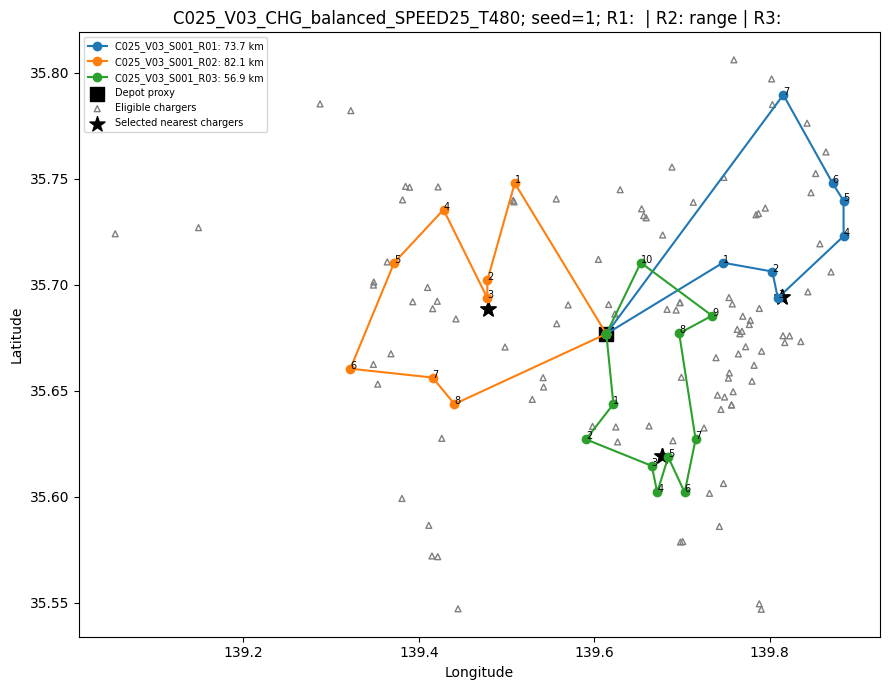

In [18]:
scenario_id='C025_V03_CHG_balanced_SPEED25_T480'; selected_seed=1
sample_edges=route_edges.query('customer_count==25 and vehicle_count==3 and seed==@selected_seed')
sample_results=route_results.query('scenario_id==@scenario_id and seed==@selected_seed')
fig,ax=plt.subplots(figsize=(9,7))
for route_id,edges in sample_edges.groupby('base_route_proxy_id'):
    ordered=edges.sort_values('proxy_edge_order')
    ax.plot(np.r_[ordered.from_longitude.iloc[0],ordered.to_longitude],np.r_[ordered.from_latitude.iloc[0],ordered.to_latitude],marker='o',label=f'{route_id}: {sample_results.loc[sample_results.base_route_proxy_id.eq(route_id),"route_proxy_distance_km"].iloc[0]:.1f} km')
for row in sample_edges[sample_edges.to_node_type.eq('synthetic_customer')].itertuples(): ax.annotate(str(row.proxy_edge_order),(row.to_longitude,row.to_latitude),fontsize=7)
selected_depots=depot_candidates[depot_candidates.scenario_depot_id.isin(sample_results.depot_candidate_id)]
ax.scatter(selected_depots.longitude,selected_depots.latitude,marker='s',s=90,c='black',label='Depot proxy')
ax.scatter(charger_candidates.query('charger_condition=="balanced"').longitude,charger_candidates.query('charger_condition=="balanced"').latitude,marker='^',s=18,facecolors='none',edgecolors='gray',label='Eligible chargers')
chosen=charger_candidates[charger_candidates.charger_candidate_id.isin(sample_results.nearest_candidate_charger_id.dropna())]
ax.scatter(chosen.longitude,chosen.latitude,marker='*',s=130,c='black',label='Selected nearest chargers')
unmet=[]
for r in sample_results.itertuples(): unmet.append(f'R{r.route_index}: '+', '.join(x for x,v in [('time',r.operating_time_feasible),('range',r.range_feasible),('access',r.charger_geographically_accessible)] if v is False))
ax.set(title=f'{scenario_id}; seed={selected_seed}; '+ ' | '.join(unmet),xlabel='Longitude',ylabel='Latitude'); ax.legend(fontsize=7); fig.tight_layout(); fig.savefig(FIGURES/'representative_route_proxy.png',dpi=320); fig.savefig(FIGURES/'representative_route_proxy.svg'); plt.show()

# 17. 制約の定義

`CELL-ID: METHOD-CONSTRAINT-01`

**目的:** 各制約の評価意味を定義する  
**入力:** ルート結果の各列  
**処理:** feasible・evaluated列を分子・分母へ対応付ける  
**出力:** `constraint_definitions.csv`  
**検証:** `NOT_EVALUATED`を欠損のまま保持する  
**解釈上の境界:** 地理的アクセスや静的航続距離はEV運用可能性全体を証明しない

# 17.1 制約の数理的定義

`CELL-ID: METHOD-CONSTRAINT-FORMAL-01`

ルート $r$ の顧客集合を $N_r$、需要を $d_i$、サービス時間を $q_i$、距離を $D_r$ とする。積載未充足指標は $U_{payload,r}=\mathbf{1}[\sum_{i\in N_r}d_i>C]$ である。運行時間は $T_r=(D_r/v)\times60+\sum_{i\in N_r}q_i$ とし、$U_{time,r}=\mathbf{1}[T_r>T_{max}]$ とする。ここで $v=25$ km/h、$T_{max}=480$ 分であり、休憩、待機、充電イベントは含まれない。

航続距離指標は $U_{range,r}=\mathbf{1}[D_r>R_{usable}]$ である。充電アクセスは、ルートプロキシのいずれかのノードから条件別候補までの最近傍地理距離と閾値を比較する。充電支援航続距離と充電時間は、航続距離超過ルートの一部に対する簡略化判定であり、充電地点到着時SOC、充電曲線、待ち時間、営業時間を表現しない。逐次SOC $SOC_{k+1}=SOC_k-E(d_{k,k+1},w_k)+Q_k$ は概念上必要だが、本分析では $E$ と $Q_k$ が実装されていないため、SOCは全件 `NOT_EVALUATED` とする。

In [19]:
constraint_rows=[
('C-PAYLOAD','Payload capacity','route proxy','unmet evaluated routes','all complete routes','route_total_demand_kg > payload_capacity_kg','route_total_demand_kg; payload_capacity_kg','kg','missing demand/capacity','synthetic demand','capacity signal','real loading rules'),
('C-TIME','Operating-time limit','route proxy','routes above limit','complete distance/speed/service routes','estimated_operating_time_min > operating_time_limit_min','route_proxy_distance_km; assumed_speed_kmh; route_service_time_min','minutes','missing inputs','constant speed; no charging/wait','time signal','traffic, breaks, windows'),
('C-RANGE','Range feasibility','route proxy','routes above usable range','complete route/range','route_proxy_distance_km > usable_range_km','route_proxy_distance_km; usable_range_km','km','missing inputs','fixed usable range','range signal','SOC transition, load/weather'),
('C-SOC','SOC feasibility','route sequence','NOT_EVALUATED','NOT_EVALUATED','NOT_EVALUATED','SOC state trajectory','kWh/SOC','all cases','model absent','none','all sequential SOC behavior'),
('C-ACCESS','Charging-station access','route proxy','no candidate within threshold','all condition routes','nearest_charger_distance_km > threshold','nearest_charger_distance_km; maximum_charger_access_distance_km','km','none','route-node geography','geographic access signal','availability, queue, hours'),
('C-ASSIST','Charging-assisted range','range-infeasible route','unsupported evaluable routes','range-infeasible routes','simplified two-range/access rule fails','distance; range; compatible candidate','km','range-feasible excluded','one simplified support event','support proxy','SOC/stop feasibility'),
('C-DURATION','Charging duration','evaluable assisted route','duration above limit','known positive power and accessible candidate','supplemental duration > limit','energy proxy; power; duration limit','minutes','unknown power/incompatible','constant power','duration proxy','taper, efficiency, queues')]
constraint_registry=pd.DataFrame(constraint_rows,columns=['constraint_id','constraint_name','evaluation_unit','numerator','denominator','unmet_condition','required_columns','unit','excluded_cases','assumptions','interpretation','not_captured'])
constraint_registry.to_csv(TABLES/'constraint_definitions.csv',index=False); display(constraint_registry)

,constraint_id,constraint_name,evaluation_unit,numerator,denominator,unmet_condition,required_columns,unit,excluded_cases,assumptions,interpretation,not_captured
0,C-PAYLOAD,Payload capacity,route proxy,unmet evaluated routes,all complete routes,route_total_demand_kg > payload_capacity_kg,route_total_demand_kg; payload_capacity_kg,kg,missing demand/capacity,synthetic demand,capacity signal,real loading rules
1,C-TIME,Operating-time limit,route proxy,routes above limit,complete distance/speed/service routes,estimated_operating_time_min > operating_time_...,route_proxy_distance_km; assumed_speed_kmh; ro...,minutes,missing inputs,constant speed; no charging/wait,time signal,"traffic, breaks, windows"
2,C-RANGE,Range feasibility,route proxy,routes above usable range,complete route/range,route_proxy_distance_km > usable_range_km,route_proxy_distance_km; usable_range_km,km,missing inputs,fixed usable range,range signal,"SOC transition, load/weather"
3,C-SOC,SOC feasibility,route sequence,NOT_EVALUATED,NOT_EVALUATED,NOT_EVALUATED,SOC state trajectory,kWh/SOC,all cases,model absent,none,all sequential SOC behavior
4,C-ACCESS,Charging-station access,route proxy,no candidate within threshold,all condition routes,nearest_charger_distance_km > threshold,nearest_charger_distance_km; maximum_charger_a...,km,none,route-node geography,geographic access signal,"availability, queue, hours"
5,C-ASSIST,Charging-assisted range,range-infeasible route,unsupported evaluable routes,range-infeasible routes,simplified two-range/access rule fails,distance; range; compatible candidate,km,range-feasible excluded,one simplified support event,support proxy,SOC/stop feasibility
6,C-DURATION,Charging duration,evaluable assisted route,duration above limit,known positive power and accessible candidate,supplemental duration > limit,energy proxy; power; duration limit,minutes,unknown power/incompatible,constant power,duration proxy,"taper, efficiency, queues"


# 18. 制約評価

`CELL-ID: METHOD-EVALUATION-01`

**目的:** 定義済み制約をルート単位で評価する  
**入力:** 再生成したルート結果  
**処理:** 横持ち結果をevaluated・feasible・unmetの縦持ち形式へ変換する  
**出力:** 56,700制約評価行  
**検証:** 真偽値の値域と欠損規則を検査する  
**解釈上の境界:** 未充足判定は現在のモデル仮定に条件づけられる

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-CONSTRAINT-EVALUATE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: どの運用制約がモデル上未充足となるか`  
`DECISION: 各制約を独立したevaluated/feasible/unmet判定へ変換する`  
`ACTION: 制約評価の縦持ち化`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: constraint_evaluations_long.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 重み付け別に集計する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** どの運用制約がモデル上未充足となるか  
**Method selected:** 各制約を独立したevaluated/feasible/unmet判定へ変換する  
**Expected evidence:** constraint_evaluations_long.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
どの運用制約がモデル上未充足となるか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
各制約を独立したevaluated/feasible/unmet判定へ変換する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
制約評価の縦持ち化。


In [20]:
constraint_evaluations=build_constraint_evaluations(route_results); case_rates=build_case_rates(constraint_evaluations); constraint_evaluations.to_csv(SYNTH/'constraint_evaluations_long.csv',index=False); case_rates.to_csv(SYNTH/'constraint_case_rates.csv',index=False); display(constraint_evaluations.head())

,scenario_id,scenario_route_proxy_id,seed,customer_count,vehicle_count,charger_condition,evaluated,feasible,unmet,constraint_name,numerator_definition,denominator_definition,main_assumption,evidence_status
0,C025_V01_CHG_balanced_SPEED25_T480,C025_V01_CHG_balanced_SPEED25_T480__S001_R01,1,25,1,balanced,True,True,False,Payload capacity,Routes whose synthetic route demand exceeds th...,All route proxies with complete synthetic dema...,Synthetic discrete-uniform customer demand and...,Synthetic data with assumed parameters
1,C025_V01_CHG_broad_SPEED25_T480,C025_V01_CHG_broad_SPEED25_T480__S001_R01,1,25,1,broad,True,True,False,Payload capacity,Routes whose synthetic route demand exceeds th...,All route proxies with complete synthetic dema...,Synthetic discrete-uniform customer demand and...,Synthetic data with assumed parameters
2,C025_V01_CHG_conservative_SPEED25_T480,C025_V01_CHG_conservative_SPEED25_T480__S001_R01,1,25,1,conservative,True,True,False,Payload capacity,Routes whose synthetic route demand exceeds th...,All route proxies with complete synthetic dema...,Synthetic discrete-uniform customer demand and...,Synthetic data with assumed parameters
3,C025_V03_CHG_balanced_SPEED25_T480,C025_V03_CHG_balanced_SPEED25_T480__S001_R01,1,25,3,balanced,True,True,False,Payload capacity,Routes whose synthetic route demand exceeds th...,All route proxies with complete synthetic dema...,Synthetic discrete-uniform customer demand and...,Synthetic data with assumed parameters
4,C025_V03_CHG_broad_SPEED25_T480,C025_V03_CHG_broad_SPEED25_T480__S001_R01,1,25,3,broad,True,True,False,Payload capacity,Routes whose synthetic route demand exceeds th...,All route proxies with complete synthetic dema...,Synthetic discrete-uniform customer demand and...,Synthetic data with assumed parameters


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-CONSTRAINT-EVALUATE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: どの運用制約がモデル上未充足となるか`  
`DECISION: 各制約を独立したevaluated/feasible/unmet判定へ変換する`  
`ACTION: 制約評価の縦持ち化`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: constraint_evaluations_long.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 重み付け別に集計する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** constraint_evaluations_long.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「どの運用制約がモデル上未充足となるか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 重み付け別に集計する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 19. 集計方法と統計的推定対象

`CELL-ID: METHOD-AGGREGATION-01`

**目的:** route・scenario・seedの重み付けを分離する  
**入力:** 縦持ち制約評価  
**処理:** 分子、分母、除外数、重み付け別の率を計算する  
**出力:** `estimand_comparison.csv`  
**検証:** 分子が分母以下であり率が0–1に入ること  
**解釈上の境界:** route-weighted集計では複数ルート条件の寄与が大きい

# 19.1 推定対象の定義

`CELL-ID: METHOD-ESTIMAND-FORMAL-01`

制約 $c$ が評価可能なルート集合を $\mathcal{R}_c$ とし、未充足指標を $U_{r,c}\in\{0,1\}$ とする。主結果のroute-weighted未充足率は、

$$\hat p_c^{route}=\frac{\sum_{r\in\mathcal{R}_c}U_{r,c}}{|\mathcal{R}_c|}$$

である。この推定量では5車両条件が1車両条件より多くのルートを持つため、より大きな重みを持つ。scenario-weighted率は各 `(scenario_id, seed)` 内のルート率を同じ重みで平均し、seed-weighted率は各seedに属する全評価可能ルートの率を先に計算してseed間で平均する。したがって三者は同じ母数の別表現ではなく、異なる重み付け規則に基づく記述的推定量である。解釈対象は、固定された合成データ生成機構、ルートプロキシ、パラメータ集合の下で生成される分析対象ルートであり、東京都の実配送母集団ではない。

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-AGGREGATION-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 集計単位で結果がどう変わるか`  
`DECISION: route・scenario・seed weightingを分離する`  
`ACTION: 分子・分母・率の比較`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: estimand_comparison.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: seed依存の区間を評価する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 集計単位で結果がどう変わるか  
**Method selected:** route・scenario・seed weightingを分離する  
**Expected evidence:** estimand_comparison.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
集計単位で結果がどう変わるか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
route・scenario・seed weightingを分離する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
分子・分母・率の比較。


In [21]:
evaluated=constraint_evaluations[constraint_evaluations.evaluated.astype(bool)].copy(); evaluated['unmet_int']=evaluated.unmet.astype(bool).astype(int)
rows=[]
for constraint,group in constraint_evaluations.groupby('constraint_name'):
    eg=group[group.evaluated.astype(bool)].copy(); route_rate=eg.unmet.astype(bool).mean() if len(eg) else np.nan
    cases=case_rates.query('constraint_name==@constraint').dropna(subset=['case_unmet_rate'])
    seed_counts=eg.assign(unmet_int=eg.unmet.astype(bool).astype(int)).groupby('seed').agg(unmet_count=('unmet_int','sum'),evaluated_count=('unmet_int','size')); seed_rates=seed_counts.unmet_count/seed_counts.evaluated_count
    for method,rate,n in [('route-weighted',route_rate,len(eg)),('scenario-weighted',cases.case_unmet_rate.mean() if len(cases) else np.nan,len(cases)),('seed-weighted',seed_rates.mean() if len(seed_rates) else np.nan,len(seed_rates))]: rows.append({'constraint_name':constraint,'weighting_method':method,'evaluated_count':n,'excluded_count':len(group)-len(eg) if method=='route-weighted' else np.nan,'unmet_count':int(eg.unmet.astype(bool).sum()) if len(eg) else 0,'unmet_rate':rate,'confidence_interval':'computed for route-weighted seed-cluster estimand in Section 20'})
estimand_comparison=pd.DataFrame(rows); estimand_comparison.to_csv(TABLES/'estimand_comparison.csv',index=False); display(estimand_comparison)

,constraint_name,weighting_method,evaluated_count,excluded_count,unmet_count,unmet_rate,confidence_interval
0,Charging-assisted range feasibility,route-weighted,5220,2880.0,1738,0.332950,computed for route-weighted seed-cluster estim...
1,Charging-assisted range feasibility,scenario-weighted,2619,NaN,1738,0.469855,computed for route-weighted seed-cluster estim...
2,Charging-assisted range feasibility,seed-weighted,100,NaN,1738,0.335182,computed for route-weighted seed-cluster estim...
3,Charging-duration feasibility,route-weighted,4849,3251.0,742,0.153021,computed for route-weighted seed-cluster estim...
4,Charging-duration feasibility,scenario-weighted,2534,NaN,742,0.286569,computed for route-weighted seed-cluster estim...
5,Charging-duration feasibility,seed-weighted,100,NaN,742,0.154083,computed for route-weighted seed-cluster estim...
6,Charging-station access,route-weighted,8100,0.0,866,0.106914,computed for route-weighted seed-cluster estim...
7,Charging-station access,scenario-weighted,2700,NaN,866,0.076691,computed for route-weighted seed-cluster estim...
8,Charging-station access,seed-weighted,100,NaN,866,0.106914,computed for route-weighted seed-cluster estim...
9,Operating-time limit,route-weighted,8100,0.0,2715,0.335185,computed for route-weighted seed-cluster estim...


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-AGGREGATION-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 集計単位で結果がどう変わるか`  
`DECISION: route・scenario・seed weightingを分離する`  
`ACTION: 分子・分母・率の比較`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: estimand_comparison.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: seed依存の区間を評価する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** estimand_comparison.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「集計単位で結果がどう変わるか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** seed依存の区間を評価する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 20. ブートストラップ手続き

`CELL-ID: METHOD-BOOTSTRAP-01`

**目的:** 合成seedによる変動を定量化する  
**入力:** seedでクラスタ化した全条件・全ルート  
**処理:** 100 seedクラスタを復元抽出し対応関係を保持する。1,000反復、percentile 2.5/97.5%、seed 20260711  
**出力:** 制約集計と信頼区間  
**検証:** 保存済み集計との一致  
**解釈上の境界:** 区間はデータ取得・モデル・パラメータ・実運用の不確実性を含まない

# 20.1 ブートストラップ推定

`CELL-ID: METHOD-BOOTSTRAP-FORMAL-01`

同一seedから生成された顧客集合は、車両数・充電条件を横断して共有されるため、個々のroute-condition行を独立標本として再標本化しない。反復 $b$ ごとに100個のseed IDを復元抽出し、選択されたseedに属する全条件・全ルートを保持して $\hat p_c^{(b)}$ を再計算する。95%区間は1,000個の有限な反復値の2.5および97.5パーセンタイルである。

この区間が表すのは、凍結済み人口メッシュ、固定分布、固定パラメータ、固定ルートアルゴリズムの下でのseedクラスタ変動である。データ取得誤差、需要分布のモデル不確実性、道路距離係数の妥当性、車両仕様の誤差、充電器の実利用可能性は区間に含まれない。したがって区間幅を研究全体の不確実性と解釈してはならない。

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-BOOTSTRAP-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 対応のある合成反復の変動をどう表すか`  
`DECISION: seedクラスタBootstrapを使用する`  
`ACTION: 1,000回のpercentile区間計算`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: constraint_summary.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 仮定変更への感度を調べる`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 対応のある合成反復の変動をどう表すか  
**Method selected:** seedクラスタBootstrapを使用する  
**Expected evidence:** constraint_summary.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
対応のある合成反復の変動をどう表すか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
seedクラスタBootstrapを使用する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
1,000回のpercentile区間計算。


In [22]:
constraint_summary=cluster_bootstrap_constraint_summary(constraint_evaluations,case_rates,iterations=1000,random_seed=20260711)
constraint_summary.to_csv(SYNTH/'constraint_summary.csv',index=False)
stored_summary=pd.read_csv(required_files['stored_summary'][0]); summary_match,summary_match_detail=compare_frames(constraint_summary,stored_summary)
display(constraint_summary[['constraint_name','unmet_route_count','evaluated_route_count','route_weighted_unmet_rate','confidence_interval_lower','confidence_interval_upper']]); print(summary_match,summary_match_detail)

,constraint_name,unmet_route_count,evaluated_route_count,route_weighted_unmet_rate,confidence_interval_lower,confidence_interval_upper
0,Payload capacity,0,8100,0.000000,0.000000,0.000000
1,Operating-time limit,2715,8100,0.335185,0.327778,0.343333
2,Range feasibility,5220,8100,0.644444,0.631111,0.657407
3,SOC feasibility,0,0,NaN,NaN,NaN
4,Charging-station access,866,8100,0.106914,0.100123,0.113580
5,Charging-assisted range feasibility,1738,5220,0.332950,0.321483,0.344649
6,Charging-duration feasibility,742,4849,0.153021,0.148042,0.157951


True all rows and columns equivalent after explicit NA/type normalization


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-BOOTSTRAP-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 対応のある合成反復の変動をどう表すか`  
`DECISION: seedクラスタBootstrapを使用する`  
`ACTION: 1,000回のpercentile区間計算`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: constraint_summary.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 仮定変更への感度を調べる`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** constraint_summary.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「対応のある合成反復の変動をどう表すか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 仮定変更への感度を調べる。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 21. 感度分析

`CELL-ID: METHOD-SENSITIVITY-01`

**目的:** 一度に一つのパラメータを変えた応答を測る  
**入力:** 再生成ルートとlow・base・highレジストリ  
**処理:** 他のパラメータを固定して対象パラメータだけを変更する  
**出力:** `sensitivity_detail.csv`  
**検証:** 基準値との差と相対差を計算する  
**解釈上の境界:** パラメータ間相互作用や較正不確実性は評価しない

# 21.1 感度推定量と分析範囲

`CELL-ID: METHOD-SENSITIVITY-FORMAL-01`

パラメータ $\theta_j$ の代替水準 $a$ に対する感度は、他のパラメータを基準値に固定した未充足率差 $\Delta_{c,j,a}=\hat p_c(\theta_j=a)-\hat p_c(\theta_j=base)$ として記録する。相対差は基準率が0でない場合のみ $\Delta_{c,j,a}/\hat p_c(base)$ とする。OATは局所的なモデル応答を可視化する設計であり、例えば速度と道路距離係数、航続距離と充電条件の相互作用を推定しない。また、代替水準の確率や現実性を評価しないため、感度の大きさは政策効果や因果効果ではない。

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-SENSITIVITY-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 基準結果が特定仮定に依存する程度はどれか`  
`DECISION: 一度に一パラメータだけ変更する`  
`ACTION: low/base/high OAT比較`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: sensitivity_detail.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 結果とモデル要件を解釈する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 基準結果が特定仮定に依存する程度はどれか  
**Method selected:** 一度に一パラメータだけ変更する  
**Expected evidence:** sensitivity_detail.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
基準結果が特定仮定に依存する程度はどれか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
一度に一パラメータだけ変更する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
low/base/high OAT比較。


In [23]:
sensitivity_raw,parameter_response=run_oat_sensitivity(route_results,analysis_parameters,baseline_vehicle)
sensitivity_detail=sensitivity_raw.rename(columns={'parameter_value':'alternative_value','base_unmet_rate':'baseline_result','route_weighted_unmet_rate':'sensitivity_result','unmet_rate_change_from_base':'absolute_change'}).copy()
sensitivity_detail['baseline_value']=sensitivity_detail.parameter.map(analysis_parameters.set_index('parameter')['base'])
sensitivity_detail['unit']=sensitivity_detail.parameter.map(analysis_parameters.set_index('parameter')['unit'])
sensitivity_detail['direction_of_change']=sensitivity_detail.level
sensitivity_detail['affected_metric']=sensitivity_detail.constraint_name
sensitivity_detail['relative_change']=sensitivity_detail.absolute_change/sensitivity_detail.baseline_result.replace(0,np.nan)
sensitivity_detail['interpretation']='OAT model response under frozen synthetic data'
sensitivity_detail['limitation']='No parameter interaction or operational calibration'
sensitivity_detail.to_csv(TABLES/'sensitivity_detail.csv',index=False); display(sensitivity_detail.head(20))

,parameter,level,alternative_value,constraint_name,sensitivity_result,evaluated_route_count,unmet_route_count,customer_count_for_evaluation,vehicle_count_for_evaluation,charger_condition_for_evaluation,...,evidence_status,baseline_result,absolute_change,baseline_value,unit,direction_of_change,affected_metric,relative_change,interpretation,limitation
0,assumed_speed_kmh,low,20.0,Payload capacity,0.000000,300,0,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.000000,0.000000,25.00,km/h,low,Payload capacity,NaN,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...
1,assumed_speed_kmh,low,20.0,Operating-time limit,0.656667,300,197,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.383333,0.273333,25.00,km/h,low,Operating-time limit,0.713043,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...
2,assumed_speed_kmh,low,20.0,Range feasibility,0.940000,300,282,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.940000,0.000000,25.00,km/h,low,Range feasibility,0.000000,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...
3,assumed_speed_kmh,low,20.0,Charging-station access,0.000000,300,0,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.000000,0.000000,25.00,km/h,low,Charging-station access,NaN,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...
4,assumed_speed_kmh,low,20.0,Charging-assisted range feasibility,0.056738,282,16,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.056738,0.000000,25.00,km/h,low,Charging-assisted range feasibility,0.000000,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...
5,assumed_speed_kmh,low,20.0,Charging-duration feasibility,0.000000,282,0,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.000000,0.000000,25.00,km/h,low,Charging-duration feasibility,NaN,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...
6,assumed_speed_kmh,base,25.0,Payload capacity,0.000000,300,0,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.000000,0.000000,25.00,km/h,base,Payload capacity,NaN,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...
7,assumed_speed_kmh,base,25.0,Operating-time limit,0.383333,300,115,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.383333,0.000000,25.00,km/h,base,Operating-time limit,0.000000,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...
8,assumed_speed_kmh,base,25.0,Range feasibility,0.940000,300,282,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.940000,0.000000,25.00,km/h,base,Range feasibility,0.000000,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...
9,assumed_speed_kmh,base,25.0,Charging-station access,0.000000,300,0,50,3,balanced,...,Exploratory parameter sensitivity; not calibra...,0.000000,0.000000,25.00,km/h,base,Charging-station access,NaN,OAT model response under frozen synthetic data,No parameter interaction or operational calibr...


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-SENSITIVITY-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 基準結果が特定仮定に依存する程度はどれか`  
`DECISION: 一度に一パラメータだけ変更する`  
`ACTION: low/base/high OAT比較`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: sensitivity_detail.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 結果とモデル要件を解釈する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** sensitivity_detail.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「基準結果が特定仮定に依存する程度はどれか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 結果とモデル要件を解釈する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 22. Related Work / Survey Method

`CELL-ID: CIRCUIT-SURVEY-METHOD-01`

本節は、研究スライドとローカルに保存された一次資料を起点として、輸送・経路最適化に関する量子定式化のCircuit Widthを整理した**探索的な構造化サーベイ**である。網羅的なsystematic reviewまたはscoping reviewではない。過去の検索式、全検索結果、採択判断の同時期記録は完全には保存されていないため、検索史全体は`NOT_DOCUMENTED`である。2026-07-13の改訂では、ローカルPDF、arXiv一次記録、出版社ページを用い、既存候補文献の表題、著者、arXiv ID、DOI、本文中の`qubit`、`width`、`route`、式、表、図を対象とする一次資料の標的確認を行った。後方・前方引用検索は実施していない。

採択対象は、輸送・経路・配送問題を扱い、量子アルゴリズム、QAOA、VQA、QUBO、HOBOまたはIsing定式化を用い、Width、qubit数、またはその式と問題規模を確認できる一次資料である。輸送問題に対応しない基礎論文、ベンチマーク方法論のみの論文、二次レビュー、および対象インスタンスとWidthの対応を確認できない文献は値の統合から除外し、理由を`circuit_width_excluded_studies.csv`へ記録する。論文に記載がない制約は`Not reported`とし、`Not implemented`とは判定しない。検索・採択基準、抽出項目、可視化および品質基準は事前登録されておらず、本改訂で`DEFINED_DURING_ANALYSIS`として構造化した。

# 22.1 Circuit Width Survey Summary

`CELL-ID: CIRCUIT-SURVEY-SUMMARY-01`

## 1. Survey objective

本サーベイは量子輸送最適化研究の性能順位を決定せず、最小qubit数を報告した方法を優れた手法として選定しない。目的は、報告Widthがどの問題規模、定式化、符号化、制約表現に対応するかを追跡し、文献間で直接比較できる範囲を限定することである。

## 2. Scope of literature

対象は現在のローカル一次資料群に含まれるVRP、CVRP、VRPTW、HVRPおよびCVRPから分解されたTSP定式化である。現在の文献集合を量子VRP研究全体へ一般化してはならない。

## 3. Search and screening method

検索日、検索源、実際に確認した語、採択・除外基準、重複処理、未実施の引用検索、reviewerおよびmissing-information policyは`circuit_width_search_protocol.csv`に記録する。履歴がない項目は推測せず`NOT_DOCUMENTED`とする。

## 4. Definition of Circuit Width

原則としてCircuit Widthは量子回路で同時に使用されるqubit数である。ただし、logical qubits、physical qubits、problem/binary/decision variables、ancilla、slack、penalty auxiliary、embedding qubits、device qubitsを区別する。文献が単にqubitsと記載し論理・物理を区別しない場合、その不確実性を保持する。Widthは必要資源の一側面であり、小さいWidthは浅い回路、少ないゲート、高い解品質、短い実行時間、ノイズ耐性、物理qubit削減、古典優位または社会実装可能性を意味しない。

## 5. Data-extraction protocol

文献単位で問題形式、インスタンス規模、車両数、定式化、符号化、制約、Width値または式、論理・物理区分、深さ、ゲート、実機実行、出典位置、抽出方法、検証状態、reviewer、注記を保持する。概念的には $W=n_{decision}+n_{auxiliary}+n_{slack}+n_{ancilla}$ と分解できるが、実文献の式を優先し、確認不能な内訳を推測しない。

## 6. Survey results

数値、式、文献数、検証状態の集計は下のコードで詳細表から自動生成する。式のみを報告する行は、任意のインスタンスを代入して架空の数値へ変換しない。

## 7. Cross-study comparison

同じ顧客数でも、エッジ、ノード・時刻、車両添字、容量、時間窓、サブツアー除去、SOC、充電、高次項の二次化、slack、ancillaによりWidthは変化する。routes、customers、nodes、locationsの異なる規模定義を一つの回帰線で結ばない。

## 8. Relationship to application requirements

Width値が小さくても、時間窓、SOC、充電、異種車両等が表現されているとは限らない。本Notebookの制約評価は確認項目を与えるが、制約追加によるWidth増分を算出しない。

## 9. Evidence-quality assessment

Grade Aは一次資料の値・位置・問題規模・定義を追跡できる行、Bは式または一部定義を追跡できる行、Cは本文・図の値のみで定義が不十分な行、Dはスライド・二次資料転記、Eは出典または定義を確認できない行である。このGradeは研究手法の優劣ではなく抽出情報の追跡可能性を表す。

## 10. Limitations of the survey

対象文献集合は便宜的なローカルコーパスから開始しており網羅性を保証しない。独立した人手の第二reviewer、完全な検索ログ、事前登録、全式の再実装、物理qubit変換は存在しない。

## 11. Implications for the present study

本Notebookの合成輸送シナリオから文献Widthを導出していない。運用制約の未充足率とWidthとの因果的・定量的関係も推定していない。

# 22.2 Circuit Width Evidence Registry

`CELL-ID: REFERENCE-CIRCUIT-01`

**目的:** 文献参照値と再現計算値を分離する  
**入力:** スライド7・22およびローカル一次資料  
**処理:** 定義と証拠状態を登録し、計算再現を主張しない  
**出力:** `circuit_width_evidence.csv`  
**検証:** 出典箇所未確認の値を`SOURCE_NOT_VERIFIED`とする  
**解釈上の境界:** 回路幅・qubit数は計算費用全体や物理資源量と同一ではない

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-CIRCUIT-EVIDENCE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 運用要件と量子資源参照をどう接続するか`  
`DECISION: 回路幅を計算結果でなく証拠レジストリとして保持する`  
`ACTION: 出典・定義・検証状態の符号化`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: circuit_width_evidence.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 参照図を分類して作成する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 運用要件と量子資源参照をどう接続するか  
**Method selected:** 回路幅を計算結果でなく証拠レジストリとして保持する  
**Expected evidence:** circuit_width_evidence.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
運用要件と量子資源参照をどう接続するか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
回路幅を計算結果でなく証拠レジストリとして保持する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
出典・定義・検証状態の符号化。


In [24]:
from circuit_width_survey import build_survey_outputs
circuit_survey=build_survey_outputs(required_files['circuit_resources'][0],required_files['paper_registry'][0],TABLES,FIGURES)
circuit_width_survey_full=circuit_survey['full']; circuit_evidence=circuit_survey['registry']
circuit_width_survey_summary=circuit_survey['summary']; circuit_width_verification_summary=circuit_survey['verification']
circuit_width_constraint_coverage=circuit_survey['coverage']; circuit_width_excluded_studies=circuit_survey['excluded']
circuit_width_survey_flow=circuit_survey['flow']; circuit_width_search_protocol=circuit_survey['search_protocol']
circuit_width_survey_validation=circuit_survey['validation']
display(circuit_width_search_protocol)
display(circuit_width_survey_flow)
display(circuit_width_survey_summary)
display(circuit_width_verification_summary)
display(circuit_evidence)
display(circuit_width_survey_validation)
if circuit_width_survey_validation.status.eq('FAIL').any():
    raise AssertionError('Circuit-width survey validation failed')

,field,current_setting,status,interpretation_note
0,survey_type,exploratory structured literature survey,DOCUMENTED,Not a systematic review or exhaustive scoping ...
1,search_date,2026-07-13,DOCUMENTED,Date of the targeted primary-source verificati...
2,starting_population,"Research slides, local papers.csv, local prima...",DOCUMENTED,Earlier discovery process is NOT_DOCUMENTED
3,search_sources,Local primary-source PDF corpus; arXiv abstrac...,DOCUMENTED,No subscription database search was performed ...
4,search_terms,"Exact paper titles, author names, arXiv IDs 23...",DOCUMENTED,The illustrative Boolean query in the specific...
5,publication_period,No ex-ante period restriction documented,NOT_DOCUMENTED,Current eligible local records span 2020-2025;...
6,language_restriction,English-language local primary sources,DEFINED_DURING_ANALYSIS,A prior language restriction is NOT_DOCUMENTED
7,document_type,"Primary research articles, conference papers, ...",DEFINED_DURING_ANALYSIS,Reviews are retained as background but exclude...
8,backward_citation_search,Not performed for this revision,NOT_PERFORMED,No exhaustive ancestry search claimed
9,forward_citation_search,Not performed for this revision,NOT_PERFORMED,No exhaustive citation-index search claimed


,stage,count,count_scope_and_caveat
0,Local literature records identified,17,Current local papers.csv; historical search un...
1,Duplicate IDs removed,0,Current registry ID check; not a historical PR...
2,Records screened against scope,17,Title/problem/method metadata screening
3,Studies containing eligible width evidence,8,Transportation/routing primary-source extracti...
4,Structured width/formula records,25,One row per extracted instance/formula record
5,Numeric values directly traceable,19,Primary-source locator retained
6,Slide values retained as source-not-verified,4,Not counted as verified survey results


,problem_variant,studies,instance_size_range,width_range,typical_formulation,main_constraints_represented,evidence_quality
0,CVRP,2,200-200 nodes,7685-202505 qubits,HOBO/direct encoding; QUBO; feasibility-preser...,capacity; multiple vehicles,A; B
1,CVRP/TSP decomposition,1,4-6 nodes,9-25 qubits,clustering + TSP; QAOA and hardware-efficient VQE,capacity,A
2,HVRP,1,3-4 customers,11-21 qubits,Ising mapping,capacity; heterogeneous fleet; multiple vehicles,A
3,TSP,1,Not consistently reported,Formula only,Enumerating / VQE-oriented encoding; HOBO enco...,Not reported,B
4,VRP,2,4-5 locations; 3-5 nodes,6-30 qubits,edge-based Ising/QAOA encoding; edge-based lin...,multiple vehicles; subtour elimination,A; B
5,VRPTW,1,11-3964 routes,5-16 qubits,full encoding; minimal encoding,time window,A


,verification_status,number_of_values,meaning
0,DIRECTLY_REPORTED,19,Primary-source value or formula with a traceab...
1,FORMULA_DERIVED,0,Recalculated from a source formula and recorde...
2,SLIDE_TRANSCRIBED,0,Transcribed from a research slide only
3,SOURCE_NOT_VERIFIED,4,No matching primary-source value/location veri...


,evidence_id,survey_id,reported_value,value_type,unit,width_definition,logical_or_physical,problem_family,problem_variant,instance_size,...,equation,table_or_figure,extraction_method,verification_status,evidence_quality,notes,metric_definition,problem_type,DOI_or_URL,status
0,CW-VERIFIED-001,SURV-001,11.0,NUMERIC_VALUE,qubits,logical qubits or circuit wires used by the re...,logical/resource-level; physical mapping not e...,transportation/routing optimization,VRPTW,11-route instance,...,W = n_c,Fig. 3 and Section VI,local primary-source PDF/text extraction follo...,DIRECTLY_REPORTED,A,Full encoding maps one route variable to one q...,logical qubits or circuit wires used by the re...,VRPTW,10.48550/arXiv.2306.08507,DIRECTLY_REPORTED
1,CW-VERIFIED-002,SURV-002,16.0,NUMERIC_VALUE,qubits,logical qubits or circuit wires used by the re...,logical/resource-level; physical mapping not e...,transportation/routing optimization,VRPTW,16-route instance,...,W = n_c,Fig. 4 and Section VI,local primary-source PDF/text extraction follo...,DIRECTLY_REPORTED,A,Full encoding maps one route variable to one q...,logical qubits or circuit wires used by the re...,VRPTW,10.48550/arXiv.2306.08507,DIRECTLY_REPORTED
2,CW-VERIFIED-003,SURV-003,5.0,NUMERIC_VALUE,qubits,logical qubits or circuit wires used by the re...,logical/resource-level; physical mapping not e...,transportation/routing optimization,VRPTW,16-route instance,...,W = 1 + ceil(log2(n_c)),Fig. 4 and Section VI,local primary-source PDF/text extraction follo...,DIRECTLY_REPORTED,A,Minimal encoding uses 1 + ceil(log2(n_c)) qubi...,logical qubits or circuit wires used by the re...,VRPTW,10.48550/arXiv.2306.08507,DIRECTLY_REPORTED
3,CW-VERIFIED-004,SURV-004,8.0,NUMERIC_VALUE,qubits,logical qubits or circuit wires used by the re...,logical/resource-level; physical mapping not e...,transportation/routing optimization,VRPTW,128-route instance,...,W = 1 + ceil(log2(n_c)),Fig. 6 and Section VI,local primary-source PDF/text extraction follo...,DIRECTLY_REPORTED,A,Minimal encoding uses 1 + ceil(log2(n_c)) qubi...,logical qubits or circuit wires used by the re...,VRPTW,10.48550/arXiv.2306.08507,DIRECTLY_REPORTED
4,CW-VERIFIED-005,SURV-005,13.0,NUMERIC_VALUE,qubits,logical qubits or circuit wires used by the re...,logical/resource-level; physical mapping not e...,transportation/routing optimization,VRPTW,3964-route instance,...,W = 1 + ceil(log2(n_c)),Fig. 6 and Section VI,local primary-source PDF/text extraction follo...,DIRECTLY_REPORTED,A,Minimal encoding uses 1 + ceil(log2(n_c)) qubi...,logical qubits or circuit wires used by the re...,VRPTW,10.48550/arXiv.2306.08507,DIRECTLY_REPORTED
5,CW-VERIFIED-006,SURV-006,11.0,NUMERIC_VALUE,qubits,logical qubits or circuit wires used by the re...,logical/resource-level; physical mapping not e...,transportation/routing optimization,HVRP,problem instance I,...,W = W_routing + W_capacity,Table 1; Figs; Eq. 26,local primary-source PDF/text extraction follo...,DIRECTLY_REPORTED,A,The paper treats p as circuit depth and report...,logical qubits or circuit wires used by the re...,HVRP,10.1038/s41598-024-76967-w,DIRECTLY_REPORTED
6,CW-VERIFIED-007,SURV-007,19.0,NUMERIC_VALUE,qubits,logical qubits or circuit wires used by the re...,logical/resource-level; physical mapping not e...,transportation/routing optimization,HVRP,problem instance II,...,W = W_routing + W_capacity,Table 1; Figs; Eq. 26,local primary-source PDF/text extraction follo...,DIRECTLY_REPORTED,A,The paper treats p as circuit depth and report...,logical qubits or circuit wires used by the re...,HVRP,10.1038/s41598-024-76967-w,DIRECTLY_REPORTED
7,CW-VERIFIED-008,SURV-008,21.0,NUMERIC_VALUE,qubits,logical qubits or circuit wires used by the re...,logical/resource-level; physical mapping not e...,transportation/routing optimization,HVRP,problem instance III,...,W = W_routing + W_capacity,Table 1; Figs; Eq. 26,local primary-source PDF/text extraction follo...,DIRECTLY_REPORTED,A,The paper treats p as circuit 

,test_id,description,status,observed
0,CW01,survey_id is unique,PASS,0
1,CW02,each registry value has survey_id,PASS,0
2,CW03,each registry value has verification_status,PASS,0
3,CW04,all numeric reported widths are positive,PASS,5.0
4,CW05,all numeric values have units,PASS,0
5,CW06,direct reports have a page/section/table/figur...,PASS,0
6,CW07,formula-derived values have equation records,PASS,0
7,CW08,unverified slide values are not counted as dir...,PASS,4
8,CW09,logical/physical semantics are recorded,PASS,0
9,CW10,summary is generated from full survey variants,PASS,6


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-CIRCUIT-EVIDENCE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 運用要件と量子資源参照をどう接続するか`  
`DECISION: 回路幅を計算結果でなく証拠レジストリとして保持する`  
`ACTION: 出典・定義・検証状態の符号化`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: circuit_width_evidence.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 参照図を分類して作成する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** circuit_width_evidence.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「運用要件と量子資源参照をどう接続するか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 参照図を分類して作成する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 22.3 Application-Requirement Analysis

`CELL-ID: CIRCUIT-APPLICATION-LINK-01`

文献は問題規模とWidthまたはqubit数を報告するが、その規模だけではどの運用制約を表現した値か判断できない場合がある。本Notebookは積載、運行時間、航続距離、充電アクセス、充電時間、SOC等を個別に整理し、Width証拠を解釈する際のアプリケーション要件チェック項目を提供する。制約未充足率が高い条件は、その制約をアプリケーションモデルから除外した場合に対象シナリオの運用条件を十分に表現できない可能性を示す。ただし、当該制約を量子定式化へ追加した場合の変数数、Width、Depth、ゲート数の増分は算出していない。したがって、未充足率が高いことから必要qubit数が増加すると結論してはならない。

# 23. 図表の生成

`CELL-ID: OUTPUT-REGISTRY-01`

**目的:** 図表を分類し解釈情報を保存する  
**入力:** 実行済みデータオブジェクト  
**処理:** 図表を生成し出力レジストリへ登録する  
**出力:** 図および`figure_table_registry.csv`  
**検証:** ファイルが存在し空でないこと  
**解釈上の境界:** 概念図・参照値再描画を再現済み実証結果として扱わない

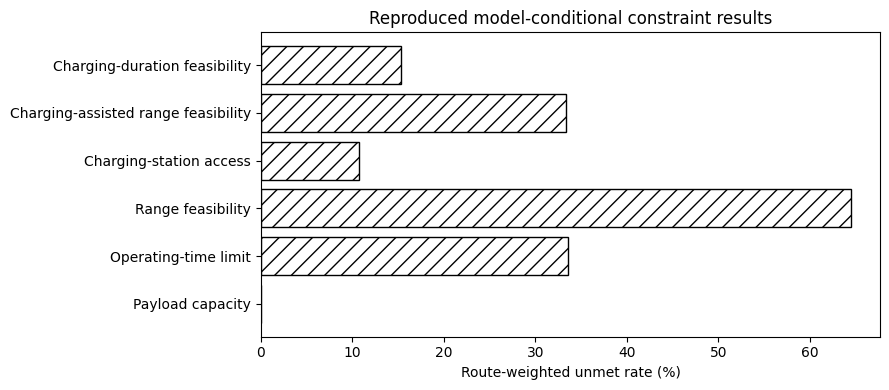

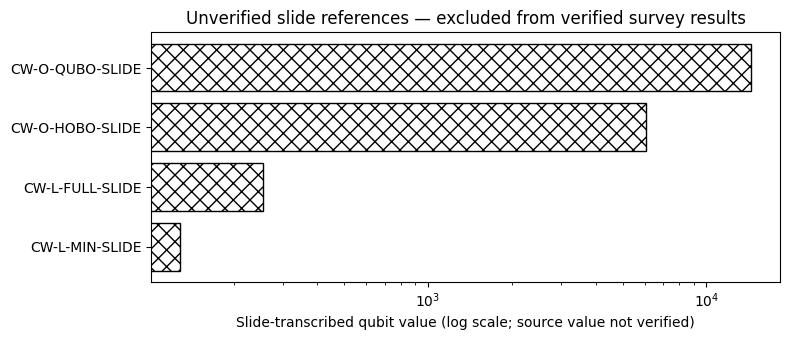

,figure_id_or_table_id,title,classification,source_data,generating_cell,generating_function,output_path,interpretation,limitation
0,FIG-ROUTE,Representative route proxy,MODEL_DERIVED,route_edges; route_results,ROUTE-FIGURE-01,matplotlib,outputs/figures/representative_route_proxy.png,Shows algorithmic route proxy,Not road route/optimum
1,FIG-CONSTRAINT,Constraint unmet rates,REPRODUCED,constraint_summary,FIGURE-GENERATE-01,matplotlib,outputs/figures/constraint_rates_reproduced.png,Shows route-weighted synthetic rates,Not operational failures
2,FIG-CIRCUIT-UNVERIFIED,Unverified circuit-width slide references,REFERENCE_REPLOTTED,circuit_evidence,FIGURE-GENERATE-01,matplotlib,outputs/figures/circuit_width_reference_replot...,Shows only SOURCE_NOT_VERIFIED slide values,Excluded from verified survey synthesis
3,FIG-CIRCUIT-SIZE,Circuit width versus instance size,LITERATURE_DERIVED,circuit_width_survey_full,CIRCUIT-EVIDENCE-01,circuit_width_survey.plot_width_vs_size,outputs/figures/circuit_width_vs_instance_size...,Compares values only in panels with a shared s...,No cross-unit regression or performance ranking
4,FIG-CIRCUIT-CONSTRAINT,Constraint reporting coverage,LITERATURE_DERIVED,circuit_width_constraint_coverage,CIRCUIT-EVIDENCE-01,circuit_width_survey.plot_constraint_coverage,outputs/figures/circuit_width_constraint_cover...,"Distinguishes Reported, Not reported, Not appl...",Not reported is not evidence of non-implementa...
5,FIG-CIRCUIT-COMPONENTS,Circuit-width components,LITERATURE_DERIVED,circuit_width_survey_full,CIRCUIT-EVIDENCE-01,circuit_width_survey.plot_components,outputs/figures/circuit_width_components.png,Shows reported routing/capacity components for...,No inferred decomposition for other studies
6,TABLE-PARAM,Parameter registry,DATA_DERIVED,source/config,PARAMETERS-CODE-01,pandas,outputs/tables/parameter_registry.csv,Central constants,Includes assumptions


In [25]:
fig,ax=plt.subplots(figsize=(9,4)); plot_data=constraint_summary.dropna(subset=['route_weighted_unmet_rate']); ax.barh(plot_data.constraint_name,plot_data.route_weighted_unmet_rate*100,facecolor='white',edgecolor='black',hatch='//'); ax.set(xlabel='Route-weighted unmet rate (%)',title='Reproduced model-conditional constraint results'); fig.tight_layout(); fig.savefig(FIGURES/'constraint_rates_reproduced.png',dpi=320); fig.savefig(FIGURES/'constraint_rates_reproduced.svg'); plt.show()
slide_refs=circuit_evidence[circuit_evidence.verification_status.eq('SOURCE_NOT_VERIFIED')]
fig,ax=plt.subplots(figsize=(8,3.5)); ax.barh(slide_refs.evidence_id,slide_refs.reported_value,facecolor='none',edgecolor='black',hatch='xx'); ax.set_xscale('log'); ax.set(xlabel='Slide-transcribed qubit value (log scale; source value not verified)',title='Unverified slide references — excluded from verified survey results'); fig.tight_layout(); fig.savefig(FIGURES/'circuit_width_reference_replotted.png',dpi=320); fig.savefig(FIGURES/'circuit_width_reference_replotted.svg'); plt.show()
output_registry=pd.DataFrame([
('FIG-ROUTE','Representative route proxy','MODEL_DERIVED','route_edges; route_results','ROUTE-FIGURE-01','matplotlib','outputs/figures/representative_route_proxy.png','Shows algorithmic route proxy','Not road route/optimum'),
('FIG-CONSTRAINT','Constraint unmet rates','REPRODUCED','constraint_summary','FIGURE-GENERATE-01','matplotlib','outputs/figures/constraint_rates_reproduced.png','Shows route-weighted synthetic rates','Not operational failures'),
('FIG-CIRCUIT-UNVERIFIED','Unverified circuit-width slide references','REFERENCE_REPLOTTED','circuit_evidence','FIGURE-GENERATE-01','matplotlib','outputs/figures/circuit_width_reference_replotted.png','Shows only SOURCE_NOT_VERIFIED slide values','Excluded from verified survey synthesis'),
('FIG-CIRCUIT-SIZE','Circuit width versus instance size','LITERATURE_DERIVED','circuit_width_survey_full','CIRCUIT-EVIDENCE-01','circuit_width_survey.plot_width_vs_size','outputs/figures/circuit_width_vs_instance_size.png','Compares values only in panels with a shared size unit','No cross-unit regression or performance ranking'),
('FIG-CIRCUIT-CONSTRAINT','Constraint reporting coverage','LITERATURE_DERIVED','circuit_width_constraint_coverage','CIRCUIT-EVIDENCE-01','circuit_width_survey.plot_constraint_coverage','outputs/figures/circuit_width_constraint_coverage.png','Distinguishes Reported, Not reported, Not applicable, and Insufficient information','Not reported is not evidence of non-implementation'),
('FIG-CIRCUIT-COMPONENTS','Circuit-width components','LITERATURE_DERIVED','circuit_width_survey_full','CIRCUIT-EVIDENCE-01','circuit_width_survey.plot_components','outputs/figures/circuit_width_components.png','Shows reported routing/capacity components for eligible HVRP rows','No inferred decomposition for other studies'),
('TABLE-PARAM','Parameter registry','DATA_DERIVED','source/config','PARAMETERS-CODE-01','pandas','outputs/tables/parameter_registry.csv','Central constants','Includes assumptions')],columns=['figure_id_or_table_id','title','classification','source_data','generating_cell','generating_function','output_path','interpretation','limitation'])
output_registry.to_csv(TABLES/'figure_table_registry.csv',index=False); display(output_registry)

# 24. スライド結果との照合

`CELL-ID: RECONCILIATION-01`

**目的:** Notebook内でスライド値との一致を計算する  
**入力:** スライド参照値と再生成集計  
**処理:** 結合、絶対差・相対差、丸め、0.05 percentage point許容差を計算する  
**出力:** `result_reconciliation.csv`  
**検証:** 状態を事前入力せず計算条件から判定する  
**解釈上の境界:** 参照値との一致は外的妥当性を証明しない

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-RECONCILIATION-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 再計算値はスライド表示値と一致するか`  
`DECISION: Notebook内で差分・丸め・許容差を計算する`  
`ACTION: 参照値との結合と判定`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: result_reconciliation.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 自動検証へ進む`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 再計算値はスライド表示値と一致するか  
**Method selected:** Notebook内で差分・丸め・許容差を計算する  
**Expected evidence:** result_reconciliation.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
再計算値はスライド表示値と一致するか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
Notebook内で差分・丸め・許容差を計算する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
参照値との結合と判定。


In [26]:
reference_values=pd.DataFrame([('M-PAYLOAD','CLM-S13',13,'Payload capacity',0.0),('M-TIME','CLM-S13',13,'Operating-time limit',33.5),('M-RANGE','CLM-S13',13,'Range feasibility',64.4),('M-SOC','CLM-S13',13,'SOC feasibility',np.nan),('M-ACCESS','CLM-S13',13,'Charging-station access',10.7),('M-ASSIST','CLM-S13',13,'Charging-assisted range feasibility',33.3),('M-DURATION','CLM-S13',13,'Charging-duration feasibility',15.3)],columns=['metric_id','claim_id','slide_number','constraint_name','reference_value'])
calculated=constraint_summary[['constraint_name','route_weighted_unmet_rate']].copy(); calculated['reproduced_value']=calculated.route_weighted_unmet_rate*100
reconciliation=reference_values.merge(calculated[['constraint_name','reproduced_value']],on='constraint_name',how='left'); reconciliation['unit']='percentage points'; reconciliation['rounding_rule']='slide displayed to 1 decimal'; reconciliation['tolerance']=0.05; reconciliation['absolute_difference']=(reconciliation.reproduced_value-reconciliation.reference_value).abs(); reconciliation['relative_difference']=reconciliation.absolute_difference/reconciliation.reference_value.abs().replace(0,np.nan); reconciliation['status']=np.where(reconciliation.constraint_name.eq('SOC feasibility'),'NOT_EVALUATED',np.where(reconciliation.absolute_difference.le(reconciliation.tolerance),'PASS','FAIL')); reconciliation['reason']=np.where(reconciliation.status.eq('PASS'),'recalculated value rounds to slide value',np.where(reconciliation.status.eq('NOT_EVALUATED'),'sequential SOC model absent','outside tolerance')); reconciliation['source_cell_id']='BOOTSTRAP-CODE-01'; reconciliation.to_csv(TABLES/'result_reconciliation.csv',index=False); display(reconciliation)

,metric_id,claim_id,slide_number,constraint_name,reference_value,reproduced_value,unit,rounding_rule,tolerance,absolute_difference,relative_difference,status,reason,source_cell_id
0,M-PAYLOAD,CLM-S13,13,Payload capacity,0.0,0.000000,percentage points,slide displayed to 1 decimal,0.05,0.000000,NaN,PASS,recalculated value rounds to slide value,BOOTSTRAP-CODE-01
1,M-TIME,CLM-S13,13,Operating-time limit,33.5,33.518519,percentage points,slide displayed to 1 decimal,0.05,0.018519,0.000553,PASS,recalculated value rounds to slide value,BOOTSTRAP-CODE-01
2,M-RANGE,CLM-S13,13,Range feasibility,64.4,64.444444,percentage points,slide displayed to 1 decimal,0.05,0.044444,0.000690,PASS,recalculated value rounds to slide value,BOOTSTRAP-CODE-01
3,M-SOC,CLM-S13,13,SOC feasibility,NaN,NaN,percentage points,slide displayed to 1 decimal,0.05,NaN,NaN,NOT_EVALUATED,sequential SOC model absent,BOOTSTRAP-CODE-01
4,M-ACCESS,CLM-S13,13,Charging-station access,10.7,10.691358,percentage points,slide displayed to 1 decimal,0.05,0.008642,0.000808,PASS,recalculated value rounds to slide value,BOOTSTRAP-CODE-01
5,M-ASSIST,CLM-S13,13,Charging-assisted range feasibility,33.3,33.295019,percentage points,slide displayed to 1 decimal,0.05,0.004981,0.000150,PASS,recalculated value rounds to slide value,BOOTSTRAP-CODE-01
6,M-DURATION,CLM-S13,13,Charging-duration feasibility,15.3,15.302124,percentage points,slide displayed to 1 decimal,0.05,0.002124,0.000139,PASS,recalculated value rounds to slide value,BOOTSTRAP-CODE-01


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-RECONCILIATION-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 再計算値はスライド表示値と一致するか`  
`DECISION: Notebook内で差分・丸め・許容差を計算する`  
`ACTION: 参照値との結合と判定`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: result_reconciliation.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 自動検証へ進む`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** result_reconciliation.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「再計算値はスライド表示値と一致するか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 自動検証へ進む。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 25. 自動検証テスト

`CELL-ID: VALIDATION-01`

**目的:** 実際の条件式に基づく検証を実行する  
**入力:** 全入力・生成オブジェクト  
**処理:** 期待値と観測値を比較し状態とエラーを記録する  
**出力:** `validation_summary.csv`  
**検証:** ERRORレベルの失敗を最終判定へ反映する  
**解釈上の境界:** 明示されたテスト範囲外の妥当性は保証しない

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-VALIDATION-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: 生成・集計・照合が設計条件を満たすか`  
`DECISION: ハードコードでなく条件式で検査する`  
`ACTION: 18件の動的検証`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: validation_summary.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 結果を解釈し最終状態を判定する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** 生成・集計・照合が設計条件を満たすか  
**Method selected:** ハードコードでなく条件式で検査する  
**Expected evidence:** validation_summary.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
生成・集計・照合が設計条件を満たすか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
ハードコードでなく条件式で検査する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
18件の動的検証。


In [27]:
tests=[]
add=lambda *args,**kwargs: tests.append(validation_row(*args,**kwargs))
add('T01','22 slides extracted',22,len(slides),len(slides)==22)
add('T02','input hashes match',0,int(data_provenance.hash_status.ne('MATCH').sum()),data_provenance.hash_status.eq('MATCH').all())
add('T03','scenario IDs unique',0,int(scenario_configurations.scenario_id.duplicated().sum()),not scenario_configurations.scenario_id.duplicated().any())
add('T04','scenario structures',27,len(scenario_configurations),len(scenario_configurations)==27)
add('T05','customer primary key unique',0,int(synthetic_customers.duplicated(['customer_configuration_id','customer_id']).sum()),not synthetic_customers.duplicated(['customer_configuration_id','customer_id']).any())
add('T06','customer rows',17500,len(synthetic_customers),len(synthetic_customers)==17500)
add('T07','all 100 seeds present',list(range(1,101)),sorted(synthetic_customers.seed.unique().tolist()),set(synthetic_customers.seed)==set(SEEDS))
add('T08','route-condition rows',8100,len(route_results),len(route_results)==8100)
route_count_check=base_routes.groupby(['customer_configuration_id','vehicle_count']).size().reset_index(name='routes'); add('T09','vehicle count equals routes per case',0,int((route_count_check.routes!=route_count_check.vehicle_count).sum()),route_count_check.routes.eq(route_count_check.vehicle_count).all())
add('T10','distances nonnegative',0,int(route_results.route_proxy_distance_km.lt(0).sum()),route_results.route_proxy_distance_km.ge(0).all())
add('T11','unmet numerator <= denominator',0,int((constraint_summary.unmet_route_count>constraint_summary.evaluated_route_count).sum()),(constraint_summary.unmet_route_count<=constraint_summary.evaluated_route_count).all())
add('T12','rates in [0,1]',0,int((~constraint_summary.route_weighted_unmet_rate.dropna().between(0,1)).sum()),constraint_summary.route_weighted_unmet_rate.dropna().between(0,1).all())
soc=constraint_summary.query('constraint_name=="SOC feasibility"').iloc[0]; add('T13','SOC not aggregated as 0%',True,bool(pd.isna(soc.route_weighted_unmet_rate) and soc.evaluated_route_count==0),pd.isna(soc.route_weighted_unmet_rate) and soc.evaluated_route_count==0)
add('T14','regenerated customers equal stored',True,customers_match,customers_match, error_message=customers_match_detail)
add('T15','regenerated routes equal stored',True,routes_match,routes_match,error_message=routes_match_detail)
add('T16','regenerated summary equal stored',True,summary_match,summary_match,error_message=summary_match_detail)
add('T17','slide reconciliation evaluated metrics pass',0,int(reconciliation.status.eq('FAIL').sum()),not reconciliation.status.eq('FAIL').any())
required_figure_names=['representative_route_proxy.png','constraint_rates_reproduced.png','circuit_width_reference_replotted.png','circuit_width_vs_instance_size.png','circuit_width_constraint_coverage.png','circuit_width_components.png']
add('T18','required output figures generated',len(required_figure_names),sum((FIGURES/name).is_file() for name in required_figure_names),all((FIGURES/name).is_file() and (FIGURES/name).stat().st_size>0 for name in required_figure_names))
add('T19','circuit-width survey validation passed',0,int(circuit_width_survey_validation.status.eq('FAIL').sum()),not circuit_width_survey_validation.status.eq('FAIL').any())
validation_summary=pd.DataFrame(tests); validation_summary.to_csv(TABLES/'validation_summary.csv',index=False); display(validation_summary)

,test_id,test_description,expected,observed,status,error_message,severity,timestamp
0,T01,22 slides extracted,22,22,PASS,,ERROR,2026-07-13T11:27:12.041783+00:00
1,T02,input hashes match,0,0,PASS,,ERROR,2026-07-13T11:27:12.042561+00:00
2,T03,scenario IDs unique,0,0,PASS,,ERROR,2026-07-13T11:27:12.043118+00:00
3,T04,scenario structures,27,27,PASS,,ERROR,2026-07-13T11:27:12.043173+00:00
4,T05,customer primary key unique,0,0,PASS,,ERROR,2026-07-13T11:27:12.052052+00:00
5,T06,customer rows,17500,17500,PASS,,ERROR,2026-07-13T11:27:12.052123+00:00
6,T07,all 100 seeds present,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",PASS,,ERROR,2026-07-13T11:27:12.053452+00:00
7,T08,route-condition rows,8100,8100,PASS,,ERROR,2026-07-13T11:27:12.053504+00:00
8,T09,vehicle count equals routes per case,0,0,PASS,,ERROR,2026-07-13T11:27:12.055853+00:00
9,T10,distances nonnegative,0,0,PASS,,ERROR,2026-07-13T11:27:12.056109+00:00


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-VALIDATION-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: 生成・集計・照合が設計条件を満たすか`  
`DECISION: ハードコードでなく条件式で検査する`  
`ACTION: 18件の動的検証`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: validation_summary.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 結果を解釈し最終状態を判定する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** validation_summary.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「生成・集計・照合が設計条件を満たすか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 結果を解釈し最終状態を判定する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 26. 結果

`CELL-ID: RESULTS-01`

再生成したroute-weighted結果を、分子、分母、seedクラスタpercentile区間とともに示す。`SOC feasibility`は0ではなく未評価として保持する。以下はモデル条件付き合成推定量である。

再計算では、積載容量未充足率は0.0%、運行時間は33.5185%、航続距離は64.4444%、充電アクセスは10.6914%、充電支援航続距離は33.2950%、充電時間は15.3021%となり、いずれもスライドの小数第1位表示と0.05 percentage point以内で一致した。SOCは分母0であり、未充足率を算出していない。この一致は凍結入力と確認済み実装からスライド集計を計算上再現できたことを示すが、仮定の妥当性や実運用への適合を示さない。

In [28]:
display(constraint_summary[['constraint_name','unmet_route_count','evaluated_route_count','route_weighted_unmet_rate','confidence_interval_lower','confidence_interval_upper','main_assumption']])

,constraint_name,unmet_route_count,evaluated_route_count,route_weighted_unmet_rate,confidence_interval_lower,confidence_interval_upper,main_assumption
0,Payload capacity,0,8100,0.000000,0.000000,0.000000,Synthetic discrete-uniform customer demand and...
1,Operating-time limit,2715,8100,0.335185,0.327778,0.343333,"Haversine distance with road multiplier, assum..."
2,Range feasibility,5220,8100,0.644444,0.631111,0.657407,Nominal range multiplied by initial-minus-rese...
3,SOC feasibility,0,0,NaN,NaN,NaN,A sequential SOC trajectory and charger-arriva...
4,Charging-station access,866,8100,0.106914,0.100123,0.113580,Distance from any route-proxy node to a screen...
5,Charging-assisted range feasibility,1738,5220,0.332950,0.321483,0.344649,Simplified geographic range-support proxy; cha...
6,Charging-duration feasibility,742,4849,0.153021,0.148042,0.157951,"Constant reported power; no taper, efficiency ..."


# 26.1 Circuit Width Survey Results

`CELL-ID: CIRCUIT-SURVEY-RESULTS-01`

サーベイ結果は詳細表から自動集計する。数値Width、式のみの記録、実機を含む研究、深さ・ゲート情報、出典未確認値を分離する。少数かつ異質な文献集合であるため、分布推定、回帰、方法順位または量子VRP研究全体への一般化は行わない。Leonidas文献で確認した128-routeは8 qubits、3964-routeは13 qubitsであり、128をWidthとして扱わない。Onah文献のGolden_5行はHOBO 7,685 qubits、QUBO 202,505 qubitsであり、スライドの6,080および14,528とは別の確認済み値である。

In [29]:
survey_result_counts=pd.DataFrame([
{'metric':'included studies','value':circuit_width_survey_full.paper_id.nunique()},
{'metric':'structured instance/formula records','value':len(circuit_width_survey_full)},
{'metric':'directly traceable numeric width values','value':int(circuit_width_survey_full.reported_width.notna().sum())},
{'metric':'formula-only records','value':int(circuit_width_survey_full.reported_width.isna().sum())},
{'metric':'studies with scalar instance-size field','value':circuit_width_survey_full.dropna(subset=['instance_size_value']).paper_id.nunique()},
{'metric':'studies with some reported depth information','value':circuit_width_survey_full.loc[circuit_width_survey_full.depth_reported.ne('Not reported'),'paper_id'].nunique()},
{'metric':'studies with some reported gate/volume information','value':circuit_width_survey_full.loc[circuit_width_survey_full.gate_count_reported.ne('Not reported'),'paper_id'].nunique()},
{'metric':'studies including an identified hardware execution','value':circuit_width_survey_full.loc[circuit_width_survey_full.hardware_executed,'paper_id'].nunique()},
{'metric':'slide values retained as SOURCE_NOT_VERIFIED','value':int(circuit_evidence.verification_status.eq('SOURCE_NOT_VERIFIED').sum())},
])
survey_result_counts.to_csv(TABLES/'circuit_width_survey_result_counts.csv',index=False)
display(survey_result_counts)

,metric,value
0,included studies,8
1,structured instance/formula records,25
2,directly traceable numeric width values,19
3,formula-only records,6
4,studies with scalar instance-size field,6
5,studies with some reported depth information,8
6,studies with some reported gate/volume informa...,8
7,studies including an identified hardware execu...,3
8,slide values retained as SOURCE_NOT_VERIFIED,4


# 27. 解釈

`CELL-ID: INTERPRETATION-01`

結果は、現行仮定の下では積載量よりも距離・時間関連条件がモデル表現上の主要論点となることを示す。ただし、Payload 0%は一般の配送問題で容量制約が不要であることを意味せず、合成需要上限と2,000 kg容量の組合せが非拘束的だったことだけを意味する。Range 64.4%は実際のEV配送の失敗率ではなく、Haversine距離×1.25のルートプロキシが静的81.2 km閾値を超えた割合である。

Charging access 10.7%は候補点までの地理的近接性であり、公共利用、車両互換性、稼働、混雑、営業時間を保証しない。充電支援による未充足率の変化も、充電地点到着SOCや逐次エネルギー収支を解いていないためSOC実行可能性の証拠ではない。量子定式化の観点では、時間・距離・充電を明示すれば、順序、資源状態、充電判断に対応する変数と制約が増え、qubit数だけでなく深さ、ゲート数、補助変数、ペナルティ調整に影響し得る。しかし本研究はその増分を定量化していない。Circuit widthが小さいことは、解品質、実行時間、ノイズ耐性、古典手法に対する優位性を意味しない。

# 27.1 Circuit Width as an Application-Dependent Metric

`CELL-ID: CIRCUIT-DISCUSSION-01`

Circuit Widthは単独の普遍的尺度ではなく、問題定義、問題規模の単位、定式化、符号化、制約、補助変数、実装方式に依存する。例えば同じrouting研究でも、route変数のfull encoding、logarithmic/minimal encoding、edge-based encoding、HOBO、QUBOでは、Widthが表す変数集合と回路構造が異なる。このため、小さいWidthをもって性能、実用性、または方法の優越性を順位づけしてはならない。

# 27.2 Gap Between Reported Width and Operational Representation

`CELL-ID: CIRCUIT-DISCUSSION-02`

報告Widthが小さくても、時間窓、逐次SOC、充電判断、充電曲線、異種車両、交通、driver hours等が省略または報告されていない可能性がある。`Not reported`は`Not implemented`の証拠ではないが、第三者が当該Widthと社会実装上の問題表現を対応づけるには情報不足である。したがってWidth比較には、少なくとも問題規模、制約被覆、論理・物理区分、実行値・推定値、深さ・ゲート・解品質を併記する必要がある。

# 27.3 Need for Constraint-aware Resource Estimation

`CELL-ID: CIRCUIT-DISCUSSION-03`

将来研究では、アプリケーション要件を数理制約へ変換し、各制約の追加によるdecision、auxiliary、slack、ancilla変数、Width、Depth、ゲート数、物理マッピングへの影響を段階的に見積もる必要がある。本Notebookはこの資源増分を算出しておらず、制約未充足率からqubit増分を推定することもできない。

# 27.4 Researcher Reflection

`CELL-ID: RESEARCHER-REFLECTION-01`

**当初想定していたこと:** 当初の内的想定を直接示す研究メモは`NOT_DOCUMENTED`である。スライドからは、問題規模と回路幅の比較だけでは応用要件を解釈できないという問題設定が確認できる。  

**実際に分析して確認されたこと:** 凍結入力と現行proxyの下で、積載は非拘束的、時間・航続距離・簡略充電関連指標は一定割合で未充足となり、SOCは評価不能だった。再生成結果は保存CSVと一致した。`DIRECTLY_OBSERVABLE`  

**想定と異なったこと:** 当初想定との差を特定できる同時期記録は`NOT_DOCUMENTED`である。Payload 0%を予想外だったと記述する証拠もない。  

**方法上の限界として認識したこと:** スライド13–16と現在のコードは、道路ネットワーク、観測需要、時間窓、逐次SOC、充電動態、古典baseline、運用検証の不足を明示する。`CONTEMPORANEOUS_RECORD`  

**次の分析で変更すべきこと:** スライド16は運用現実性とapplication-stage frameworkの2方向を提示した。本改訂では、専門家・実データ・solver・SOC・共同評価による妥当性検証を先行し、その結果を段階的定式化、古典基準、量子資源、技術段階枠組みへ入力する順序を`DEFINED_DURING_ANALYSIS`として定めた。  

**現段階で維持する判断:** 結果をmodel-conditional signalとして扱い、SOCを未評価、回路幅を参照証拠、route proxyを非最適経路として明示する。`DIRECTLY_OBSERVABLE`  

**現段階で保留する判断:** 実配送への一般化、EV運用可能性、量子資源増分、量子utility、Future Workの実施日程・担当者・資金・外部データ取得可能性は保留する。各FWは`PLANNED_NOT_EXECUTED`である。

# 28. 限界と妥当性への脅威

`CELL-ID: LIMITATIONS-01`

**構成概念妥当性:** 未充足率は運用要件の重要性を近似する指標であり、配送成功・失敗を直接測定しない。ルートプロキシは道路経路や最適化解ではなく、circuit widthは量子計算コスト全体を表さない。

**内的妥当性:** 結果はseed、KMeans分割、最近傍デポ、greedy訪問順、道路距離係数1.25、合成需要・サービス時間、一定速度、充電器属性欠損に依存する。OATは相互作用を扱わず、Bootstrapはモデル不確実性を含まない。

**外的妥当性:** 東京都の公開データ、単一車両シナリオ、人口加重顧客配置から、他地域、季節、車種、配送事業者、観測交通条件へ直接一般化できない。

**再現可能性:** 凍結処理済み入力からの計算は再現できるが、生データ取得リクエスト、車両仕様URL、ライセンス情報の一部が不足する。動的APIは研究時点と現在で変化し得る。Circuit Widthサーベイは8件のローカル候補研究を対象とする探索的構造化サーベイであり、完全検索、独立第二reviewer、事前登録を欠く。一次資料から追跡できる値と式を詳細表へ分離したが、スライドの128、256、6,080、14,528は正確なページ・式・インスタンス代入を確認できず`SOURCE_NOT_VERIFIED`である。

# 28.1 Final Research Logic Summary

`CELL-ID: FINAL-RESEARCH-LOGIC-01`

量子最適化の技術的実証が問題規模や回路幅だけでは輸送アプリケーションの運用要件表現を示さないという観察を出発点として、研究者は量子資源解釈の前に何を運用要件として定義すべきかを問うた。この問いを検討するには、規模・車両・充電条件を変えた比較可能な輸送側証拠が必要であったため、凍結公開データ、人口加重合成顧客、デポ・ルートプロキシ、個別制約評価を採用し、顧客生成、空間割当、距離・時間・充電proxy計算、seed-cluster Bootstrap、OAT感度分析を実行した。分析は制約別未充足率、信頼区間、感度表、文献証拠表を生成し、時間・航続距離等を定式化上無視できない可能性を支持したが、実配送失敗率、共同EVRP実行可能性、最適性、量子utilityを確立しなかった。本改訂は、残った2方向を同列の選択肢として放置せず、制約・実データ・古典最適化・SOC・共同評価による運用妥当性をPriority 1とし、その証拠を段階的定式化・古典基準・量子資源へ接続し、最後に技術段階枠組みへ統合する順序付きFuture Workへ変換した。この順序は`DEFINED_DURING_ANALYSIS`であり、各作業自体は`PLANNED_NOT_EXECUTED`である。

# 29. Future Work: 段階的検証・資源評価計画

`CELL-ID: FUTURE-WORK-OVERVIEW-01`

Future Workは、直ちに量子計算でEVRPを解く計画ではない。現在地点は、量子性能値を評価する前に、対象問題、必要制約、測定変数、数理表現、古典基準、制約追加による問題規模を順に確定する段階である。したがって、次の順序を変更しない。

```text
制約定義の検証
    ↓
実データとの整合性評価
    ↓
数理定式化への変換
    ↓
古典計算による基準評価
    ↓
制約追加による問題規模の変化
    ↓
量子資源要件の見積り
    ↓
技術段階別の評価枠組み
```

Priority 1を完了せずにPriority 2または3の結果を実運用評価として解釈しない。古典基準FW-08を量子資源見積りFW-09より先に実施する。期間・日付は承認済み計画がないため記載しない。

| FW-ID | Unresolved problem | Concrete next action | Primary output | Completion criterion | Priority |
|---|---|---|---|---|---:|
| FW-01 | 制約の実務妥当性が未確認 | 専門家レビュー | 制約優先度表 | 定義の採否判断 | 1 |
| FW-02 | 合成データの代表性が未確認 | 実データ比較 | 代表性評価 | 保持特徴の特定 | 1 |
| FW-03 | プロキシ経路の偏りが不明 | 古典解との比較 | 経路比較表 | 偏差の定量化 | 1 |
| FW-04 | SOC未評価 | SOCモデル実装 | SOC profile | 実行不能率算出 | 1 |
| FW-05 | 制約を個別評価 | 共同充足分析 | 制約重複表 | 支配的組合せ特定 | 1 |
| FW-06 | 制約とWidth未接続 | 段階的定式化 | 変数数表 | 制約別増分算出 | 2 |
| FW-07 | サーベイ値の制約段階が未分類 | 文献段階分類 | 対応表 | 各値の段階特定 | 2 |
| FW-08 | 古典基準なし | solver benchmark | 基準結果 | 解ける規模を特定 | 2 |
| FW-09 | 独自資源見積りなし | 小規模回路生成・検算 | 資源表 | Width・Depth算出 | 2 |
| FW-10 | 技術段階と要件未統合 | 二軸stage-gate model | 段階表 | 移行基準定義 | 3 |
| FW-11 | 波及関係未評価 | 証拠区分付き確率モデル | 依存関係モデル | 感度要因特定 | 3 |

ここで示す成果物名は将来作業の完了証拠として要求するファイルであり、現時点で当該分析が実行済みであることを意味しない。全項目の状態は`PLANNED_NOT_EXECUTED`である。

# 29.1 FW-01: 制約定義の専門家妥当性評価

`CELL-ID: FUTURE-WORK-FW-01`

#### Current limitation

現行制約は公開データ、文献、研究者仮定から構成され、実配送での重要性、閾値、単位、依存関係について実務専門家の検証がない。

#### Research question

航続距離、積載、運行時間、充電アクセス等はEV配送計画の評価項目として妥当か。不足制約と修正すべき定義は何か。

#### Required work

配送事業者、配車・運行管理者、EV車両管理者、充電事業者、VRP研究者、量子最適化研究者を対象に、重要度、頻度、影響、測定可能性、データ入手性、定式化可能性、依存関係、閾値妥当性を評価する。採用・修正・保留・除外と理由を記録する。

#### Data and inputs

現行constraint_definitions.csv、parameter_registry.csv、評価票、自由記述、専門家属性。対象者数・選定基準・利益相反・同意手続は実施前に確定する。

#### Proposed method

半構造化レビューまたはDelphi型反復、5段階尺度と自由記述。複数評価者について中央値、四分位範囲、評価者間一致度を算出し、専門家分類別の差を記述する。

#### Comparison

現行定義対専門家改訂案、専門家分類間、初回対合意形成後。

#### Expected output

expert_constraint_review.csv; constraint_priority_matrix.csv; constraint_definition_revision_log.csv; 重要度×測定可能性図; 重要度×定式化難易度図; 分類別比較; 制約依存関係図

#### Completion criteria

各制約に複数評価があり、不足制約、定義、閾値、単位をレビューし、採用・修正・保留・除外と根拠を第三者が追跡できる。

#### Dependency

なし。ただし専門家アクセス、研究倫理・同意手続の確認が必要。

#### Impact on the present study

現行制約を研究者定義の暫定集合から、専門家証拠付きの候補集合へ更新し、削除・追加・再定義された制約を以後のモデル入力とする。

#### Anticipated limitations

便宜抽出、回答者数、職種偏り、合意形成圧力、企業秘密により外的妥当性が制限され得る。

**Priority:** 1　**Phase:** 1　**Status:** `PLANNED_NOT_EXECUTED`

# 29.2 FW-02: 実データによる合成シナリオの妥当性評価

`CELL-ID: FUTURE-WORK-FW-02`

#### Current limitation

顧客位置、需要、サービス時間が合成値であり、実配送需要の空間・業務特性をどの程度保持するか未確認である。

#### Research question

合成シナリオは実配送データまたは集計統計の主要な統計的・地理的特徴をどの程度保持するか。

#### Required work

実配送個票または集計統計を取得し、空間密度、顧客間・デポ間距離、ルート顧客数、需要、サービス時間、ルート距離、運行時間、積載率、配送面積を同一定義・単位へ整合する。個票がなければ行政統計、事業者公開値、文献分布を用いる。

#### Data and inputs

匿名化配送記録または集計統計、データ辞書、地理境界、現行synthetic_customers.csvとroute_results、取得日・対象期間・欠損規則。

#### Proposed method

要約統計差、分布図、Wasserstein距離、適用可能な場合のKS統計、空間密度・自己相関、クラスタ構造比較。サンプル数と依存構造に応じ方法を選び、多重検定を安易に行わない。

#### Comparison

合成対観測、地域別、期間別、顧客規模別。定義が一致しない外部値は別系列とする。

#### Expected output

synthetic_observed_comparison.csv; 分布比較図; 地理密度比較; 変数別representativeness score; synthetic-data revision recommendations

#### Completion criteria

保持する特徴と保持しない特徴を変数単位で示し、比較不能項目と一般化可能範囲を明示する。

#### Dependency

実データまたは比較可能な集計統計の取得、利用許諾、匿名化・倫理確認。

#### Impact on the present study

未充足率を純粋な合成モデル信号としてのみ扱う現行主張を維持するか、較正範囲内の限定的代表性を付与できるかを更新する。

#### Anticipated limitations

単一事業者・短期間データ、秘匿化、定義差、選択バイアスにより東京都配送全体を代表しない可能性がある。

**Priority:** 1　**Phase:** 1　**Status:** `PLANNED_NOT_EXECUTED`

# 29.3 FW-03: ルートプロキシと最適化解の比較

`CELL-ID: FUTURE-WORK-FW-03`

#### Current limitation

KMeansと最近傍法による経路は、積載、時間、航続距離等を同時に扱う最適化解ではなく、制約率への偏りが不明である。

#### Research question

現行プロキシは古典VRPソルバー解に比べ、距離・時間・制約評価をどの程度過大または過小評価するか。

#### Required work

同一顧客・デポ・車両条件で現行法、CVRP、VRPTW、EVRP/E-VRPTWを実装し、25顧客から開始して50、100顧客へ計算可能性を確認しながら拡張する。使用ソルバー、版、停止条件、seedを固定する。

#### Data and inputs

FW-01で改訂した制約、FW-02で評価したシナリオ、道路距離または時間行列、時間窓、車両仕様、solver設定。

#### Proposed method

同一インスタンスの対応比較。厳密解法または明示したheuristic/metaheuristicを用い、距離、最大距離、ルート分散、最大時間、違反、充電必要数、計算時間、optimality gap、feasible rateを測る。

#### Comparison

KMeans＋最近傍、CVRP、VRPTW、EVRP/E-VRPTW。異なる目的関数・制約集合の結果を同一最適性指標として扱わない。

#### Expected output

proxy_solver_comparison.csv; route maps; constraint-rate differences; proxy bias estimate; solver runtime report

#### Completion criteria

各指標の対応差と不確実性を示し、プロキシが利用可能な目的と利用不能な目的を定義する。

#### Dependency

FW-01、FW-02。道路ネットワーク入力と古典ソルバー実装。

#### Impact on the present study

現行proxy条件付き未充足率の方向・大きさの偏りを評価し、必要なら全制約結果を最適化解ベースで再計算する。

#### Anticipated limitations

solver timeout、定式化差、heuristic gap、道路時間データの時間帯不整合が比較を制約する。

**Priority:** 1　**Phase:** 2　**Status:** `PLANNED_NOT_EXECUTED`

# 29.4 FW-04: SOCと充電行動を含む制約評価

`CELL-ID: FUTURE-WORK-FW-04`

#### Current limitation

充電候補への地理的近接性のみを評価し、区間SOC、充電出力・時間・待ち・迂回・互換性を扱わない。SOCはNOT_EVALUATEDである。

#### Research question

逐次SOCと充電行動を導入すると、静的航続距離および充電アクセス判定はどの程度変化するか。

#### Required work

初期・最低・上限SOC、距離当たり消費、積載影響、充電器出力、充電時間、迂回距離、営業時間、利用可能性、互換性を区間単位で定義し、SOC_j=SOC_i-E_ij+C_jをコードと一致させる。

#### Data and inputs

FW-01の制約定義、FW-03の経路、車両電池・消費仕様、充電器位置・出力・接続規格・営業時間、可能なら稼働・待ちデータ。

#### Proposed method

区間状態遷移シミュレーションと、必要に応じた充電停止スケジューリング。単純近接判定をbaselineとし、パラメータ感度と欠損属性シナリオを分離する。

#### Comparison

現行静的range/access proxy対SOC逐次モデル、充電条件別、車両・積載・初期SOC別。

#### Expected output

route_soc_profiles.csv; charging-stop schedules; SOC infeasibility rate; charging-time distribution; detour-distance distribution; current proxyとの比較

#### Completion criteria

全区間でエネルギー収支を追跡し、分母を定義したSOC実行不能率を算出し、近接性とSOC実行可能性の差を定量化する。

#### Dependency

FW-01、FW-03。車両・充電器仕様と道路経路が必要。

#### Impact on the present study

SOCをNOT_EVALUATEDからモデル条件付き評価へ更新し、静的range/accessをEV実行可能性とみなさない現行境界を定量的比較へ拡張する。

#### Anticipated limitations

劣化、気温、勾配、交通、充電曲線、待ち・故障のデータ不足により実運用SOCを完全再現しない。

**Priority:** 1　**Phase:** 2　**Status:** `PLANNED_NOT_EXECUTED`

# 29.5 FW-05: 制約間の共同実行可能性評価

`CELL-ID: FUTURE-WORK-FW-05`

#### Current limitation

制約を個別に評価し、全制約を同時に満たす割合、重複、条件付き関係を示していない。個別率は加算できない。

#### Research question

積載、時間、航続距離、充電、SOCを同時に考えると、どの制約組合せがシナリオの実行可能性を制限するか。

#### Required work

共通の評価可能ルート集合と制約ベクトルを定義し、全充足、1件以上未充足、単独・同時未充足、組合せ頻度、条件付き確率を算出する。欠損・NOT_EVALUATEDを0へ変換しない。

#### Data and inputs

FW-01の採択制約、FW-03の比較可能経路、FW-04のSOC評価、制約ごとの評価可能性と分母定義。

#### Proposed method

joint indicator、intersection frequency、UpSet表現、constraint-overlap matrix、条件付き確率。seed・scenario対応を保持した不確実性評価を行う。

#### Comparison

個別未充足率対共同実行可能性、顧客数・車両数・充電条件別、proxy対最適化解。

#### Expected output

joint_constraint_feasibility.csv; constraint-overlap matrix; UpSet plot; conditional-probability table; scenario bottleneck table

#### Completion criteria

個別評価との差を示し、シナリオ別の支配的組合せを分母・欠損規則とともに特定する。

#### Dependency

FW-01、FW-03、FW-04。FW-04未完了時はSOCを除く暫定分析と明記する。

#### Impact on the present study

制約別signalに限定した現行主張を、定義された制約集合についての共同モデル実行可能性へ拡張できるかを判断する。

#### Anticipated limitations

共同率もモデル条件付きであり、未観測制約、パラメータ相関、最適化方針を含まなければ実配送成功率ではない。

**Priority:** 1　**Phase:** 2　**Status:** `PLANNED_NOT_EXECUTED`

# 29.6 FW-06: 制約の数理定式化と変数数への変換

`CELL-ID: FUTURE-WORK-FW-06`

#### Current limitation

運用制約の未充足性は評価したが、制約を最適化モデルへ追加した際のdecision、auxiliary、slack、ancilla変数とWidth増分を算出していない。

#### Research question

M0基本経路からM9複数デポまで制約を段階追加すると、変数、制約、QUBO項、高次項、ancilla、推定Widthはどう増えるか。

#### Required work

M0経路、M1複数車両、M2容量、M3運行時間、M4時間窓、M5航続距離、M6充電選択、M7 SOC、M8異種車両、M9複数デポを定式化し、変数型、添字集合、制約式、slack/ancilla、二次化を登録する。

#### Data and inputs

FW-01〜FW-05で確定した要件、問題規模、定式化文献、QUBO/Ising/制約付きモデル仕様、符号化規則。

#### Proposed method

段階別数理モデルと小規模列挙による変数・制約件数検算。複数符号化は別系列とし、式とコード生成数を照合する。

#### Comparison

M0〜M9、顧客25/50/100、QUBO・HOBO・制約付きモデル、符号化方式別。

#### Expected output

constraint_to_formulation_registry.csv; stagewise_variable_count.csv; stagewise_constraint_count.csv; stagewise_width_estimate.csv; 増分図

#### Completion criteria

各制約の数理式、実装変数、資源増分、仮定、検算結果を追跡できる。

#### Dependency

FW-01〜FW-05。実務妥当性未確認の制約を実運用モデルとして解釈しない。

#### Impact on the present study

制約未充足率とWidthを直接結ばず、アプリケーション要件→数理表現→変数増分という中間層を新設する。

#### Anticipated limitations

定式化・符号化の選択に依存し、変数数が計算性能や物理qubit数を単独で決定しない。

**Priority:** 2　**Phase:** 3　**Status:** `PLANNED_NOT_EXECUTED`

# 29.7 FW-07: Widthサーベイと本研究の定式化の接続

`CELL-ID: FUTURE-WORK-FW-07`

#### Current limitation

文献Widthと本Notebookの制約評価は並列であり、文献値がM0〜M9のどの表現段階に対応するか未分類である。

#### Research question

各文献Widthは、どの問題規模、制約集合、変数構成、実行・推定状態に対応し、本研究のどのモデル段階へ配置できるか。

#### Required work

サーベイ文献の車両、容量、時間窓、range、charging、SOC、異種車両、複数デポ、subtour、auxiliary、reported/executed/estimated Widthを再コードし、FW-06のM0〜M9へ根拠付き配置する。

#### Data and inputs

circuit_width_survey_full.csv、constraint coverage、一次資料、FW-06の定式化レジストリ。

#### Proposed method

二者独立コーディングが可能なら一致確認を行い、Reported、Not reported、Not applicable、Insufficient informationを区別したstage mappingを作る。複数段階にまたがる研究は単一ラベルへ強制しない。

#### Comparison

文献間、M0〜M9、reported/executed/estimated、logical/physical区分。

#### Expected output

literature_model_stage_mapping.csv; constraint-coverage matrix; width-by-stage plot; missing-constraint summary; comparability assessment

#### Completion criteria

各Widthについて、規模だけでなく表現した制約段階、証拠状態、比較可能範囲を説明できる。

#### Dependency

FW-06。一次資料の不足はSOURCE_NOT_VERIFIEDまたはInsufficient informationとして保持する。

#### Impact on the present study

現在の文献別Width一覧を、アプリケーション要件段階付きの比較証拠へ更新する。

#### Anticipated limitations

文献の報告不足、定式化差、実装非公開により段階配置が不確実または複数候補となり得る。

**Priority:** 2　**Phase:** 3　**Status:** `PLANNED_NOT_EXECUTED`

# 29.8 FW-08: 古典計算による段階的基準評価

`CELL-ID: FUTURE-WORK-FW-08`

#### Current limitation

M0〜M9を古典ソルバーでどの規模・品質・時間まで解けるかという基準性能がない。

#### Research question

各制約段階は古典計算でどの規模まで、どのfeasible rate、gap、時間、メモリで解けるか。

#### Required work

M0〜M9を顧客25、50、100で実行し、必要なら小規模から増加する。solver、hardware、thread、時間制限、seed、presolve、停止条件、失敗理由を固定・記録する。

#### Data and inputs

FW-03のsolver環境、FW-06の段階モデル、同一インスタンス、計算環境情報、比較可能な古典heuristicと厳密解法。

#### Proposed method

対応インスタンスのbenchmark。feasible rate、objective、gap、wall time、memory、timeout、model build time、violationを記録し、censored timeoutを成功値と混同しない。

#### Comparison

M0〜M9、25/50/100顧客、solver/algorithm、厳密解法対heuristic。

#### Expected output

classical_baseline_results.csv; scale-runtime plot; stage-runtime plot; feasible-scale frontier; timeout/failure log

#### Completion criteria

各段階の古典基準と、指定時間・品質条件下で解ける規模、timeout/失敗範囲を明示する。

#### Dependency

FW-03、FW-06。FW-09より前に完了する。

#### Impact on the present study

量子資源を論じる比較基準を新設し、古典比較なしにutilityまたはadvantageを示唆しない。

#### Anticipated limitations

solver tuning、hardware、license、時間制限に依存し、古典計算全体の限界を証明しない。

**Priority:** 2　**Phase:** 3　**Status:** `PLANNED_NOT_EXECUTED`

# 29.9 FW-09: 量子資源見積り

`CELL-ID: FUTURE-WORK-FW-09`

#### Current limitation

現行Widthは文献参照であり、本研究のM0〜M9を回路またはアニーリング表現へ変換した独自資源見積りではない。

#### Research question

段階モデルを選定した量子方式へ実装すると、logical Width、ancilla込みWidth、Depth、2-qubit gates、shots、iterations、総回路評価はどの程度か。

#### Required work

小規模インスタンスで回路または埋込みを生成し、数理式のWidthと実装値を照合する。方式別にコンパイル条件、connectivity、gate set、optimizer、shotsを記録し、規模増加を仮定付きで外挿する。

#### Data and inputs

FW-06モデル、FW-07比較定義、FW-08古典baseline、量子SDK/annealer仕様、backend・transpiler設定、誤り訂正仮定を用いる場合の根拠。

#### Proposed method

QAOA、VQA、量子アニーリングを別系列でresource accountingし、理論式対生成回路を小規模で検算する。推定、simulator、実機を区別する。

#### Comparison

M0〜M9、規模、encoding、algorithm、logical/physical、estimated/executed、およびFW-08古典条件。

#### Expected output

quantum_resource_estimates.csv; theoretical-versus-implemented width table; depth/gate/shot curves; assumption registry

#### Completion criteria

モデルから回路への変換、Width式と実装値、Width以外の資源、推定対実行、古典比較条件を明示する。

#### Dependency

FW-06、FW-07、FW-08。Priority 1未完了時は実運用資源評価と表現しない。

#### Impact on the present study

文献参照だけの現行量子側証拠を、本研究の段階モデルに条件づけた資源見積りへ拡張する。

#### Anticipated limitations

SDK・compiler・hardware世代、回路最適化、誤り訂正仮定、optimizer収束に強く依存し、外挿は実行可能性を保証しない。

**Priority:** 2　**Phase:** 3　**Status:** `PLANNED_NOT_EXECUTED`

# 29.10 FW-10: 技術段階別評価モデルの構築

`CELL-ID: FUTURE-WORK-FW-10`

#### Current limitation

量子技術段階と、輸送アプリケーションが要求する問題規模・制約集合を共通の移行基準で統合していない。

#### Research question

T0定式化からT7継続利用、A0基本経路からA9実データ統合の各組合せで、何を満たせば次段階へ進めるか。

#### Required work

T0〜T7とA0〜A9を定義し、各セルの評価可能規模、入力、資源、古典比較、成功基準、証拠水準、未解決制約、移行条件を登録する。空欄を推測値で埋めない。

#### Data and inputs

FW-01〜FW-09の制約、代表性、solver、定式化、サーベイ、古典・量子資源結果、技術成熟度文献、専門家レビュー。

#### Proposed method

二軸stage-gate matrixとevidence-level registry。移行条件を測定可能な判定規則として定義し、感度・技術更新時の版管理を行う。

#### Comparison

T0〜T7、A0〜A9、古典/量子、evidence level、実行可能/未評価/不十分。

#### Expected output

technology_application_stage_matrix.csv; stage transition criteria; evidence-level registry; evaluation roadmap; gap visualization

#### Completion criteria

各セルの規模・制約・証拠・成功条件を定義し、次段階への移行判定を第三者が再適用できる。

#### Dependency

FW-07、FW-08、FW-09。Priority 1・2の証拠を統合する。

#### Impact on the present study

二方向だった次段階を、運用現実性の検証結果を入力として技術段階枠組みへ接続する一つの順序付き計画へ更新する。

#### Anticipated limitations

技術進歩と要件変化により陳腐化し、stage境界には規範的判断が残る。継続的版更新が必要である。

**Priority:** 3　**Phase:** 4　**Status:** `PLANNED_NOT_EXECUTED`

# 29.11 FW-11: 制約充足確率の段階的波及分析

`CELL-ID: FUTURE-WORK-FW-11`

#### Current limitation

制約率や技術性能の改善が後続段階の共同実行可能性へどう波及するかを評価していない。

#### Research question

P(F|T_s,A_k)を定義したとき、どの制約・技術要因の改善が共同実行可能性へ最も影響し、その不確実性は何に由来するか。

#### Required work

F、T_s、A_k、依存辺を定義し、観測推定、シミュレーション、専門家判断、未知を別状態で登録する。根拠のない確率を設定せず、更新規則と欠損処理を明示する。

#### Data and inputs

FW-05共同評価、FW-10段階行列、実データ・simulation・専門家確率、出典・不確実性・更新日。

#### Proposed method

決定木、ベイズネットワーク、Monte Carloの候補を依存表現、データ量、識別可能性で比較し、選択理由を記録する。感度と不確実性分解を行う。

#### Comparison

model候補、T/A段階、観測/シミュレーション/専門家/未知、代替依存構造。

#### Expected output

stage_transition_probability_model.csv; dependency graph; conditional probability registry; transition simulation; sensitivity ranking; uncertainty decomposition

#### Completion criteria

確率の根拠区分と依存仮定を保持し、主要感度要因と不確実性を再計算可能な形で示す。

#### Dependency

FW-05、FW-10。確率証拠不足時はモデル構造のみを提示し数値をMISSINGとする。

#### Impact on the present study

個別未充足率の記述から、証拠区分付きの段階遷移シナリオ分析へ拡張する。ただし因果効果または実運用成功確率とは表現しない。

#### Anticipated limitations

依存構造の誤指定、少数専門家、識別不能確率、未知の技術変化により結果が仮定支配となり得る。

**Priority:** 3　**Phase:** 4　**Status:** `PLANNED_NOT_EXECUTED`

# 29.12 Future Work Roadmap and Artifact Controls

`CELL-ID: FUTURE-WORK-ROADMAP-01`

| Phase | Work package | Input | Method | Output | Completion criterion | Dependency |
|---:|---|---|---|---|---|---|
| 1 | 制約の専門家評価 | 現行制約表 | 半構造化レビュー/Delphi | 改訂制約表 | 採否判断完了 | なし |
| 1 | 合成データ妥当性 | 実データ・合成データ | 分布・空間比較 | 代表性評価 | 保持特徴を特定 | データ取得 |
| 2 | 古典最適化比較 | 同一シナリオ | VRP solver比較 | 比較表 | proxy偏差を算出 | Phase 1 |
| 2 | SOCモデル | 車両・充電仕様 | 状態遷移 | SOC評価 | 充電実行可能性評価 | Phase 1 |
| 3 | 段階的定式化 | 改訂制約 | QUBO等 | 変数数表 | 制約別増分を算出 | Phase 2 |
| 3 | 古典基準・資源見積り | 段階的モデル | solver benchmark後に回路生成 | baselineとWidth/Depth | 実装値と式を照合 | 定式化・古典基準 |
| 4 | 統合枠組み・波及分析 | 全成果 | 段階モデル・確率候補比較 | 評価行列・依存モデル | 移行基準と証拠区分を定義 | Phase 3 |

現在のNotebookで完了できる制約数式、分子・分母、重み付け比較、Width証拠状態、事前定義、件数検算、proxy境界、来歴、`MISSING`表示は実装済みであり、Future Workへ先送りしない。下のコードは計画レジストリ、ロードマップ、要求成果物、現在実装済み改善、計画検証のみを生成する。専門家評価、外部データ比較、solver、SOC、回路生成の結果ファイルを空ファイルとして作成しない。

In [30]:
from future_work_plan import build_future_work_outputs
future_work_outputs=build_future_work_outputs(TABLES)
future_work_registry=future_work_outputs['registry']; future_work_roadmap=future_work_outputs['roadmap']
future_work_required_artifacts=future_work_outputs['artifacts']; current_improvements=future_work_outputs['current']
future_work_validation=future_work_outputs['validation']
display(future_work_registry[['fw_id','title','priority','phase','sequence','required_artifact','dependency','status']])
display(future_work_roadmap)
display(future_work_required_artifacts)
display(current_improvements)
display(future_work_validation)
if future_work_validation.status.eq('FAIL').any():
    raise AssertionError('Future Work plan validation failed')
future_registry_rows=pd.DataFrame([
('TABLE-FW-REGISTRY','Future Work registry','PLANNING_ARTIFACT','future_work_registry','FUTURE-WORK-PLAN-CODE-01','future_work_plan.build_future_work_outputs','outputs/tables/future_work_registry.csv','Records required work, inputs, methods, completion criteria, dependencies and impact','PLANNED_NOT_EXECUTED; not research results'),
('TABLE-FW-ROADMAP','Future Work roadmap','PLANNING_ARTIFACT','future_work_roadmap','FUTURE-WORK-PLAN-CODE-01','future_work_plan.build_future_work_outputs','outputs/tables/future_work_roadmap.csv','Records phase order','No dates or durations asserted'),
('TABLE-FW-ARTIFACTS','Future Work required artifacts','PLANNING_ARTIFACT','future_work_required_artifacts','FUTURE-WORK-PLAN-CODE-01','future_work_plan.build_future_work_outputs','outputs/tables/future_work_required_artifacts.csv','Defines future completion evidence','Listed future files are not generated now'),
('TABLE-FW-VALIDATION','Future Work validation','VALIDATION','future_work_validation','FUTURE-WORK-PLAN-CODE-01','future_work_plan.validate_future_work','outputs/tables/future_work_validation.csv','Checks plan completeness and order','Does not validate feasibility of future execution'),
],columns=output_registry.columns)
output_registry=pd.concat([output_registry,future_registry_rows],ignore_index=True)
output_registry.to_csv(TABLES/'figure_table_registry.csv',index=False)

,fw_id,title,priority,phase,sequence,required_artifact,dependency,status
0,FW-01,制約定義の専門家妥当性評価,1,1,1,expert_constraint_review.csv,なし。ただし専門家アクセス、研究倫理・同意手続の確認が必要。,PLANNED_NOT_EXECUTED
1,FW-02,実データによる合成シナリオの妥当性評価,1,1,2,synthetic_observed_comparison.csv,実データまたは比較可能な集計統計の取得、利用許諾、匿名化・倫理確認。,PLANNED_NOT_EXECUTED
2,FW-03,ルートプロキシと最適化解の比較,1,2,3,proxy_solver_comparison.csv,FW-01、FW-02。道路ネットワーク入力と古典ソルバー実装。,PLANNED_NOT_EXECUTED
3,FW-04,SOCと充電行動を含む制約評価,1,2,4,route_soc_profiles.csv,FW-01、FW-03。車両・充電器仕様と道路経路が必要。,PLANNED_NOT_EXECUTED
4,FW-05,制約間の共同実行可能性評価,1,2,5,joint_constraint_feasibility.csv,FW-01、FW-03、FW-04。FW-04未完了時はSOCを除く暫定分析と明記する。,PLANNED_NOT_EXECUTED
5,FW-06,制約の数理定式化と変数数への変換,2,3,6,stagewise_variable_count.csv,FW-01〜FW-05。実務妥当性未確認の制約を実運用モデルとして解釈しない。,PLANNED_NOT_EXECUTED
6,FW-07,Widthサーベイと本研究の定式化の接続,2,3,7,literature_model_stage_mapping.csv,FW-06。一次資料の不足はSOURCE_NOT_VERIFIEDまたはInsufficie...,PLANNED_NOT_EXECUTED
7,FW-08,古典計算による段階的基準評価,2,3,8,classical_baseline_results.csv,FW-03、FW-06。FW-09より前に完了する。,PLANNED_NOT_EXECUTED
8,FW-09,量子資源見積り,2,3,9,quantum_resource_estimates.csv,FW-06、FW-07、FW-08。Priority 1未完了時は実運用資源評価と表現しない。,PLANNED_NOT_EXECUTED
9,FW-10,技術段階別評価モデルの構築,3,4,10,technology_application_stage_matrix.csv,FW-07、FW-08、FW-09。Priority 1・2の証拠を統合する。,PLANNED_NOT_EXECUTED


,phase,work_package,input,method,output,completion_criterion,dependency
0,1,制約の専門家評価,現行制約表,半構造化レビュー/Delphi,改訂制約表,採否判断完了,なし
1,1,合成データ妥当性,実データ・合成データ,分布・空間比較,代表性評価,保持特徴を特定,データ取得
2,2,古典最適化比較,同一シナリオ,VRP solver比較,比較表,proxy偏差を算出,Phase 1
3,2,SOCモデル,車両・充電仕様,状態遷移,SOC評価,充電実行可能性評価,Phase 1
4,3,段階的定式化,改訂制約,QUBO等,変数数表,制約別増分を算出,Phase 2
5,3,古典基準・資源見積り,段階的モデル,solver benchmark後に回路生成,baselineとWidth/Depth,実装値と式を照合,定式化、古典基準
6,4,統合枠組み・波及分析,全成果,段階モデル・確率候補比較,評価行列・依存モデル,移行基準と証拠区分を定義,Phase 3


,FW-ID,Required artifact,status
0,FW-01,expert_constraint_review.csv,PLANNED_NOT_EXECUTED
1,FW-02,synthetic_observed_comparison.csv,PLANNED_NOT_EXECUTED
2,FW-03,proxy_solver_comparison.csv,PLANNED_NOT_EXECUTED
3,FW-04,route_soc_profiles.csv,PLANNED_NOT_EXECUTED
4,FW-05,joint_constraint_feasibility.csv,PLANNED_NOT_EXECUTED
5,FW-06,stagewise_variable_count.csv,PLANNED_NOT_EXECUTED
6,FW-07,literature_model_stage_mapping.csv,PLANNED_NOT_EXECUTED
7,FW-08,classical_baseline_results.csv,PLANNED_NOT_EXECUTED
8,FW-09,quantum_resource_estimates.csv,PLANNED_NOT_EXECUTED
9,FW-10,technology_application_stage_matrix.csv,PLANNED_NOT_EXECUTED


,improvement,current_status,evidence
0,制約定義と数式,IMPLEMENTED,Sections 17/17.1 and constraint_definitions.csv
1,分子・分母・除外規則,IMPLEMENTED,Sections 19/19.1
2,route/scenario/seed-weighted比較,IMPLEMENTED,estimand_comparison.csv
3,Width証拠状態と一次資料分離,IMPLEMENTED,circuit_width_survey_full.csv and circuit_widt...
4,事前定義・post-hoc状態,IMPLEMENTED,Research Premises and survey protocol
5,出力件数と回帰検算,IMPLEMENTED,validation_summary.csv
6,proxyと実運用の区別,IMPLEMENTED,"Premises, Methods, Interpretation"
7,データ来歴・MISSING表示,IMPLEMENTED,data_provenance.csv and missing-information po...


,test_id,description,status,observed
0,FWV01,FW IDs are unique,PASS,0
1,FWV02,exactly FW-01 through FW-11 are present,PASS,"['FW-01', 'FW-02', 'FW-03', 'FW-04', 'FW-05', ..."
2,FWV03,all required planning fields are populated,PASS,0
3,FWV04,priority mapping follows 1-5/6-9/10-11,PASS,"{1: 5, 2: 4, 3: 2}"
4,FWV05,classical baseline precedes quantum resource e...,PASS,"{'FW-08': 8, 'FW-09': 9}"
5,FWV06,validity work precedes resource/framework work,PASS,"{'min': {1: 1, 2: 6, 3: 10}, 'max': {1: 5, 2: ..."
6,FWV07,one required artifact is registered per FW,PASS,11
7,FWV08,all work remains explicitly unexecuted,PASS,{'PLANNED_NOT_EXECUTED': 11}
8,FWV09,prohibited overclaim phrases are absent,PASS,[]
9,FWV10,every item states impact on present study,PASS,0


# 29.13 Future Work Interpretation Boundary

`CELL-ID: FUTURE-WORK-BOUNDARY-01`

本節は研究計画であり、専門家妥当性、合成データ代表性、最適化解、SOC実行可能性、共同実行可能性、段階的変数数、古典性能、量子資源、技術段階または遷移確率について新しい結果を報告しない。各required artifactが実データと実行コードから生成され、completion criteriaを満たし、レビュー記録が残るまで、該当する主張は更新しない。制約未充足率から必要qubit数を直接推定せず、Priority 1の妥当性検証、数理表現、古典基準を経てから量子資源を評価する。

# 30. 再現可能性の判定

`CELL-ID: FINAL-STATUS-01`

**目的:** 証拠に基づき最終的な再現可能性状態を導出する  
**入力:** 事前検査、ハッシュ、動的検証、欠損・未評価項目  
**処理:** 規則に基づき状態を分類する  
**出力:** 最終状態  
**検証:** ERROR失敗時は`EXECUTION_FAILED`とし、凍結入力からの再現を`FULLY_REPRODUCIBLE`としない  
**解釈上の境界:** 判定対象は再現可能性であり研究結果の実質的妥当性ではない

### コード実行前のResearch Action Trail

`CELL-ID: TRAIL-BEFORE-FINAL-STATUS-CODE-01`  
`RESEARCH-STAGE: method selection and execution`  
`QUESTION: どの再現可能性ラベルが証拠と整合するか`  
`DECISION: 入力と計算は再現できるが生データ取得は除外する`  
`ACTION: 失敗数・ハッシュ・未評価項目による規則判定`  
`INPUT: 直前の節で確認した入力・設定・生成オブジェクト`  
`OUTPUT: reproducibility_status.csv`  
`EVIDENCE: コード出力、保存表、後続の回帰テスト`  
`NEXT-STEP: 実行マニフェストを確定する`  
`STATUS: RETROSPECTIVE_RECONSTRUCTION（行動はコードからDIRECTLY_OBSERVABLE、当時の内的理由は記録でない）`

**Previous finding:** 前段階の入力または生成物が利用可能であることを確認した。  
**Research concern:** どの再現可能性ラベルが証拠と整合するか  
**Method selected:** 入力と計算は再現できるが生データ取得は除外する  
**Expected evidence:** reproducibility_status.csvが生成され、件数・スキーマ・回帰比較を満たすこと。  

#### Problem
どの再現可能性ラベルが証拠と整合するか

#### Requirement
第三者が追跡できる入力、決定的な処理、検証可能な出力が必要である。

#### Choice and Rationale
入力と計算は再現できるが生データ取得は除外する。この理由付けは現行成果物からの再構成であり、当時の思考記録ではない。

#### Action
失敗数・ハッシュ・未評価項目による規則判定。


In [31]:
critical_failures=validation_summary.query('severity=="ERROR" and status=="FAIL"')
future_work_failure_count=int(future_work_validation.status.eq('FAIL').sum())
hash_failures=int(data_provenance.hash_status.ne('MATCH').sum())
if len(critical_failures) or future_work_failure_count: final_status='EXECUTION_FAILED'
elif hash_failures: final_status='PARTIALLY_REPRODUCIBLE'
else: final_status='COMPUTATIONALLY_REPRODUCIBLE_FROM_FROZEN_INPUTS'
status_reason='All computational regeneration, comparison, circuit-survey, and Future Work plan tests passed from exact frozen processed inputs; raw acquisition is incomplete, the width survey is non-exhaustive with four unverified slide references, SOC is not evaluated, and every Future Work item remains PLANNED_NOT_EXECUTED.' if final_status.startswith('COMPUTATIONALLY') else 'See failed validation/provenance rows.'
final_status_table=pd.DataFrame([{'final_status':final_status,'reason':status_reason,'critical_failure_count':len(critical_failures),'future_work_failure_count':future_work_failure_count,'hash_failure_count':hash_failures,'source_not_verified_count':int(circuit_evidence.status.eq('SOURCE_NOT_VERIFIED').sum()),'not_evaluated_items':'SOC feasibility; all Future Work empirical/solver/resource tasks'}]); display(final_status_table); final_status_table.to_csv(TABLES/'reproducibility_status.csv',index=False)

,final_status,reason,critical_failure_count,future_work_failure_count,hash_failure_count,source_not_verified_count,not_evaluated_items
0,COMPUTATIONALLY_REPRODUCIBLE_FROM_FROZEN_INPUTS,"All computational regeneration, comparison, ci...",0,0,0,4,SOC feasibility; all Future Work empirical/sol...


### コード実行後のResearch Action Trail

`CELL-ID: TRAIL-AFTER-FINAL-STATUS-CODE-01`  
`RESEARCH-STAGE: validation and interpretation`  
`QUESTION: どの再現可能性ラベルが証拠と整合するか`  
`DECISION: 入力と計算は再現できるが生データ取得は除外する`  
`ACTION: 失敗数・ハッシュ・未評価項目による規則判定`  
`INPUT: 当該コードセルの実行結果`  
`OUTPUT: reproducibility_status.csv`  
`EVIDENCE: 表示結果、保存ファイル、自動検証`  
`NEXT-STEP: 実行マニフェストを確定する`  
`STATUS: DIRECTLY_OBSERVABLE for output; RETROSPECTIVE_RECONSTRUCTION for decision link`

**Observed output:** reproducibility_status.csvを生成または更新する。  
**Validation result:** 後続の自動検証で件数、値域、主キー、保存済み結果との一致を確認する。  
**Research interpretation:** この出力は「どの再現可能性ラベルが証拠と整合するか」へのモデル条件付き証拠である。  
**Alternative interpretation:** 同じ出力は、採用した仮定・プロキシ・パラメータ設定の帰結としても説明できる。  
**Decision triggered:** 実行マニフェストを確定する。  
**Unresolved issue:** 経験的妥当性、実運用妥当性、最適性は未解決である。  

#### Validation
設計どおりの処理であることを動的テストと回帰比較で確認する。

#### Consequence
当該分析対象を評価できる一方、実データへの一般化および代替方法との優劣は確立しない。


# 31. 実行マニフェスト

`CELL-ID: RUN-MANIFEST-01`

**目的:** 実行識別情報と出力を記録する  
**入力:** 実行状態、警告、生成ファイル  
**処理:** 生成物のハッシュを計算しJSONへ保存する  
**出力:** `outputs/manifests/run_manifest.json`  
**検証:** 実行終了時にマニフェストと出力ハッシュを生成する  
**解釈上の境界:** 実行済みNotebookとHTMLのハッシュはカーネル終了後に実行ラッパーが追加する

In [32]:
END_TIME=datetime.now(timezone.utc)
generated_outputs=output_manifest(OUTPUTS)
generated_outputs.to_csv(MANIFESTS/'output_file_manifest.csv',index=False)
run_manifest={'scope':'Computational Reproduction from Frozen Processed Inputs and Audit Reconstruction','final_status':final_status,'execution_start_utc':START_TIME.isoformat(),'execution_end_utc':END_TIME.isoformat(),'duration_seconds':(END_TIME-START_TIME).total_seconds(),'python_version':sys.version,'operating_system':platform.platform(),'architecture':platform.machine(),'git_commit':git_info['git_commit'],'git_dirty':git_info['git_dirty'],'input_hash_status_counts':data_provenance.hash_status.value_counts().to_dict(),'validation_status_counts':validation_summary.status.value_counts().to_dict(),'warnings':'No warnings were globally suppressed; notebook-level captured warning count not implemented','errors':critical_failures.to_dict(orient='records'),'output_manifest':'outputs/manifests/output_file_manifest.csv'}
(MANIFESTS/'run_manifest.json').write_text(json.dumps(run_manifest,ensure_ascii=False,indent=2),encoding='utf-8')
display(pd.DataFrame([run_manifest]))

,scope,final_status,execution_start_utc,execution_end_utc,duration_seconds,python_version,operating_system,architecture,git_commit,git_dirty,input_hash_status_counts,validation_status_counts,warnings,errors,output_manifest
0,Computational Reproduction from Frozen Process...,COMPUTATIONALLY_REPRODUCIBLE_FROM_FROZEN_INPUTS,2026-07-13T11:26:13.849759+00:00,2026-07-13T11:27:12.155863+00:00,58.306104,"3.11.8 | packaged by conda-forge | (main, Feb ...",macOS-14.5-arm64-arm-64bit,arm64,368d995f2ccba5e3a89b8d68cd5dbe7b1df0939e,True,{'MATCH': 5},{'PASS': 19},No warnings were globally suppressed; notebook...,[],outputs/manifests/output_file_manifest.csv
